In [1]:
from Exploring_BTSP import plot_jeff2, get_W, plot_ching_lung2, plot_jeff3
import pickle

delta_w_list (hz=10): [0.21213811301238758, 0.41802777117042283, 0.8237426787118973, 1.6232223013116913, 1.7518879432213348, 1.218343257399941, 0.3176310120761435, 0.08203836674084723, 0.021189001022496885]
delta_w_list (hz=20): [0.20563724424247978, 0.405217514475073, 0.7984994870079842, 1.5734794473974727, 1.9646926252611867, 1.2032764775726235, 0.31078469050082586, 0.08027008541138529, 0.020732286804906557]
delta_w_list (hz=40): [0.20032610892171823, 0.3947516814901565, 0.7778760885342207, 1.5328401055294485, 2.0460861710413387, 1.193242687635765, 0.3081931430284985, 0.07960073570212878, 0.02055940668569471]
delta_w_list (hz=100): [0.1903897541267274, 0.3751716437990229, 0.7392927363999463, 1.4568098605727942, 2.0172421542854204, 1.15079138112964, 0.2972287335507135, 0.07676882653304555, 0.019827977077120102]
y_mod [0.21213811 0.41802777 0.82374268 1.6232223  1.75188794 1.21834326
 0.31763101 0.08203837 0.021189  ]
y_mod [0.20563724 0.40521751 0.79849949 1.57347945 1.96469263 1.2032

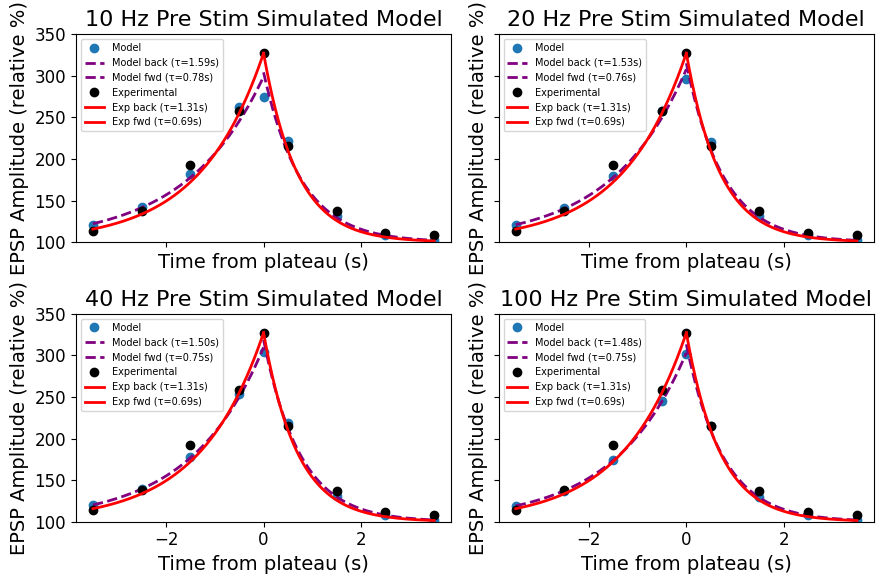

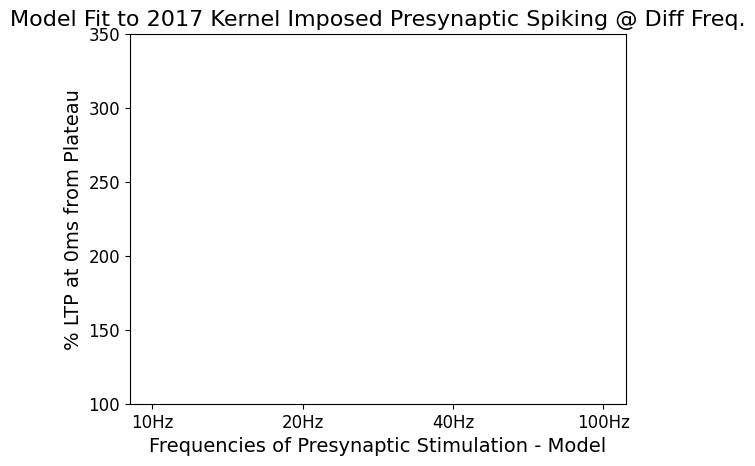

y_mod [0.21213811 0.41802777 0.82374268 1.6232223  1.75188794 1.21834326
 0.31763101 0.08203837 0.021189  ]
xx [0.         0.00877193 0.01754386 0.02631579 0.03508772 0.04385965
 0.05263158 0.06140351 0.07017544 0.07894737 0.0877193  0.09649123
 0.10526316 0.11403509 0.12280702 0.13157895 0.14035088 0.14912281
 0.15789474 0.16666667 0.1754386  0.18421053 0.19298246 0.20175439
 0.21052632 0.21929825 0.22807018 0.23684211 0.24561404 0.25438596
 0.26315789 0.27192982 0.28070175 0.28947368 0.29824561 0.30701754
 0.31578947 0.3245614  0.33333333 0.34210526 0.35087719 0.35964912
 0.36842105 0.37719298 0.38596491 0.39473684 0.40350877 0.4122807
 0.42105263 0.42982456 0.43859649 0.44736842 0.45614035 0.46491228
 0.47368421 0.48245614 0.49122807 0.5        0.50877193 0.51754386
 0.52631579 0.53508772 0.54385965 0.55263158 0.56140351 0.57017544
 0.57894737 0.5877193  0.59649123 0.60526316 0.61403509 0.62280702
 0.63157895 0.64035088 0.64912281 0.65789474 0.66666667 0.6754386
 0.68421053 0.692982

<Figure size 640x480 with 0 Axes>

model_dict['x_s'] -0.0
model_dict['x_s'] -0.0
model_dict['x_s'] -0.0
model_dict['x_s'] -0.0


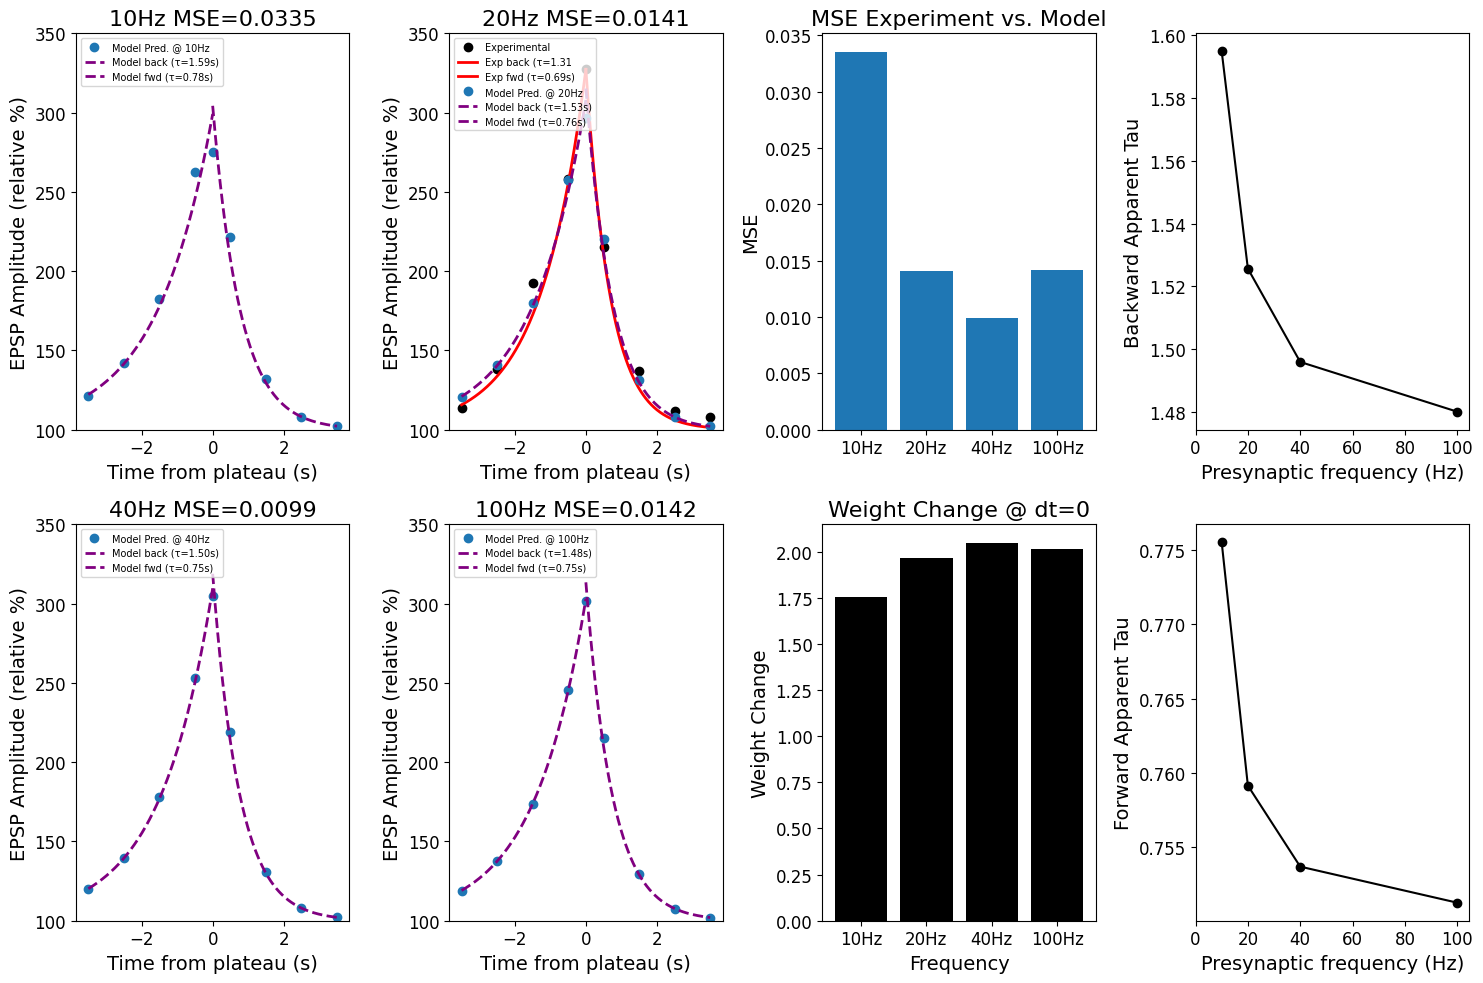

In [13]:
import matplotlib.pyplot as plt
import numpy as np

def plot_summary(backwards_experiment_per_hz_dict, backwards_model_per_hz_dict):
    fig, axs  = plt.subplots(2,4, figsize=(15,10))

    axs_list = [axs[0,0], axs[0,1], axs[1,0], axs[1,1]]

    model_t0_list = []


    apparent_tau_model_list_backwards = []
    apparent_tau_model_list_forwards = []

    mse_list = []

    for i, hz in enumerate(backwards_experiment_per_hz_dict):
        back_dict = backwards_experiment_per_hz_dict[hz]

        model_dict = backwards_model_per_hz_dict[hz]


        model_at_t0 = model_dict['y_mod'][4]
        model_t0_list.append(model_at_t0)

        print(f"model_dict['x_s'] {model_dict['x_s'][4]}")

        ax = axs_list[i]

        
        label_exp = "Experimental"
        if hz==20:
            ax.plot(back_dict["x_exp_s_backward"], back_dict["y_exp_s_backward"], 'o', color='k', label=label_exp if hz ==20 else None)
            label_tau = f'Exp back (τ={back_dict["TAU_BACK_PAPER"]:.2f}'
            ax.plot(back_dict["xx_b"], back_dict["yy_b"], '-', lw=2.0, color='red', label=label_tau if hz ==20 else None)
            ax.plot(back_dict["xx_f"], back_dict["yy_f"], '-', lw=2.0, color='red', label=f'Exp fwd (τ={back_dict["TAU_FWD_PAPER"]:.2f}s)')

        ax.plot(model_dict["x_s"], model_dict["y_mod"], 'o', label=f"Model Pred. @ {hz}Hz", color='tab:blue')
        ax.plot(model_dict["xx_b"], model_dict["model_backwards_line"], '--', lw=2.0, color='purple', label=f"Model back (τ={model_dict['taumb']:.2f}s)")
        ax.plot(model_dict["xx_f"], model_dict["model_forwards_line"], '--', lw=2.0, color='purple', label=f"Model fwd (τ={model_dict['taumf']:.2f}s)")

        apparent_tau_model_list_backwards.append(model_dict['taumb'])
        apparent_tau_model_list_forwards.append(model_dict['taumf'])

        mse = np.mean(np.square(back_dict['y_exp_s_backward']-model_dict['y_mod']))

        mse_list.append(mse)

        ax.set_title(f"{hz}Hz MSE={mse:.4f}")
        ax.set_xlabel("Time from plateau (s)")
        ax.set_ylabel("EPSP Amplitude (relative %)") #("ΔW")
        ax.set_ylim(0, 2.50)
        custom_tick_locations = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5]
        custom_labels = ['100', '150', '200', '250', '300', '350']
        ax.set_yticks(custom_tick_locations)
        ax.set_yticklabels(custom_labels)
        ax.legend(fontsize=7, loc="upper left")

    axs[0,2].bar(range(len(mse_list)), mse_list)
    axs[0,2].set_title("MSE Experiment vs. Model")
    axs[0,2].set_ylabel("MSE")
    axs[0,2].set_xticks(range(4), ["10Hz", "20Hz", "40Hz", "100Hz"])

    axs[1,2].bar(range(len(model_t0_list)),model_t0_list, color='k')
    axs[1,2].set_xticks(range(4), ["10Hz", "20Hz", "40Hz", "100Hz"])
    axs[1,2].set_ylabel("Weight Change")
    axs[1,2].set_title("Weight Change @ dt=0")
    axs[1,2].set_xlabel("Frequency")



    # long_range = np.arange(101)
    # hzs=[10, 20, 40, 100]
    # for i, hz in enumerate(hzs):
    #     axs[0,3].plot(long_range[hz], apparent_tau_model_list_backwards[i], marker='o', color='k')
    #     axs[0,3].set_ylabel("Backward Apparent Tau")


    #     axs[1,3].plot(long_range[hz], apparent_tau_model_list_forwards[i], marker='o', color='k')
    #     axs[1,3].set_ylabel("Forward Apparent Tau")

    hzs = np.array([10, 20, 40, 100])

    axs[0,3].plot(hzs, apparent_tau_model_list_backwards, '-o', color='k')
    axs[0,3].set_ylabel("Backward Apparent Tau")

    axs[1,3].plot(hzs, apparent_tau_model_list_forwards, '-o', color='k')
    axs[1,3].set_ylabel("Forward Apparent Tau")

    axs[0,3].set_xlim(left=0)
    axs[1,3].set_xlim(left=0)

    axs[0,3].set_xticks([0, 20, 40, 60, 80, 100])
    axs[1,3].set_xticks([0, 20, 40, 60, 80, 100])
    axs[0,3].set_xlabel("Presynaptic frequency (Hz)")
    axs[1,3].set_xlabel("Presynaptic frequency (Hz)")


    plt.tight_layout()
    plt.show()




params_cl = {"tau_et": 1474.7515259682878,
  "tau_is": 739.2145185588507,
  "lam_et": 161.24381107148224,
  "lam_is": 39.57778784397287,
  "eta_ms": 0.002976991280586468}

save_path = "/Users/michaelfinch/CA1-interneuron-GLM/ching_lung/pickle_of_all_experimental_data.pkl"
with open(save_path, 'rb') as f:
    cleaned_data_dict = pickle.load(f)

plot_full_intermediates=False

backwards_experiment_per_hz_dict, backwards_model_per_hz_dict = plot_jeff2(params_cl, cleaned_data_dict, plot_full_intermediates, handin_hz="20Hz_full_kernel")

plot_summary(backwards_experiment_per_hz_dict, backwards_model_per_hz_dict)

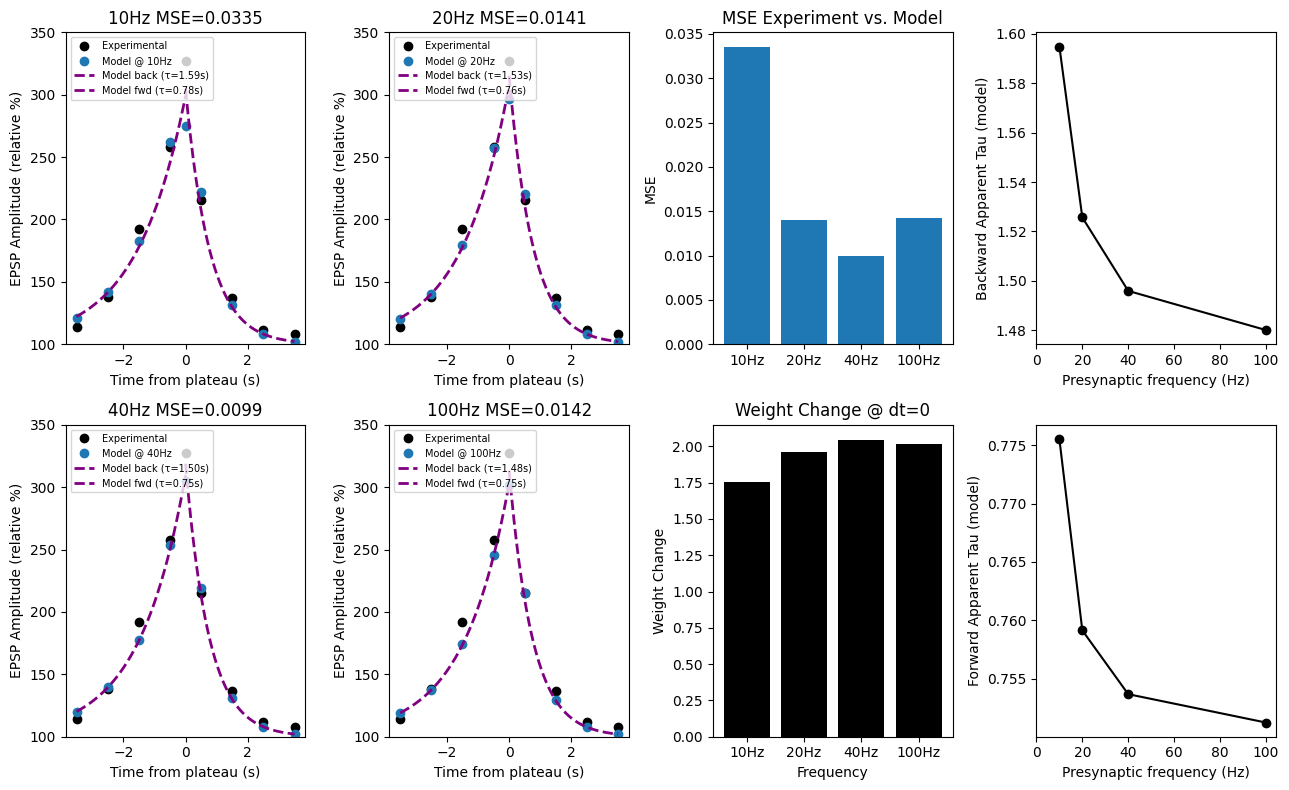

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def plot_summary2(backwards_experiment_per_hz_dict, backwards_model_per_hz_dict, c_fixed=0.0):
    """
    Summary plot that:
      - shows experimental data for ALL Hz panels (10/20/40/100)
      - overlays model points + model exponential fits (purple dashed, from backwards_model_per_hz_dict)
      - fits exponentials to experimental data USING YOUR fit_exp_fixed_c and plots those fits in RED

    Assumptions about dicts:
      backwards_model_per_hz_dict[hz] contains:
        - "x_s", "y_mod", "xx_b", "model_backwards_line", "taumb", "xx_f", "model_forwards_line", "taumf"
      backwards_experiment_per_hz_dict[hz] contains:
        - "x_exp_s_backward", "y_exp_s_backward"
        (and may also contain xx_b/yy_b/xx_f/yy_f from older code; we ignore and refit here)
    """

    # ---------- helpers ----------
    def split_back_fwd(x_s, y):
        x_s = np.asarray(x_s, float)
        y   = np.asarray(y, float)
        m = np.isfinite(x_s) & np.isfinite(y)
        x_s, y = x_s[m], y[m]
        o = np.argsort(x_s)
        x_s, y = x_s[o], y[o]
        mb = x_s <= 0
        mf = x_s >= 0
        return x_s[mb], y[mb], x_s[mf], y[mf]

    def exp_with_fixed_c(x, A, tau, c_fixed=0.0):
        x = np.asarray(x, float)
        return float(c_fixed) + A * np.exp(x / tau)

    def _fit_exp_arm_back(xb, yb, c_fixed=0.0):
        """
        Fit backward arm y ≈ c + A exp(x/tau) on xb<=0.
        Returns (A, tau) or (np.nan, np.nan) if not enough points.
        """
        xb = np.asarray(xb, float)
        yb = np.asarray(yb, float)
        # fit_exp_fixed_c will raise if not enough positive points; catch and return nan
        try:
            A, tau = fit_exp_fixed_c(xb, yb, c_fixed=c_fixed)
            return A, tau
        except Exception:
            return np.nan, np.nan

    def _fit_exp_arm_fwd(xf, yf, c_fixed=0.0):
        """
        Fit forward arm by transforming z = -x (so z<=0 if x>=0? actually z<=0).
        But your fitter works with any x ordering; we want an increasing exponential in z,
        so we fit yf ≈ c + A exp(z/tau) with z = -xf.
        Returns (A, tau) or (np.nan, np.nan).
        """
        xf = np.asarray(xf, float)
        yf = np.asarray(yf, float)
        zf = -xf
        try:
            A, tau = fit_exp_fixed_c(zf, yf, c_fixed=c_fixed)
            return A, tau
        except Exception:
            return np.nan, np.nan

    # ---------- layout ----------
    fig, axs = plt.subplots(2, 4, figsize=(13, 8))
    axs_list = [axs[0,0], axs[0,1], axs[1,0], axs[1,1]]

    hzs_order = [10, 20, 40, 100]

    model_t0_list = []
    apparent_tau_model_list_backwards = []
    apparent_tau_model_list_forwards  = []
    mse_list = []

    for i, hz in enumerate(hzs_order):
        ax = axs_list[i]

        if hz not in backwards_experiment_per_hz_dict:
            ax.set_title(f"{hz}Hz (no experimental)")
            continue
        if hz not in backwards_model_per_hz_dict:
            ax.set_title(f"{hz}Hz (no model)")
            continue

        exp_dict   = backwards_experiment_per_hz_dict[hz]
        model_dict = backwards_model_per_hz_dict[hz]

        # ----- pull EXP -----
        x_exp = np.asarray(exp_dict.get("x_exp_s_backward", []), float)
        y_exp = np.asarray(exp_dict.get("y_exp_s_backward", []), float)

        # ----- pull MODEL -----
        x_mod = np.asarray(model_dict.get("x_s", []), float)
        y_mod = np.asarray(model_dict.get("y_mod", []), float)

        # ----- plot EXP points -----
        ax.plot(x_exp, y_exp, 'o', color='k', label="Experimental")

        # ----- fit EXP exponentials using your fit_exp_fixed_c -----
        xb_e, yb_e, xf_e, yf_e = split_back_fwd(x_exp, y_exp)

        # for 10/40/100: you said experimental only has backward arm, but this works either way
        Aeb, taueb = _fit_exp_arm_back(xb_e, yb_e, c_fixed=c_fixed)
        if np.isfinite(taueb):
            xx_b = np.linspace(xb_e.min(), 0.0, 400)
            yy_b = exp_with_fixed_c(xx_b, Aeb, taueb, c_fixed=c_fixed)
            ax.plot(xx_b, yy_b, '-', lw=2.0, color='red',
                    label=f"Exp back fit (τ={taueb:.2f}s)")

        # for 20 Hz full kernel: also fit forward if points exist
        Aef, tauef = _fit_exp_arm_fwd(xf_e, yf_e, c_fixed=c_fixed)
        if hz == 20 and np.isfinite(tauef):
            xx_f = np.linspace(0.0, xf_e.max(), 400)
            yy_f = exp_with_fixed_c(-xx_f, Aef, tauef, c_fixed=c_fixed)  # note -xx_f (z=-x)
            ax.plot(xx_f, yy_f, '-', lw=2.0, color='red',
                    label=f"Exp fwd fit (τ={tauef:.2f}s)")

        # ----- plot MODEL points + model fits (already computed) -----
        ax.plot(x_mod, y_mod, 'o', color='tab:blue', label=f"Model @ {hz}Hz")
        ax.plot(model_dict.get("xx_b", np.array([])),
                model_dict.get("model_backwards_line", np.array([])),
                '--', lw=2.0, color='purple',
                label=f"Model back (τ={model_dict.get('taumb', np.nan):.2f}s)")
        ax.plot(model_dict.get("xx_f", np.array([])),
                model_dict.get("model_forwards_line", np.array([])),
                '--', lw=2.0, color='purple',
                label=f"Model fwd (τ={model_dict.get('taumf', np.nan):.2f}s)")

        # ----- collect taus -----
        apparent_tau_model_list_backwards.append(model_dict.get("taumb", np.nan))
        apparent_tau_model_list_forwards.append(model_dict.get("taumf", np.nan))

        # ----- model@t0 -----
        model_at_t0 = y_mod[4] if len(y_mod) > 4 else np.nan
        model_t0_list.append(model_at_t0)

        # ----- MSE (align or interpolate) -----
        mse = np.nan
        if x_exp.size and x_mod.size:
            m = np.isfinite(x_mod) & np.isfinite(y_mod)
            if m.sum() >= 2:
                y_mod_interp = np.interp(x_exp, x_mod[m], y_mod[m])
                mse = np.nanmean((y_exp - y_mod_interp) ** 2)
        mse_list.append(mse)

        ax.set_title(f"{hz}Hz MSE={mse:.4f}" if np.isfinite(mse) else f"{hz}Hz MSE=nan")
        ax.set_xlabel("Time from plateau (s)")
        ax.set_ylabel("EPSP Amplitude (relative %)")
        ax.set_ylim(0, 2.50)
        ax.set_yticks([0.0, 0.5, 1.0, 1.5, 2.0, 2.5])
        ax.set_yticklabels(['100', '150', '200', '250', '300', '350'])
        ax.legend(fontsize=7, loc="upper left")

    # ---------- summary panels ----------
    axs[0,2].bar(range(len(mse_list)), mse_list)
    axs[0,2].set_title("MSE Experiment vs. Model")
    axs[0,2].set_ylabel("MSE")
    axs[0,2].set_xticks(range(4), ["10Hz", "20Hz", "40Hz", "100Hz"])

    axs[1,2].bar(range(len(model_t0_list)), model_t0_list, color='k')
    axs[1,2].set_xticks(range(4), ["10Hz", "20Hz", "40Hz", "100Hz"])
    axs[1,2].set_ylabel("Weight Change")
    axs[1,2].set_title("Weight Change @ dt=0")
    axs[1,2].set_xlabel("Frequency")

    hzs = np.array([10, 20, 40, 100], float)

    axs[0,3].plot(hzs, apparent_tau_model_list_backwards, '-o', color='k')
    axs[0,3].set_ylabel("Backward Apparent Tau (model)")
    axs[0,3].set_xlabel("Presynaptic frequency (Hz)")
    axs[0,3].set_xlim(left=0)
    axs[0,3].set_xticks([0, 20, 40, 60, 80, 100])

    axs[1,3].plot(hzs, apparent_tau_model_list_forwards, '-o', color='k')
    axs[1,3].set_ylabel("Forward Apparent Tau (model)")
    axs[1,3].set_xlabel("Presynaptic frequency (Hz)")
    axs[1,3].set_xlim(left=0)
    axs[1,3].set_xticks([0, 20, 40, 60, 80, 100])

    plt.tight_layout()
    plt.show()

plot_summary2(backwards_experiment_per_hz_dict, backwards_model_per_hz_dict, c_fixed=0.0)

In [30]:
backwards_model_per_hz_dict

{10: {'xx_f': array([0.        , 0.00877193, 0.01754386, 0.02631579, 0.03508772,
         0.04385965, 0.05263158, 0.06140351, 0.07017544, 0.07894737,
         0.0877193 , 0.09649123, 0.10526316, 0.11403509, 0.12280702,
         0.13157895, 0.14035088, 0.14912281, 0.15789474, 0.16666667,
         0.1754386 , 0.18421053, 0.19298246, 0.20175439, 0.21052632,
         0.21929825, 0.22807018, 0.23684211, 0.24561404, 0.25438596,
         0.26315789, 0.27192982, 0.28070175, 0.28947368, 0.29824561,
         0.30701754, 0.31578947, 0.3245614 , 0.33333333, 0.34210526,
         0.35087719, 0.35964912, 0.36842105, 0.37719298, 0.38596491,
         0.39473684, 0.40350877, 0.4122807 , 0.42105263, 0.42982456,
         0.43859649, 0.44736842, 0.45614035, 0.46491228, 0.47368421,
         0.48245614, 0.49122807, 0.5       , 0.50877193, 0.51754386,
         0.52631579, 0.53508772, 0.54385965, 0.55263158, 0.56140351,
         0.57017544, 0.57894737, 0.5877193 , 0.59649123, 0.60526316,
         0.61403509, 0

In [39]:
x = cleaned_data_dict["20Hz_full_kernel"]['x'][4:]
y = cleaned_data_dict["20Hz_full_kernel"]['y'][4:]

print(list(x), list(y))

[0, -500, -1500, -2500, -3500] [2.2730769230769226, 1.1538461538461544, 0.36923076923076903, 0.11538461538461604, 0.08076923076923165]


In [ ]:
delta_w_list, et_time_1000, IS = get_W(
            x_20,
            post_ms=10000, pre_ms=10000,
            hz_used=hz_used,               # <-- only this changes
            plateau_length=300,
            tau_et=params["tau_et"], tau_is=params["tau_is"],
            lam_et=params["lam_et"], lam_is=params["lam_is"],
            dt_ms=1.0, eta_ms=params["eta_ms"],
            plot_intermediates=False
        )

dict_keys([10, 20, 40, 100])

In [64]:
save_path = "/Users/michaelfinch/CA1-interneuron-GLM/ching_lung/jeffs_data_csv.pkl"
with open(save_path, 'rb') as f:
    jeffs_data_dict = pickle.load(f)

jeffs_data_dict[20]['x'] 

array([ 3200,  1300,   800,   300,     0,  -200,  -600, -1700])

In [67]:
print(data_for_hz['x'])


[4000 3000 2000 1000  400  200]


len(curve_data) 6
len(curve_data) 6
len(curve_data) 5
len(curve_data) 4
len(curve_data) 9


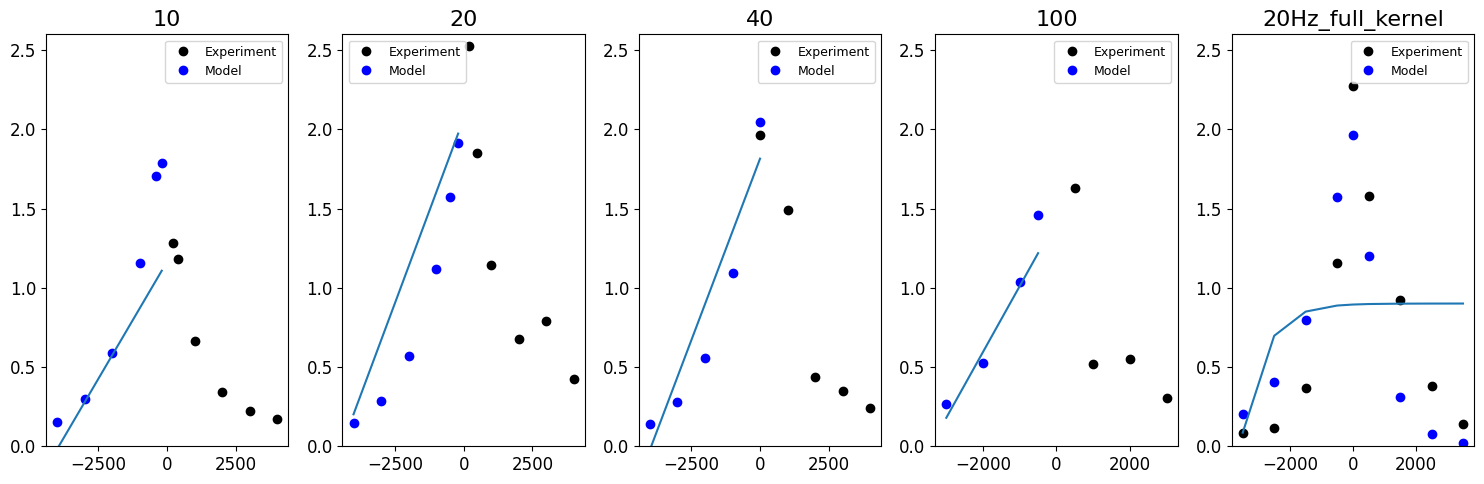

In [96]:
import scipy

save_path = "/Users/michaelfinch/CA1-interneuron-GLM/ching_lung/pickle_of_all_experimental_data.pkl"
with open(save_path, 'rb') as f:
    cleaned_data_dict = pickle.load(f)

def exp_with_fixed_c(x, A, tau, c_fixed):
    return float(c_fixed) + A*np.exp(x/float(tau))

fig, axs = plt.subplots(1,5, figsize=(15, 5))

for i, key in enumerate(cleaned_data_dict):
    data_for_hz = cleaned_data_dict[key] 
    if key == "20Hz_full_kernel":
        bw_model = backwards_model_per_hz_dict[20]
        hz = 20
    else:
        hz = key
        bw_model = backwards_model_per_hz_dict[key] 
    axs[i].plot(data_for_hz['x'], data_for_hz['y'], 'o', color='k', label='Experiment')
    axs[i].set_title(key)

    experimental_data = data_for_hz['y']
    model_data = bw_model['y_mod']

    

    

    params = params_cl



    delta_w_list, et_time_1000, IS = get_W(data_for_hz['x'],
            post_ms=10000, pre_ms=10000,
            hz_used=hz,               # <-- only this changes
            plateau_length=300,
            tau_et=params["tau_et"], tau_is=params["tau_is"],
            lam_et=params["lam_et"], lam_is=params["lam_is"],
            dt_ms=1.0, eta_ms=params["eta_ms"],
            plot_intermediates=False
        )
    
    bw_model_at_correct_x = delta_w_list

    x_back = data_for_hz['x'] * -1


    axs[i].plot(x_back, bw_model_at_correct_x, 'o', color='b', label='Model')
    axs[i].set_ylim(0, 2.6)
    

    [A_alt, tau_alt, c_alt], _ = scipy.optimize.curve_fit(exp_with_fixed_c, x_back, data_for_hz['y'], p0=[1., -1000., 0.])

    

    curve_data = exp_with_fixed_c(x_back, A_alt, tau_alt, c_alt)

    print(f'len(curve_data) {len(curve_data)}')


    axs[i].plot(x_back, curve_data)
    axs[i].legend()

    

plt.tight_layout()
plt.show()


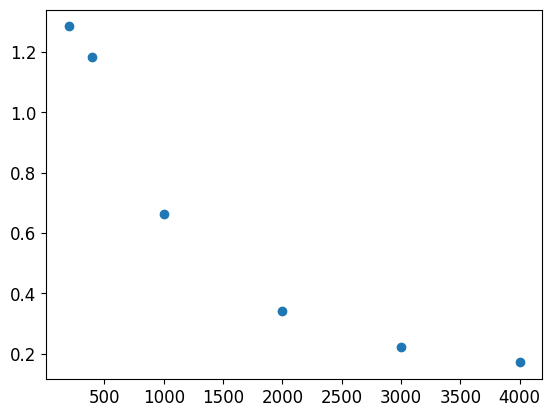

In [91]:
plt.plot(cleaned_data_dict[10]['x'], cleaned_data_dict[10]['y'], 'o')

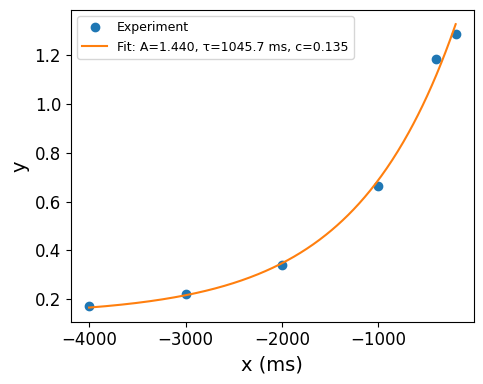

In [103]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def exp_with_fixed_c(x, A, tau, c_fixed):
    x = np.asarray(x, float)
    return float(c_fixed) + A*np.exp(x/float(tau))

x = np.asarray(cleaned_data_dict[10]['x']*-1, float)
y = np.asarray(cleaned_data_dict[10]['y'], float)

# Fit A, tau, c_fixed (3 params)
p0 = [y.max() - y.min(), 1000.0, y.min()]  # [A, tau(ms), c]
bounds = ([-np.inf, 1e-6, -np.inf], [np.inf, np.inf, np.inf])  # tau > 0

popt, pcov = curve_fit(exp_with_fixed_c, x, y, p0=p0, bounds=bounds, maxfev=20000)
A_fit, tau_fit, c_fit = popt

# smooth curve for plotting
xx = np.linspace(x.min(), x.max(), 400)
yy = exp_with_fixed_c(xx, A_fit, tau_fit, c_fit)

plt.figure(figsize=(5,4))
plt.plot(x, y, 'o', label='Experiment')
plt.plot(xx, yy, '-', label=f'Fit: A={A_fit:.3f}, τ={tau_fit:.1f} ms, c={c_fit:.3f}')
plt.xlabel('x (ms)')
plt.ylabel('y')
plt.legend()
plt.tight_layout()
plt.show()

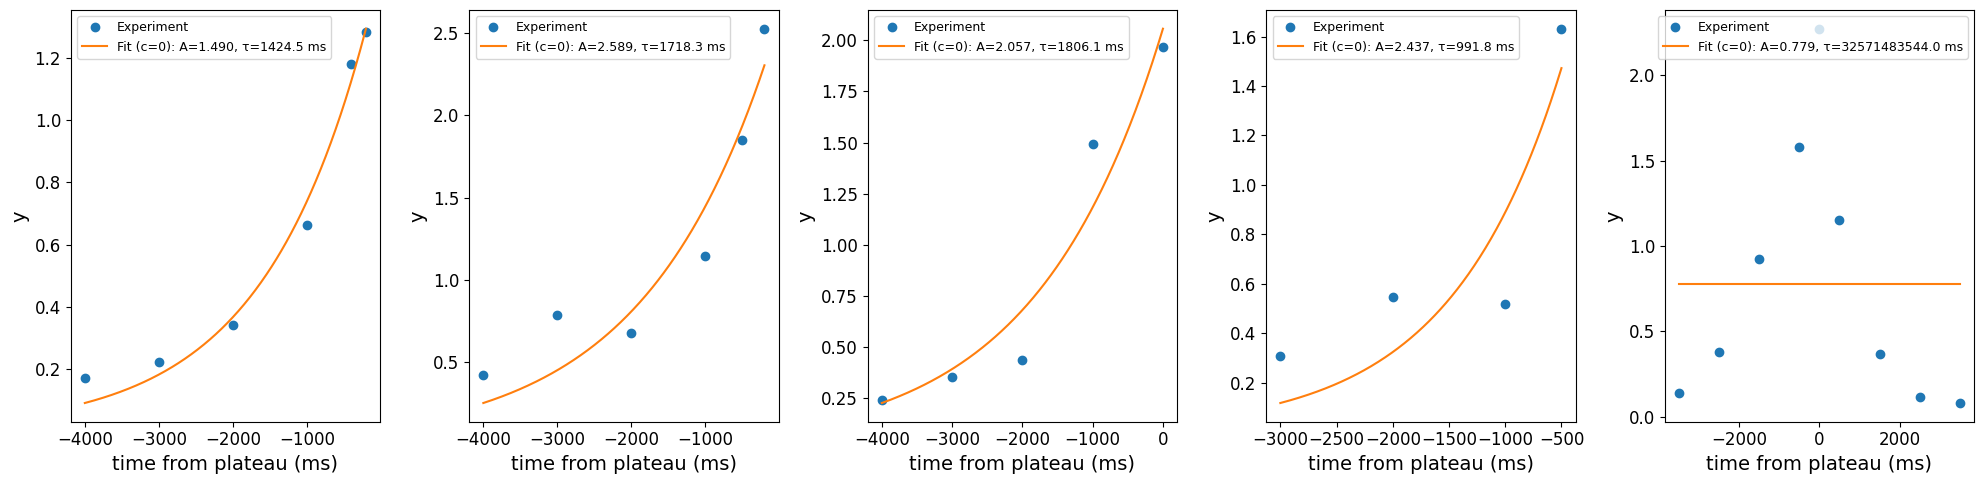

In [108]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def exp_with_fixed_c(x, A, tau, c_fixed):
    x = np.asarray(x, float)
    return float(c_fixed) + A*np.exp(x/float(tau))

def exp_c0(x, A, tau):
    return exp_with_fixed_c(x, A, tau, c_fixed=0.0)

fig, axs = plt.subplots(1,5, figsize=(20, 5))

for i, key in enumerate(cleaned_data_dict):

    x = np.asarray(cleaned_data_dict[key]['x'] * -1, float)  
    y = np.asarray(cleaned_data_dict[key]['y'], float)

    p0 = [y.max(), 1000.0]                       
    bounds = ([-np.inf, 1e-6], [np.inf, np.inf]) 

    [A_fit, tau_fit], pcov = curve_fit(exp_c0, x, y, p0=p0, bounds=bounds, maxfev=20000)

    xx = np.linspace(x.min(), x.max(), 400)
    yy = exp_c0(xx, A_fit, tau_fit)

    axs[i].plot(x, y, 'o', label='Experiment')
    axs[i].plot(xx, yy, '-', label=f'Fit (c=0): A={A_fit:.3f}, τ={tau_fit:.1f} ms')
    axs[i].set_xlabel('time from plateau (ms)')
    axs[i].set_ylabel('y')
    axs[i].legend()
plt.tight_layout()
plt.show()

In [115]:
jeffs_data_dict[20]

{'x': array([ 3200,  1300,   800,   300,     0,  -200,  -600, -1700]),
 'y': array([0.22379526, 0.70373753, 1.12235791, 1.63483495, 2.07879113,
        1.25141626, 0.58630559, 0.3314659 ])}

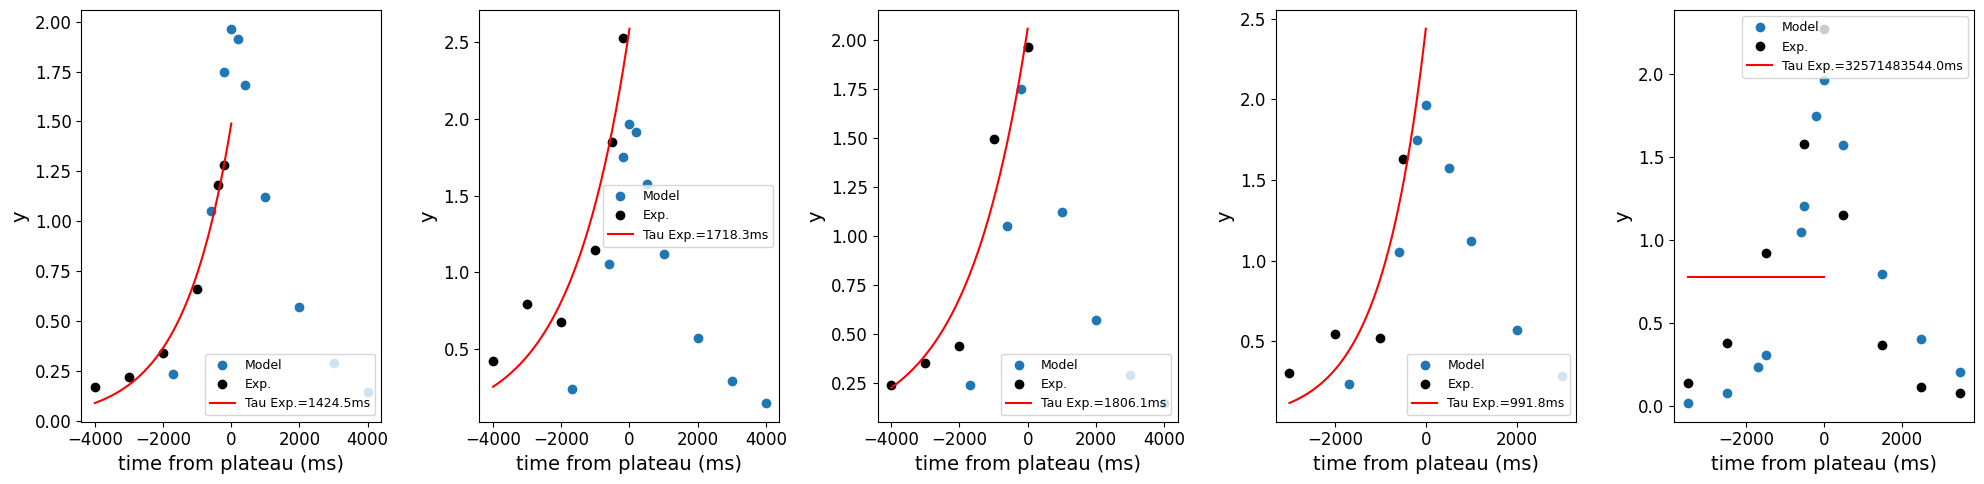

In [122]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def exp_with_fixed_c(x, A, tau, c_fixed):
    x = np.asarray(x, float)
    return float(c_fixed) + A*np.exp(x/float(tau))

def exp_c0(x, A, tau):
    return exp_with_fixed_c(x, A, tau, c_fixed=0.0)

fig, axs = plt.subplots(1,5, figsize=(20, 5))



for i, key in enumerate(cleaned_data_dict):

    x = np.asarray(cleaned_data_dict[key]['x'] * -1, float)  
    y = np.asarray(cleaned_data_dict[key]['y'], float)

    p0 = [y.max(), 1000.0]                       
    bounds = ([-np.inf, 1e-6], [np.inf, np.inf]) 

    [A_fit, tau_fit], pcov = curve_fit(exp_c0, x, y, p0=p0, bounds=bounds, maxfev=20000)

    xx = np.linspace(x.min(), 0, 400)
    yy = exp_c0(xx, A_fit, tau_fit)

    model_x = list(cleaned_data_dict[key]['x'])

    if 0 not in cleaned_data_dict[key]['x']:
        model_x.append(0)
        model_x.append(-200)
        model_x.append(-600)
        model_x.append(-1700)
    else:
        model_x.append(-200)
        model_x.append(-600)
        model_x.append(-1700)

    # else:
    #     model_x = np.hstack([cleaned_data_dict[key]['x'], [-200,-600,-1700]])

    delta_w_list, et_time_1000, IS = get_W(model_x,
            post_ms=10000, pre_ms=10000,
            hz_used=hz,               # <-- only this changes
            plateau_length=300,
            tau_et=params["tau_et"], tau_is=params["tau_is"],
            lam_et=params["lam_et"], lam_is=params["lam_is"],
            dt_ms=1.0, eta_ms=params["eta_ms"],
            plot_intermediates=False
        )
    
    axs[i].plot(model_x, delta_w_list, 'o', label='Model')


    axs[i].plot(x, y, 'o', label='Exp.', color='k')
    axs[i].plot(xx, yy, '-', label=f'Tau Exp.={tau_fit:.1f}ms', color='r')
    axs[i].set_xlabel('time from plateau (ms)')
    axs[i].set_ylabel('y')
    axs[i].legend()
plt.tight_layout()
plt.show()

model_x [4000, 3000, 2000, 1000, 400, 200, 0]
delta_w_list [0.151121231796947, 0.2977912399028347, 0.5868111416800879, 1.156337963844214, 1.7065506577542506, 1.7877282424200338, 1.7518879432213348]
cleaned_data_dict[20Hz_full_kernel].keys() [ 3500  2500  1500   500     0  -500 -1500 -2500 -3500]
model_x [4000, 3000, 2000, 1000, 500, 200, 0]
delta_w_list [0.1464901955238874, 0.2886655729307553, 0.5688286011049339, 1.1209025522160643, 1.5734794473974727, 1.9150079538127551, 1.9646926252611867]
cleaned_data_dict[20Hz_full_kernel].keys() [ 3500  2500  1500   500     0  -500 -1500 -2500 -3500]
model_x [4000, 3000, 2000, 1000, 0, 0]
delta_w_list [0.14270669193503976, 0.28121000754459047, 0.5541370714361831, 1.091952226811059, 2.0460861710413387, 2.0460861710413387]
cleaned_data_dict[20Hz_full_kernel].keys() [ 3500  2500  1500   500     0  -500 -1500 -2500 -3500]
model_x [3000, 2000, 1000, 500, 0]
delta_w_list [0.2672617387846907, 0.5266513753555053, 1.0377904163352472, 1.4568098605727942, 2.

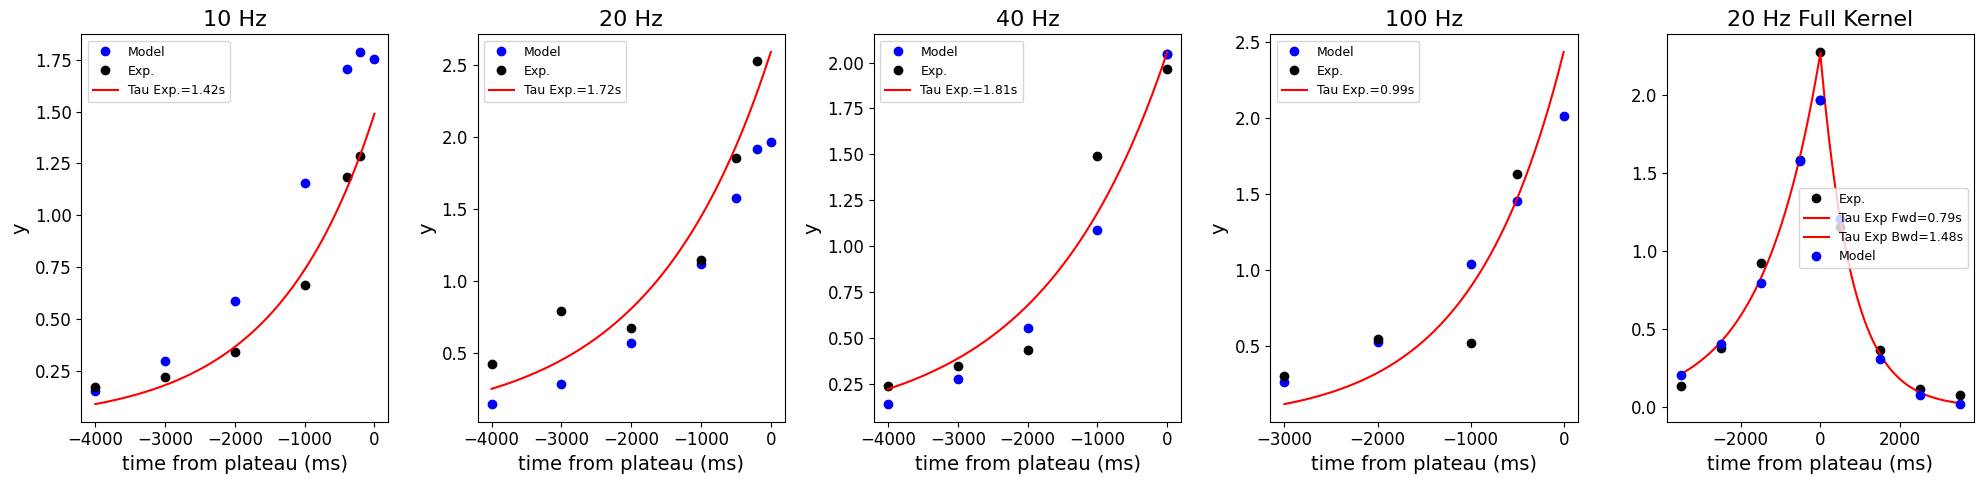

dict_keys([10, 20, 40, 100, '20Hz_full_kernel'])

In [206]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def exp_with_fixed_c(x, A, tau, c_fixed):
    x = np.asarray(x, float)
    return float(c_fixed) + A*np.exp(x/float(tau))

def exp_c0(x, A, tau):
    return exp_with_fixed_c(x, A, tau, c_fixed=0.0)

fig, axs = plt.subplots(1,5, figsize=(20, 5))


def exp_back_c0(x, A, tau):   # for x <= 0
    return A*np.exp(x/tau)

def exp_fwd_c0(x, A, tau):    # for x >= 0
    return A*np.exp(-x/tau)

dw_0_dict_experiment = {}
dw_0_dict_model = {}

for i, key in enumerate(cleaned_data_dict):

    

    if key == '20Hz_full_kernel':

        # fwd_x = cleaned_data_dict['20Hz_full_kernel']['x'][4:]
        # fwd_y = cleaned_data_dict['20Hz_full_kernel']['y'][4:]
        # [A_fit, tau_fit], pcov = curve_fit(exp_c0, fwd_x, fwd_y, p0=p0)
        # xx = np.linspace(fwd_x.min(), 0, 400)
        # yy = exp_c0(xx, A_fit, tau_fit)
        # axs[i].plot(fwd_x, fwd_y, 'o', color='k', label='Exp.')
        # axs[i].plot(xx, yy, '-', label=f'Tau Exp.={tau_fit:.1f}ms', color='r')

        # model_x = list(cleaned_data_dict["20Hz_full_kernel"]['x'])

        # print(f"model_x {model_x}")

        # delta_w_list, et_time_1000, IS = get_W(model_x,
        #         post_ms=10000, pre_ms=10000,
        #         hz_used=hz,               # <-- only this changes
        #         plateau_length=300,
        #         tau_et=params["tau_et"], tau_is=params["tau_is"],
        #         lam_et=params["lam_et"], lam_is=params["lam_is"],
        #         dt_ms=1.0, eta_ms=params["eta_ms"],
        #         plot_intermediates=False
        #     )
        
        # axs[i].plot(model_x, delta_w_list, 'o', label='Model', color='b')
        # axs[i].legend()



        # fwd_x = cleaned_data_dict['20Hz_full_kernel']['x'][:4] *-1
        # fwd_y = cleaned_data_dict['20Hz_full_kernel']['y'][:4]
        # [A_fit, tau_fit], pcov = curve_fit(exp_c0, fwd_x, fwd_y, p0=p0)
        # xx = np.linspace(fwd_x.min(), 0, 400)
        # yy = exp_c0(xx, A_fit, tau_fit)
        # axs[i].plot(fwd_x, fwd_y, 'o', color='k', label='Exp.')
        # axs[i].plot(xx, yy, '-', label=f'Tau Exp.={tau_fit:.1f}ms', color='r')

        # model_x = list(cleaned_data_dict["20Hz_full_kernel"]['x'][:4])


        # delta_w_list, et_time_1000, IS = get_W(model_x,
        #         post_ms=10000, pre_ms=10000,
        #         hz_used=hz,               # <-- only this changes
        #         plateau_length=300,
        #         tau_et=params["tau_et"], tau_is=params["tau_is"],
        #         lam_et=params["lam_et"], lam_is=params["lam_is"],
        #         dt_ms=1.0, eta_ms=params["eta_ms"],
        #         plot_intermediates=False
        #     )
        
        # axs[i].plot(cleaned_data_dict['20Hz_full_kernel']['x'][:4]*-1, delta_w_list, 'o', label='Model', color='b')
        # axs[i].legend()

        xk = np.asarray(cleaned_data_dict['20Hz_full_kernel']['x'], float)
        yk = np.asarray(cleaned_data_dict['20Hz_full_kernel']['y'], float)

        xb, yb = xk[xk <= 0], yk[xk <= 0]   # backward arm
        xf, yf = xk[xk >= 0], yk[xk >= 0]   # forward arm

        # fit backward (x <= 0)
        p0b = [yb.max(), 1000.0]
        (A_b, tau_b), _ = curve_fit(exp_back_c0, xb, yb, p0=p0b,
                                    bounds=([-np.inf, 1e-6], [np.inf, np.inf]),
                                    maxfev=20000)
        xx_b = np.linspace(xb.min(), 0.0, 400)
        yy_b = exp_back_c0(xx_b, A_b, tau_b)

        # fit forward (x >= 0)
        p0f = [yf.max(), 1000.0]
        (A_f, tau_f), _ = curve_fit(exp_fwd_c0, xf, yf, p0=p0f,
                                    bounds=([-np.inf, 1e-6], [np.inf, np.inf]),
                                    maxfev=20000)
        xx_f = np.linspace(0.0, xf.max(), 400)
        yy_f = exp_fwd_c0(xx_f, A_f, tau_f)

        axs[i].plot(xk*-1, yk, 'o', color='k', label='Exp.')
        axs[i].plot(xx_b*-1, yy_b, '-', color='r', label=f'Tau Exp Fwd={tau_b/1000:.2f}s')
        axs[i].plot(xx_f*-1, yy_f, '-', color='r', label=f'Tau Exp Bwd={tau_f/1000:.2f}s')

        model_x = xk.tolist()
        model_x.append(0)
        model_x_int = [int(val) for val in model_x]
        delta_w_list, et_time_1000, IS = get_W(np.array(model_x_int),
                post_ms=10000, pre_ms=10000,
                hz_used=20,               # <-- only this changes
                plateau_length=300,
                tau_et=params["tau_et"], tau_is=params["tau_is"],
                lam_et=params["lam_et"], lam_is=params["lam_is"],
                dt_ms=1.0, eta_ms=params["eta_ms"],
                plot_intermediates=False
            )
        axs[i].plot([val*-1 for val in model_x_int], delta_w_list, 'o', color='b', label='Model')
        axs[i].set_title(f"20 Hz Full Kernel")
        axs[i].set_xlabel('time from plateau (ms)')
        axs[i].legend()

        
        
        dw_0_dict_experiment[key] = yy_b[-1]
        dw_0_dict_model[key] = delta_w_list[-1]

        
        
    else:

        x = np.asarray(cleaned_data_dict[key]['x'] * -1, float)  
        y = np.asarray(cleaned_data_dict[key]['y'], float)

        p0 = [y.max(), 1000.0]                       
        bounds = ([-np.inf, 1e-6], [np.inf, np.inf]) 

        [A_fit, tau_fit], pcov = curve_fit(exp_c0, x, y, p0=p0, bounds=bounds, maxfev=20000)

        xx = np.linspace(x.min(), 0, 400)
        yy = exp_c0(xx, A_fit, tau_fit)

        model_x = list(cleaned_data_dict[key]['x'])

        model_x.append(0)

        print(f"model_x {model_x}")

        delta_w_list, et_time_1000, IS = get_W(model_x,
                post_ms=10000, pre_ms=10000,
                hz_used=key,               # <-- only this changes
                plateau_length=300,
                tau_et=params["tau_et"], tau_is=params["tau_is"],
                lam_et=params["lam_et"], lam_is=params["lam_is"],
                dt_ms=1.0, eta_ms=params["eta_ms"],
                plot_intermediates=False
            )
        
        print(f"delta_w_list {delta_w_list}")
                
        # axs[i].plot(cleaned_data_dict[key]['x'] * -1, delta_w_list, 'o', label='Model', color='b')

        x_list = list(x)
        x_list.append(0.)

        axs[i].plot(x_list, delta_w_list, 'o', label='Model', color='b')

        print(f"cleaned_data_dict[20Hz_full_kernel].keys() {cleaned_data_dict['20Hz_full_kernel']['x']}")

        if 0 not in cleaned_data_dict[key]['x']:
            model_x.append(0)
            model_x.append(-200)
            model_x.append(-600)
            model_x.append(-1700)
        else:
            model_x.append(-200)
            model_x.append(-600)
            model_x.append(-1700)


    
        axs[i].plot(x, y, 'o', label='Exp.', color='k')
        axs[i].plot(xx, yy, '-', label=f'Tau Exp.={tau_fit/1000:.2f}s', color='r')

        axs[i].set_xlabel('time from plateau (ms)')
        axs[i].set_ylabel('y')
        axs[i].set_title(f"{key} Hz")
        axs[i].legend()

        dw_0_dict_experiment[key] = yy[-1]
        dw_0_dict_model[key] = delta_w_list[-1]


plt.tight_layout()
plt.show()

# print(f"dw_0_dict.keys() {dw_0_dict.keys()}")

dw_0_dict_model.keys()

Text(0, 0.5, 'dW @ t=0')

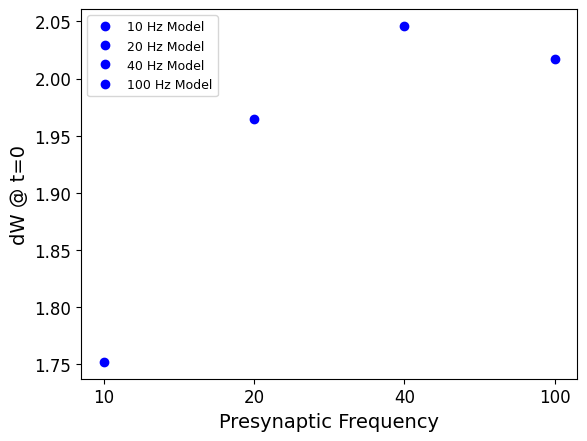

In [203]:
for i, key in enumerate(dw_0_dict_model):

    value = dw_0_dict_model[key]
    if key == "20Hz_full_kernel":
        pass
    else:
        plt.plot(i, value, 'o', label=f"{key} Hz Model", color='b')

    plt.legend()
        


plt.xticks(range(len(dw_0_dict_model)-1), list(dw_0_dict_model.keys())[:-1])
plt.xlabel("Presynaptic Frequency")
plt.ylabel("dW @ t=0")


In [188]:
dw_0_dict_model.keys()

dict_keys([10, 20, 40, 100, '20Hz_full_kernel'])

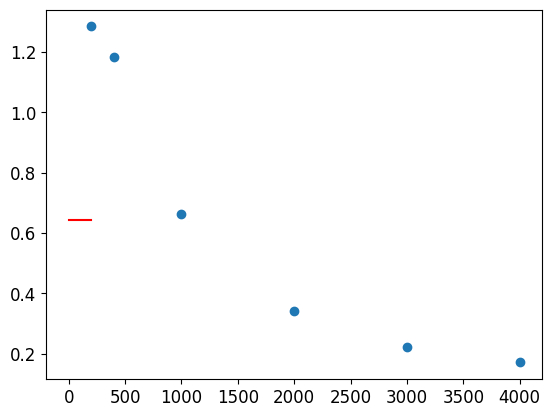

In [142]:
fwd_x = cleaned_data_dict[10]['x']
fwd_y = cleaned_data_dict[10]['y']
[A_fit, tau_fit], pcov = curve_fit(exp_c0, fwd_x, fwd_y, p0=p0)
xx = np.linspace(fwd_x.min(), 0, 400)
yy = exp_c0(xx, A_fit, tau_fit)
plt.plot(fwd_x, fwd_y, 'o')
plt.plot(xx, yy, '-', label=f'Tau Exp.={tau_fit:.1f}ms', color='r')

TypeError: unhashable type: 'dict'

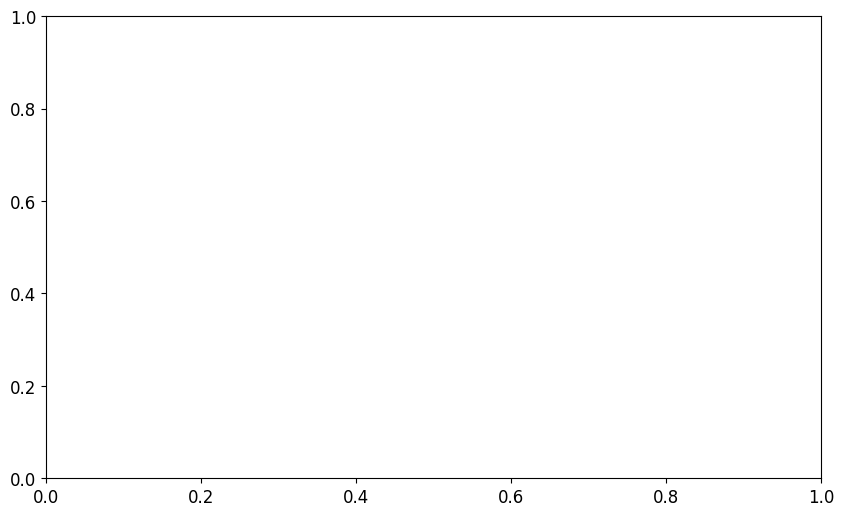

In [94]:
import matplotlib.pyplot as plt

# Extracting the data from your dictionary
data = cleaned_data_dict["20Hz_full_kernel"]

# Plotting the points
plt.figure(figsize=(10, 6))
plt.plot(data, marker='o', linestyle='-', label='20Hz Full Kernel')
plt.title('20Hz Full Kernel Visualization')
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()


delta_w_list (hz=10): [0.21213811301238758, 0.41802777117042283, 0.8237426787118973, 1.6232223013116913, 1.7518879432213348, 1.218343257399941, 0.3176310120761435, 0.08203836674084723, 0.021189001022496885]
delta_w_list (hz=20): [0.20563724424247978, 0.405217514475073, 0.7984994870079842, 1.5734794473974727, 1.9646926252611867, 1.2032764775726235, 0.31078469050082586, 0.08027008541138529, 0.020732286804906557]
delta_w_list (hz=40): [0.20032610892171823, 0.3947516814901565, 0.7778760885342207, 1.5328401055294485, 2.0460861710413387, 1.193242687635765, 0.3081931430284985, 0.07960073570212878, 0.02055940668569471]
delta_w_list (hz=100): [0.1903897541267274, 0.3751716437990229, 0.7392927363999463, 1.4568098605727942, 2.0172421542854204, 1.15079138112964, 0.2972287335507135, 0.07676882653304555, 0.019827977077120102]
y_mod [0.21213811 0.41802777 0.82374268 1.6232223  1.75188794 1.21834326
 0.31763101 0.08203837 0.021189  ]
y_mod [0.20563724 0.40521751 0.79849949 1.57347945 1.96469263 1.2032

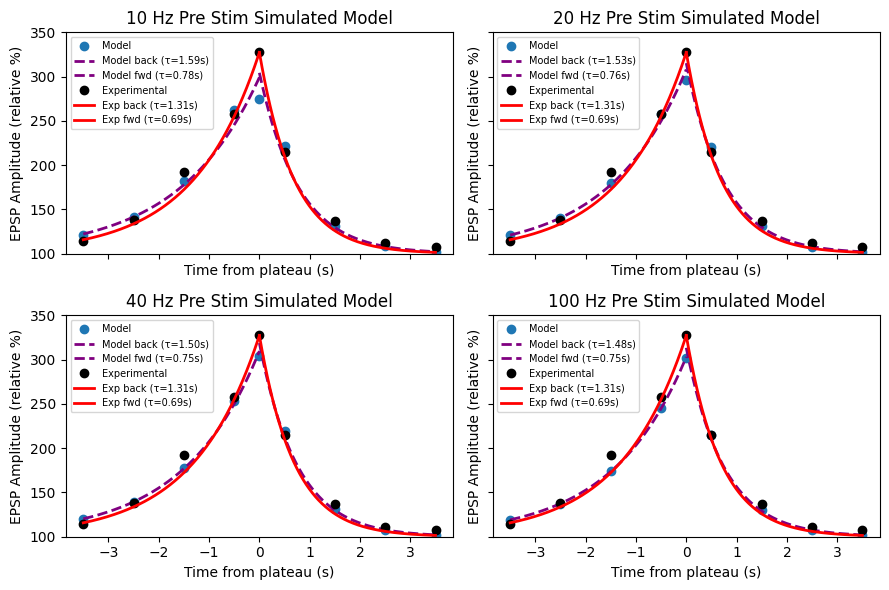

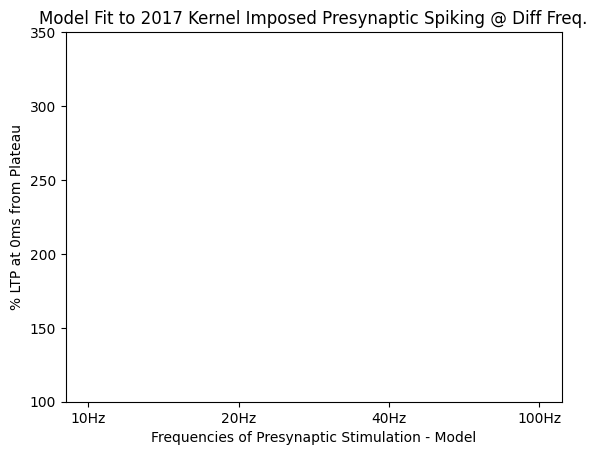

y_mod [0.21213811 0.41802777 0.82374268 1.6232223  1.75188794 1.21834326
 0.31763101 0.08203837 0.021189  ]
xx [0.         0.00877193 0.01754386 0.02631579 0.03508772 0.04385965
 0.05263158 0.06140351 0.07017544 0.07894737 0.0877193  0.09649123
 0.10526316 0.11403509 0.12280702 0.13157895 0.14035088 0.14912281
 0.15789474 0.16666667 0.1754386  0.18421053 0.19298246 0.20175439
 0.21052632 0.21929825 0.22807018 0.23684211 0.24561404 0.25438596
 0.26315789 0.27192982 0.28070175 0.28947368 0.29824561 0.30701754
 0.31578947 0.3245614  0.33333333 0.34210526 0.35087719 0.35964912
 0.36842105 0.37719298 0.38596491 0.39473684 0.40350877 0.4122807
 0.42105263 0.42982456 0.43859649 0.44736842 0.45614035 0.46491228
 0.47368421 0.48245614 0.49122807 0.5        0.50877193 0.51754386
 0.52631579 0.53508772 0.54385965 0.55263158 0.56140351 0.57017544
 0.57894737 0.5877193  0.59649123 0.60526316 0.61403509 0.62280702
 0.63157895 0.64035088 0.64912281 0.65789474 0.66666667 0.6754386
 0.68421053 0.692982

<Figure size 640x480 with 0 Axes>

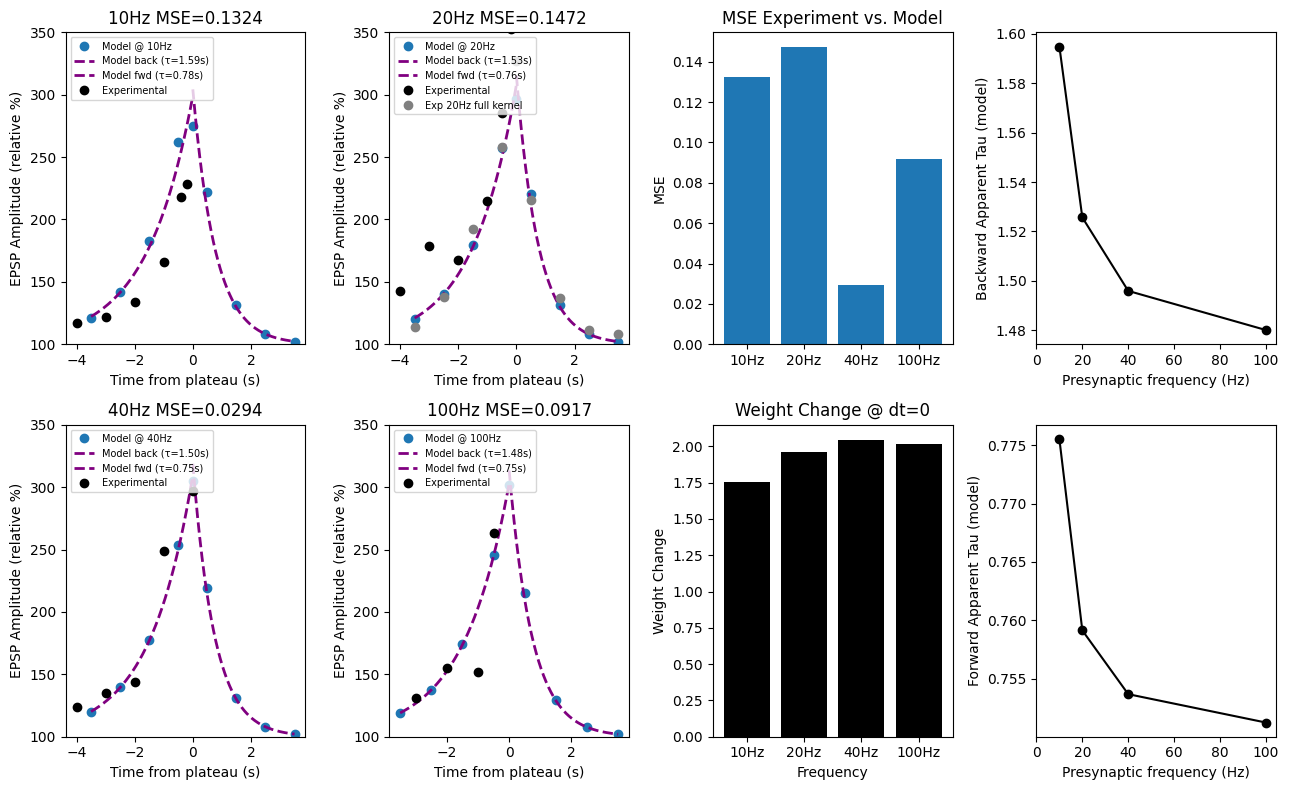

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def exp_with_fixed_c(x, A, tau, c_fixed=0.0):
    x = np.asarray(x, float)
    return float(c_fixed) + A * np.exp(x / tau)

def plot_summary2(cleaned_data_dict, backwards_model_per_hz_dict, c_fixed=0.0):
    """
    Summary plot using REAL experimental data from cleaned_data_dict:
      - 10/20/40/100: backward-arm experimental points from cleaned_data_dict[hz]
      - additionally for 20Hz: overlay FULL kernel from cleaned_data_dict['20Hz_full_kernel']
      - fit exponentials to EXP data using fit_exp_fixed_c and plot fits in RED
      - overlay model points + model fits from backwards_model_per_hz_dict (blue/purple)
    """

    fig, axs = plt.subplots(2, 4, figsize=(13, 8))
    axs_list = [axs[0,0], axs[0,1], axs[1,0], axs[1,1]]

    hzs_order = [10, 20, 40, 100]

    model_t0_list = []
    apparent_tau_model_list_backwards = []
    apparent_tau_model_list_forwards  = []
    mse_list = []

    # ---------- helpers ----------
    def split_back_fwd(x_s, y):
        x_s = np.asarray(x_s, float)
        y   = np.asarray(y, float)
        m = np.isfinite(x_s) & np.isfinite(y)
        x_s, y = x_s[m], y[m]
        o = np.argsort(x_s)
        x_s, y = x_s[o], y[o]
        mb = x_s <= 0
        mf = x_s >= 0
        return x_s[mb], y[mb], x_s[mf], y[mf]

    def fit_back_arm(x_s, y):
        # backward arm is x<=0 (since we convert x_s = -x_ms/1000)
        xb, yb, _, _ = split_back_fwd(x_s, y)
        if xb.size < 2:
            return np.nan, np.nan, np.array([]), np.array([])
        try:
            A, tau = fit_exp_fixed_c(xb, yb, c_fixed=c_fixed)
        except Exception:
            return np.nan, np.nan, np.array([]), np.array([])
        xx = np.linspace(xb.min(), 0.0, 400)
        yy = exp_with_fixed_c(xx, A, tau, c_fixed=c_fixed)
        return A, tau, xx, yy

    def fit_fwd_arm(x_s, y):
        # forward arm is x>=0; fit in z=-x for positive-slope exponential vs z
        _, _, xf, yf = split_back_fwd(x_s, y)
        if xf.size < 2:
            return np.nan, np.nan, np.array([]), np.array([])
        zf = -xf
        try:
            A, tau = fit_exp_fixed_c(zf, yf, c_fixed=c_fixed)
        except Exception:
            return np.nan, np.nan, np.array([]), np.array([])
        xx = np.linspace(0.0, xf.max(), 400)
        yy = exp_with_fixed_c(-xx, A, tau, c_fixed=c_fixed)  # use z=-x
        return A, tau, xx, yy

    # ---------- main panels ----------
    for i, hz in enumerate(hzs_order):
        ax = axs_list[i]

        # --- model ---
        model_dict = backwards_model_per_hz_dict.get(hz, None)
        if model_dict is None:
            ax.set_title(f"{hz}Hz (no model)")
            continue

        x_mod = np.asarray(model_dict["x_s"], float)
        y_mod = np.asarray(model_dict["y_mod"], float)

        # model at "t0" (your old indexing convention)
        model_at_t0 = y_mod[4] if len(y_mod) > 4 else np.nan
        model_t0_list.append(model_at_t0)

        ax.plot(x_mod, y_mod, 'o', color='tab:blue', label=f"Model @ {hz}Hz")
        ax.plot(model_dict["xx_b"], model_dict["model_backwards_line"],
                '--', lw=2.0, color='purple', label=f"Model back (τ={model_dict['taumb']:.2f}s)")
        ax.plot(model_dict["xx_f"], model_dict["model_forwards_line"],
                '--', lw=2.0, color='purple', label=f"Model fwd (τ={model_dict['taumf']:.2f}s)")

        apparent_tau_model_list_backwards.append(model_dict.get("taumb", np.nan))
        apparent_tau_model_list_forwards.append(model_dict.get("taumf", np.nan))

        # --- experimental: backward-only dataset at this hz ---
        exp = cleaned_data_dict[hz]  # <- THIS is the real data you pasted
        x_exp_ms = np.asarray(exp["x"], float)
        y_exp    = np.asarray(exp["y"], float)

        x_exp_s = -x_exp_ms / 1000.0  # convert to seconds from plateau (negative = backward)

        ax.plot(x_exp_s, y_exp, 'o', color='k', label="Experimental")

        # fit EXP backward arm (red)
        Aeb, taueb, xx_b, yy_b = fit_back_arm(x_exp_s, y_exp)
        if np.isfinite(taueb) and xx_b.size:
            ax.plot(xx_b, yy_b, '-', lw=2.0, color='red',
                    label=f"Exp back fit (τ={taueb:.2f}s)")

        # --- extra: 20Hz full kernel overlay + fits (red) ---
        if hz == 20 and "20Hz_full_kernel" in cleaned_data_dict:
            full = cleaned_data_dict["20Hz_full_kernel"]
            x_full_ms = np.asarray(full["x"], float)
            y_full    = np.asarray(full["y"], float)
            x_full_s  = -x_full_ms / 1000.0  # now includes negative & positive

            ax.plot(x_full_s, y_full, 'o', color='gray', label="Exp 20Hz full kernel")

            # fit both arms on full kernel (still red)
            Afb, taufb, xxb, yyb = fit_back_arm(x_full_s, y_full)
            if np.isfinite(taufb) and xxb.size:
                ax.plot(xxb, yyb, '-', lw=2.0, color='red',
                        label=f"Full back fit (τ={taufb:.2f}s)")

            Aff, tauf, xxf, yyf = fit_fwd_arm(x_full_s, y_full)
            if np.isfinite(tauf) and xxf.size:
                ax.plot(xxf, yyf, '-', lw=2.0, color='red',
                        label=f"Full fwd fit (τ={tauf:.2f}s)")

        # --- MSE: compare on experimental grid (interp model -> exp x) ---
        mse = np.nan
        m = np.isfinite(x_mod) & np.isfinite(y_mod)
        if m.sum() >= 2 and x_exp_s.size:
            y_mod_interp = np.interp(x_exp_s, x_mod[m], y_mod[m])
            mse = np.nanmean((y_exp - y_mod_interp) ** 2)
        mse_list.append(mse)

        ax.set_title(f"{hz}Hz MSE={mse:.4f}" if np.isfinite(mse) else f"{hz}Hz MSE=nan")
        ax.set_xlabel("Time from plateau (s)")
        ax.set_ylabel("EPSP Amplitude (relative %)")
        ax.set_ylim(0, 2.50)
        ax.set_yticks([0.0, 0.5, 1.0, 1.5, 2.0, 2.5])
        ax.set_yticklabels(['100', '150', '200', '250', '300', '350'])
        ax.legend(fontsize=7, loc="upper left")

    # ---------- summary panels ----------
    axs[0,2].bar(range(len(mse_list)), mse_list)
    axs[0,2].set_title("MSE Experiment vs. Model")
    axs[0,2].set_ylabel("MSE")
    axs[0,2].set_xticks(range(4), ["10Hz", "20Hz", "40Hz", "100Hz"])

    axs[1,2].bar(range(len(model_t0_list)), model_t0_list, color='k')
    axs[1,2].set_xticks(range(4), ["10Hz", "20Hz", "40Hz", "100Hz"])
    axs[1,2].set_ylabel("Weight Change")
    axs[1,2].set_title("Weight Change @ dt=0")
    axs[1,2].set_xlabel("Frequency")

    hzs = np.array([10, 20, 40, 100], float)

    axs[0,3].plot(hzs, apparent_tau_model_list_backwards, '-o', color='k')
    axs[0,3].set_ylabel("Backward Apparent Tau (model)")
    axs[0,3].set_xlabel("Presynaptic frequency (Hz)")
    axs[0,3].set_xlim(left=0)
    axs[0,3].set_xticks([0, 20, 40, 60, 80, 100])

    axs[1,3].plot(hzs, apparent_tau_model_list_forwards, '-o', color='k')
    axs[1,3].set_ylabel("Forward Apparent Tau (model)")
    axs[1,3].set_xlabel("Presynaptic frequency (Hz)")
    axs[1,3].set_xlim(left=0)
    axs[1,3].set_xticks([0, 20, 40, 60, 80, 100])

    plt.tight_layout()
    plt.show()

# you already have this from plot_jeff2
backwards_experiment_per_hz_dict, backwards_model_per_hz_dict = plot_jeff2(
    params_cl, cleaned_data_dict, plot_full_intermediates, handin_hz="20Hz_full_kernel"
)

# NEW: summary uses cleaned_data_dict directly for experimental
plot_summary2(cleaned_data_dict, backwards_model_per_hz_dict, c_fixed=0.0)

delta_w_list (hz=10): [0.21213811301238758, 0.41802777117042283, 0.8237426787118973, 1.6232223013116913, 1.7518879432213348, 1.218343257399941, 0.3176310120761435, 0.08203836674084723, 0.021189001022496885]
delta_w_list (hz=20): [0.20563724424247978, 0.405217514475073, 0.7984994870079842, 1.5734794473974727, 1.9646926252611867, 1.2032764775726235, 0.31078469050082586, 0.08027008541138529, 0.020732286804906557]
delta_w_list (hz=40): [0.20032610892171823, 0.3947516814901565, 0.7778760885342207, 1.5328401055294485, 2.0460861710413387, 1.193242687635765, 0.3081931430284985, 0.07960073570212878, 0.02055940668569471]
delta_w_list (hz=100): [0.1903897541267274, 0.3751716437990229, 0.7392927363999463, 1.4568098605727942, 2.0172421542854204, 1.15079138112964, 0.2972287335507135, 0.07676882653304555, 0.019827977077120102]
y_mod [0.21213811 0.41802777 0.82374268 1.6232223  1.75188794 1.21834326
 0.31763101 0.08203837 0.021189  ]
y_mod [0.20563724 0.40521751 0.79849949 1.57347945 1.96469263 1.2032

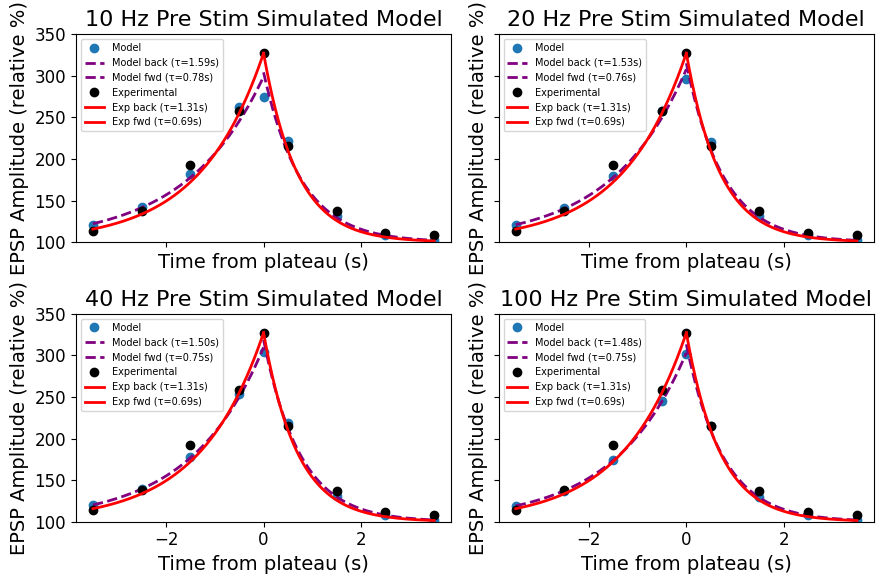

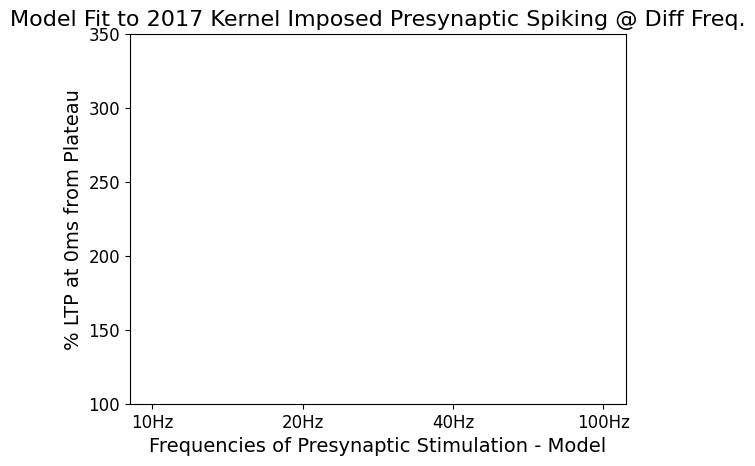

y_mod [0.21213811 0.41802777 0.82374268 1.6232223  1.75188794 1.21834326
 0.31763101 0.08203837 0.021189  ]
xx [0.         0.00877193 0.01754386 0.02631579 0.03508772 0.04385965
 0.05263158 0.06140351 0.07017544 0.07894737 0.0877193  0.09649123
 0.10526316 0.11403509 0.12280702 0.13157895 0.14035088 0.14912281
 0.15789474 0.16666667 0.1754386  0.18421053 0.19298246 0.20175439
 0.21052632 0.21929825 0.22807018 0.23684211 0.24561404 0.25438596
 0.26315789 0.27192982 0.28070175 0.28947368 0.29824561 0.30701754
 0.31578947 0.3245614  0.33333333 0.34210526 0.35087719 0.35964912
 0.36842105 0.37719298 0.38596491 0.39473684 0.40350877 0.4122807
 0.42105263 0.42982456 0.43859649 0.44736842 0.45614035 0.46491228
 0.47368421 0.48245614 0.49122807 0.5        0.50877193 0.51754386
 0.52631579 0.53508772 0.54385965 0.55263158 0.56140351 0.57017544
 0.57894737 0.5877193  0.59649123 0.60526316 0.61403509 0.62280702
 0.63157895 0.64035088 0.64912281 0.65789474 0.66666667 0.6754386
 0.68421053 0.692982

<Figure size 640x480 with 0 Axes>

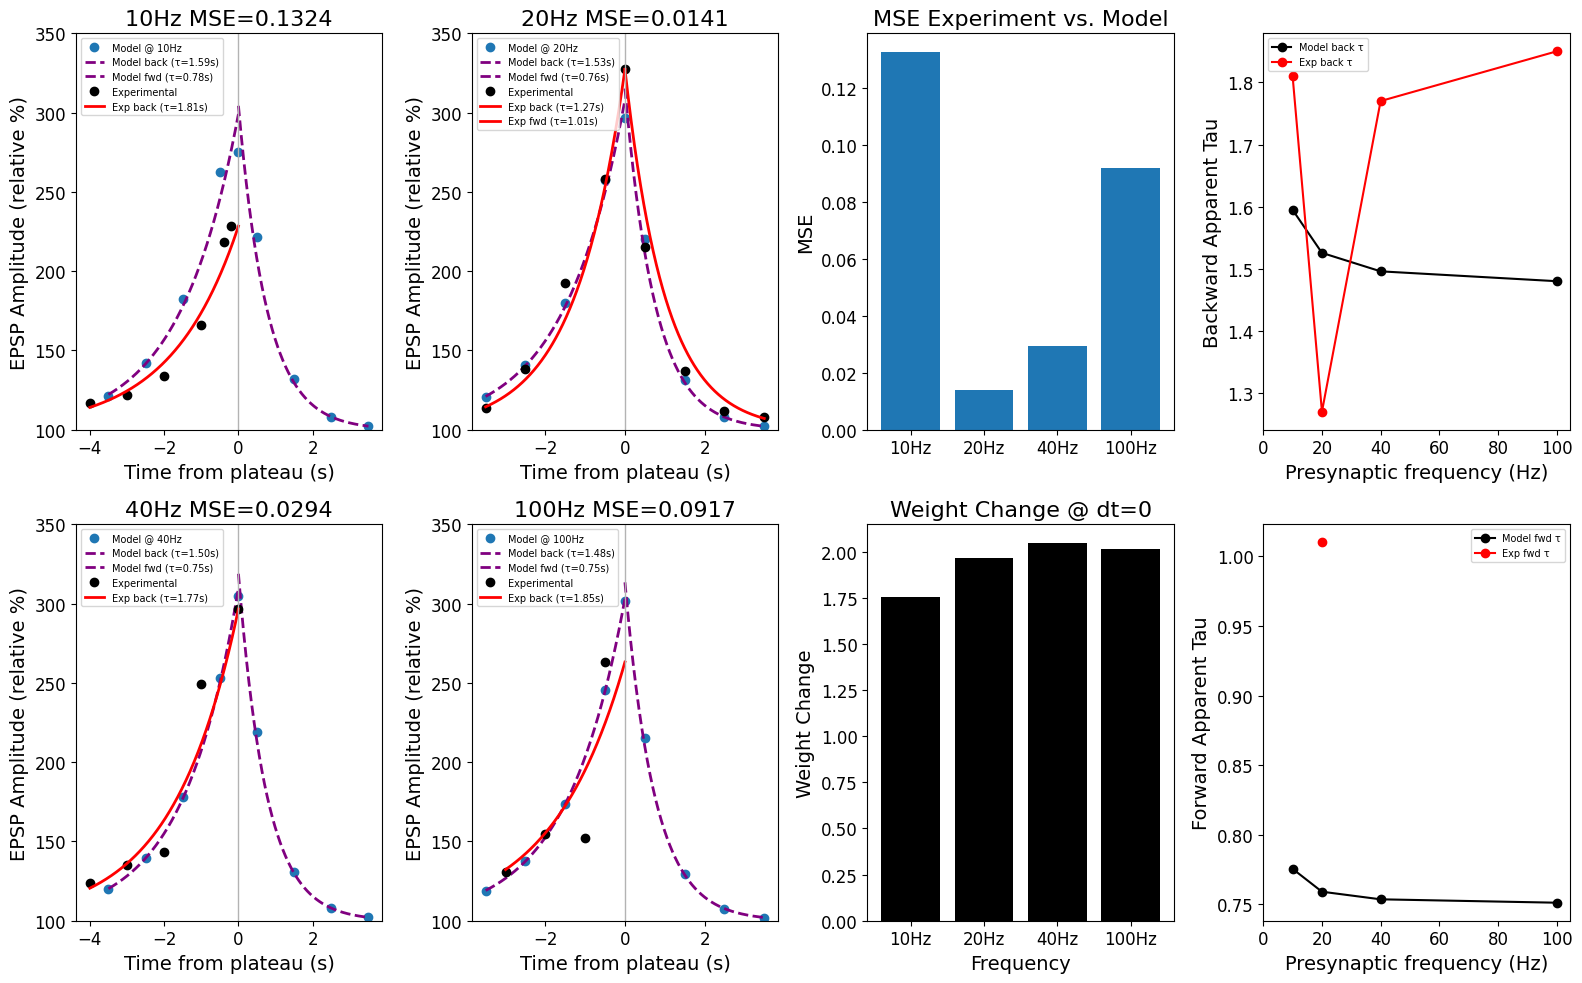

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_summary2(
    cleaned_data_dict,
    backwards_model_per_hz_dict,
    *,
    c_fixed=0.0,
    # use your exact experimental taus here
    exp_tau_back={10: 1.81, 40: 1.77, 100: 1.85, "20Hz_full_kernel": 1.27},
    exp_tau_fwd ={              "20Hz_full_kernel": 1.01},
    show_exp_fwd_tau_on_panel=True,   # whether to show the 20Hz full-kernel fwd tau in tau panel (at 20 Hz)
):
    """
    Same layout as your original plot_summary (2x4).

    Kernel panels:
      - 10/40/100: experimental points from cleaned_data_dict[hz] (backward-only)
      - 20: experimental points from cleaned_data_dict["20Hz_full_kernel"] ONLY
      - Overlay model points/lines from backwards_model_per_hz_dict
      - Add RED experimental exponential curve(s) using FIXED taus (no fitting)
        * backward arm always (if tau available)
        * forward arm only for 20Hz_full_kernel (if tau available)

    Tau panels:
      - keep plotting model taus (black), and ALSO overlay experimental taus (red)
        * exp backward taus at 10/40/100 and 20 (from full-kernel back tau)
        * exp forward tau only at 20 (optional)
    """

    fig, axs = plt.subplots(2, 4, figsize=(16, 10))
    axs_list = [axs[0,0], axs[0,1], axs[1,0], axs[1,1]]

    hzs_order = [10, 20, 40, 100]

    model_t0_list = []
    mse_list = []

    apparent_tau_model_list_backwards = []
    apparent_tau_model_list_forwards  = []

    apparent_tau_exp_list_backwards = []
    apparent_tau_exp_list_forwards  = []

    def _to_seconds(x_ms):
        return -np.asarray(x_ms, float) / 1000.0

    def _apex_value(x_s, y):
        x_s = np.asarray(x_s, float)
        y   = np.asarray(y, float)
        m = np.isfinite(x_s) & np.isfinite(y)
        x_s, y = x_s[m], y[m]
        o = np.argsort(x_s)
        x_s, y = x_s[o], y[o]
        if np.any(x_s == 0.0):
            return float(y[x_s == 0.0][0])
        return float(np.interp(0.0, x_s, y))

    def _exp_back_curve(t_neg, y0, tau_b):
        # t_neg <= 0
        return c_fixed + (y0 - c_fixed) * np.exp(t_neg / tau_b)

    def _exp_fwd_curve(t_pos, y0, tau_f):
        # t_pos >= 0
        return c_fixed + (y0 - c_fixed) * np.exp(-t_pos / tau_f)

    def _interp_model_at_exp_x(model_dict, x_exp_s):
        x_mod = np.asarray(model_dict["x_s"], float)
        y_mod = np.asarray(model_dict["y_mod"], float)
        m = np.isfinite(x_mod) & np.isfinite(y_mod)
        if m.sum() < 2:
            return np.full_like(x_exp_s, np.nan, dtype=float)
        o = np.argsort(x_mod[m])
        return np.interp(x_exp_s, x_mod[m][o], y_mod[m][o])

    for i, hz in enumerate(hzs_order):
        ax = axs_list[i]

        # --- model ---
        model_dict = backwards_model_per_hz_dict[hz]
        x_mod = np.asarray(model_dict["x_s"], float)
        y_mod = np.asarray(model_dict["y_mod"], float)

        # model points + model fits
        ax.plot(x_mod, y_mod, 'o', label=f"Model @ {hz}Hz", color='tab:blue')
        ax.plot(model_dict["xx_b"], model_dict["model_backwards_line"],
                '--', lw=2.0, color='purple', label=f"Model back (τ={model_dict['taumb']:.2f}s)")
        ax.plot(model_dict["xx_f"], model_dict["model_forwards_line"],
                '--', lw=2.0, color='purple', label=f"Model fwd (τ={model_dict['taumf']:.2f}s)")

        apparent_tau_model_list_backwards.append(model_dict.get("taumb", np.nan))
        apparent_tau_model_list_forwards.append(model_dict.get("taumf", np.nan))

        model_at_t0 = y_mod[4] if len(y_mod) > 4 else np.nan
        model_t0_list.append(model_at_t0)

        # --- experimental selection ---
        if hz == 20:
            exp = cleaned_data_dict["20Hz_full_kernel"]   # ONLY full kernel
        else:
            exp = cleaned_data_dict[hz]

        x_exp_s = _to_seconds(exp["x"])
        y_exp   = np.asarray(exp["y"], float)

        ax.plot(x_exp_s, y_exp, 'o', color='k', label="Experimental")

        # --- experimental red curve(s) using fixed taus ---
        y0 = _apex_value(x_exp_s, y_exp)

        # backward tau
        if hz == 20:
            tau_b = exp_tau_back.get("20Hz_full_kernel", np.nan)
        else:
            tau_b = exp_tau_back.get(hz, np.nan)

        apparent_tau_exp_list_backwards.append(tau_b)

        if np.isfinite(tau_b):
            tmin = float(np.nanmin(x_exp_s))
            tt_b = np.linspace(tmin, 0.0, 400)
            yy_b = _exp_back_curve(tt_b, y0, tau_b)
            ax.plot(tt_b, yy_b, '-', lw=2.0, color='red', label=f"Exp back (τ={tau_b:.2f}s)")

        # forward tau only for full kernel
        if hz == 20:
            tau_f = exp_tau_fwd.get("20Hz_full_kernel", np.nan)
            if not show_exp_fwd_tau_on_panel:
                # still store NaN so the tau plot doesn't show it
                apparent_tau_exp_list_forwards.append(np.nan)
            else:
                apparent_tau_exp_list_forwards.append(tau_f)

            if np.isfinite(tau_f):
                tmax = float(np.nanmax(x_exp_s))
                tt_f = np.linspace(0.0, tmax, 400)
                yy_f = _exp_fwd_curve(tt_f, y0, tau_f)
                ax.plot(tt_f, yy_f, '-', lw=2.0, color='red', label=f"Exp fwd (τ={tau_f:.2f}s)")
        else:
            apparent_tau_exp_list_forwards.append(np.nan)

        # --- MSE (interp model onto exp grid) ---
        y_mod_at_exp = _interp_model_at_exp_x(model_dict, x_exp_s)
        mse = np.nanmean((y_exp - y_mod_at_exp) ** 2)
        mse_list.append(mse)

        ax.set_title(f"{hz}Hz MSE={mse:.4f}" if hz != 20 else f"20Hz MSE={mse:.4f}")
        ax.set_xlabel("Time from plateau (s)")
        ax.set_ylabel("EPSP Amplitude (relative %)")
        ax.set_ylim(0, 2.50)
        ax.axvline(0.0, color='0.7', lw=1)

        custom_tick_locations = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5]
        custom_labels = ['100', '150', '200', '250', '300', '350']
        ax.set_yticks(custom_tick_locations)
        ax.set_yticklabels(custom_labels)
        ax.legend(fontsize=7, loc="upper left")

    # --- MSE bar (same as before) ---
    axs[0,2].bar(range(len(mse_list)), mse_list)
    axs[0,2].set_title("MSE Experiment vs. Model")
    axs[0,2].set_ylabel("MSE")
    axs[0,2].set_xticks(range(4), ["10Hz", "20Hz", "40Hz", "100Hz"])

    # --- Weight change @ dt=0 ---
    axs[1,2].bar(range(len(model_t0_list)), model_t0_list, color='k')
    axs[1,2].set_xticks(range(4), ["10Hz", "20Hz", "40Hz", "100Hz"])
    axs[1,2].set_ylabel("Weight Change")
    axs[1,2].set_title("Weight Change @ dt=0")
    axs[1,2].set_xlabel("Frequency")

    # --- Tau panels: now include EXP taus (red) + MODEL taus (black) ---
    hzs = np.array([10, 20, 40, 100], float)

    # backward tau
    axs[0,3].plot(hzs, apparent_tau_model_list_backwards, '-o', color='k', label="Model back τ")
    axs[0,3].plot(hzs, apparent_tau_exp_list_backwards, '-o', color='red', label="Exp back τ")
    axs[0,3].set_ylabel("Backward Apparent Tau")
    axs[0,3].set_xlim(left=0)
    axs[0,3].set_xticks([0, 20, 40, 60, 80, 100])
    axs[0,3].set_xlabel("Presynaptic frequency (Hz)")
    axs[0,3].legend(fontsize=7, loc="best")

    # forward tau
    axs[1,3].plot(hzs, apparent_tau_model_list_forwards, '-o', color='k', label="Model fwd τ")
    axs[1,3].plot(hzs, apparent_tau_exp_list_forwards, '-o', color='red', label="Exp fwd τ")
    axs[1,3].set_ylabel("Forward Apparent Tau")
    axs[1,3].set_xlim(left=0)
    axs[1,3].set_xticks([0, 20, 40, 60, 80, 100])
    axs[1,3].set_xlabel("Presynaptic frequency (Hz)")
    axs[1,3].legend(fontsize=7, loc="best")

    plt.tight_layout()
    plt.show()

backwards_experiment_per_hz_dict, backwards_model_per_hz_dict = plot_jeff2(
    params_cl, cleaned_data_dict, plot_full_intermediates, handin_hz="20Hz_full_kernel"
)

plot_summary2(
    cleaned_data_dict,
    backwards_model_per_hz_dict,
    exp_tau_back={10: 1.81, 40: 1.77, 100: 1.85, "20Hz_full_kernel": 1.27},
    exp_tau_fwd={"20Hz_full_kernel": 1.01},
)

In [ ]:
plt.rcParams.update({
    # overall defaults
    "font.size": 12,

    # axes titles/labels
    "axes.titlesize": 16,
    "axes.labelsize": 14,

    # tick labels
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,

    # legend
    "legend.fontsize": 14,
    "legend.title_fontsize": 14,

    # figure suptitle (plt.suptitle)
    "figure.titlesize": 18,
})

plt.rcParams.update({
    "legend.fontsize": 9,        # <-- increase this
    "legend.title_fontsize": 9,  # <-- only matters if you set legend title
})


k 10
k 20
k 40
k 100
k 20Hz_full_kernel


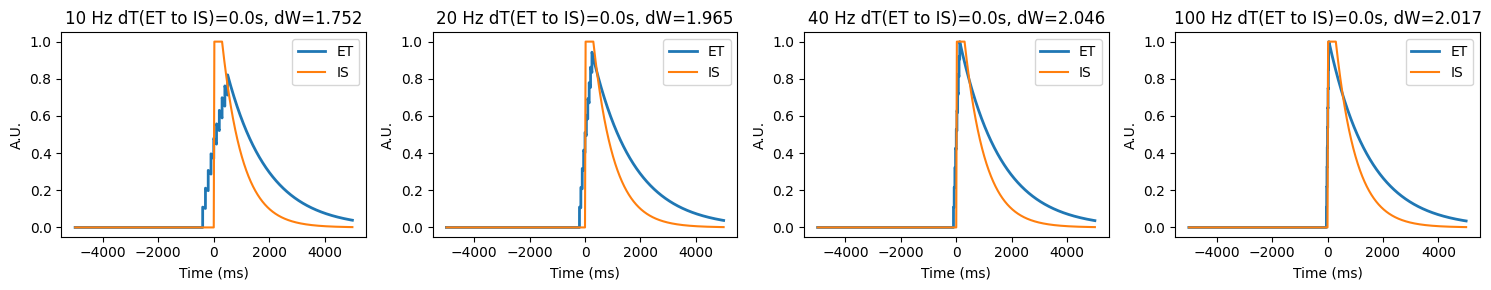

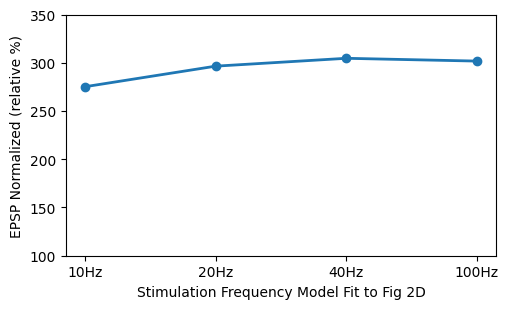

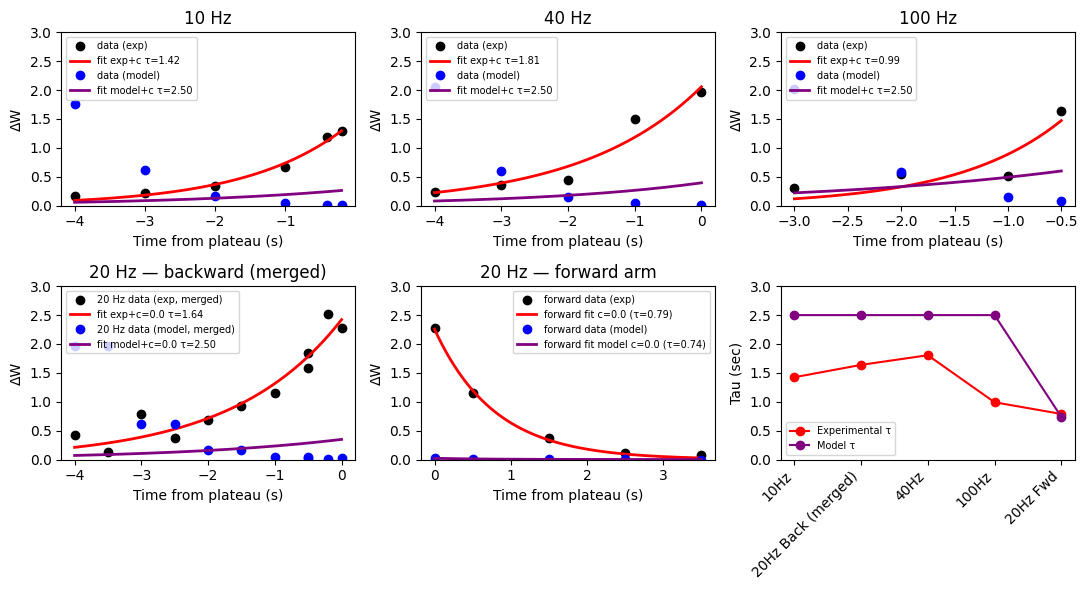

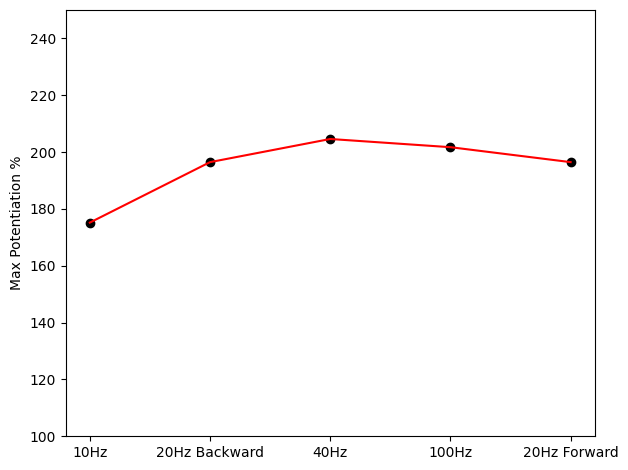

products_dict.keys <built-in method keys of dict object at 0x1474825c0> products_dict {10: {'x': array([4000, 3000, 2000, 1000,  400,  200]), 'y': array([1.75188794, 0.62499394, 0.16142469, 0.04169307, 0.0185063 ,
       0.01411686]), 'params_dict': {'tau_et': 1474.7515259682878, 'tau_is': 739.2145185588507, 'lam_et': 161.24381107148224, 'lam_is': 39.57778784397287, 'eta_ms': 0.002976991280586468}}, 20: {'x': array([4000, 3000, 2000, 1000,  500,  200]), 'y': array([1.96469263, 0.61152262, 0.15794529, 0.04079441, 0.02073229,
       0.01381258]), 'params_dict': {'tau_et': 1474.7515259682878, 'tau_is': 739.2145185588507, 'lam_et': 161.24381107148224, 'lam_is': 39.57778784397287, 'eta_ms': 0.002976991280586468}}, 40: {'x': array([4000, 3000, 2000, 1000,    0]), 'y': array([2.04608617, 0.6064233 , 0.15662823, 0.04045424, 0.01044856]), 'params_dict': {'tau_et': 1474.7515259682878, 'tau_is': 739.2145185588507, 'lam_et': 161.24381107148224, 'lam_is': 39.57778784397287, 'eta_ms': 0.002976991280

/Users/michaelfinch/CA1-interneuron-GLM/ching_lung/Exploring_BTSP.py:1991: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  tau_ax.plot(hz_sorted, tau_mod, "-o", color="tab:blue", label="Model τ", linestyle="--")


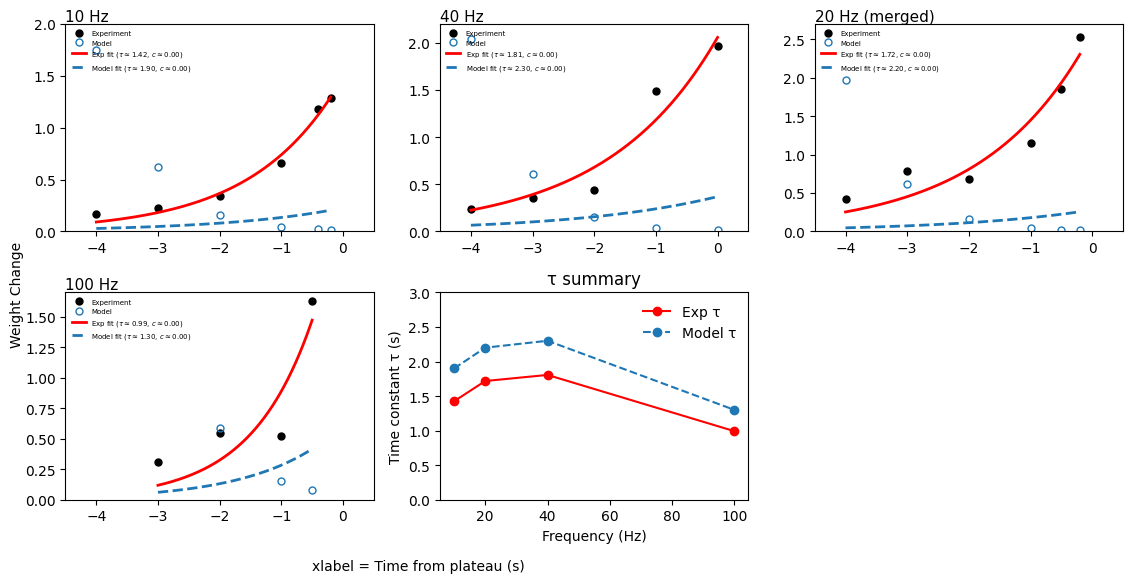

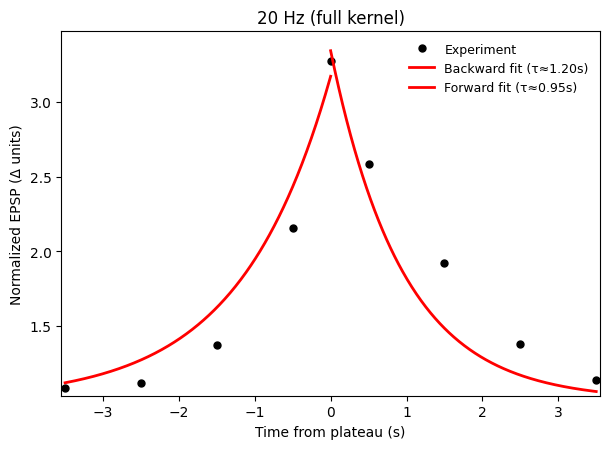

Full-kernel τ (paper-style): backward= 1.2  forward= 0.95


In [ ]:


# params={"tau_et": 1410.393447456833,
#   "tau_is": 176.34929097902682,
#   "lam_et": 152.5684059500006,
#   "lam_is": 25.744490638121604,
#   "eta_ms": 0.004998600162125412}
save_path = "/Users/michaelfinch/CA1-interneuron-GLM/ching_lung/pickle_of_all_experimental_data.pkl"
with open(save_path, 'rb') as f:
    cleaned_data_dict = pickle.load(f)

plot_ching_lung2(cleaned_data_dict, params, plot_full_intermediates=False, special_case=True)

delta_w_list (hz=10): [0.1872531932179919, 0.8013648840834129, 1.174866404793039, 1.609389104289326, 1.5608633306323105, 1.3869656898332592, 0.7935124244175977, 0.09476196639716257]
delta_w_list (hz=20): [0.18042736374927665, 0.7721532057832067, 1.132039697329075, 1.659662702596752, 1.8033177083369243, 1.5326442222337653, 0.7482934938917708, 0.08895321197838811]
delta_w_list (hz=40): [0.17790360245214754, 0.7613525692516147, 1.1162050815836364, 1.636447861964697, 1.9258902491922985, 1.5681692455181153, 0.7449269726620311, 0.08855301756415175]
delta_w_list (hz=100): [0.17666148732592865, 0.7560368391055217, 1.1084117868066468, 1.625022254980923, 1.9975579859681116, 1.5903278255247895, 0.7497258818468034, 0.08912348675788682]
y_mod [0.18725319 0.80136488 1.1748664  1.6093891  1.56086333 1.38696569
 0.79351242 0.09476197]
y_mod [0.18042736 0.77215321 1.1320397  1.6596627  1.80331771 1.53264422
 0.74829349 0.08895321]
y_mod [0.1779036  0.76135257 1.11620508 1.63644786 1.92589025 1.56816925

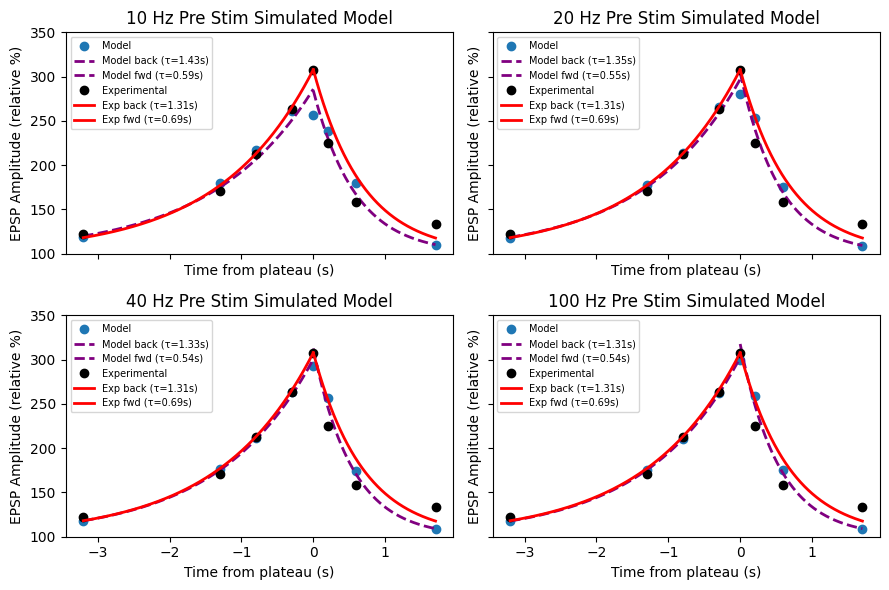

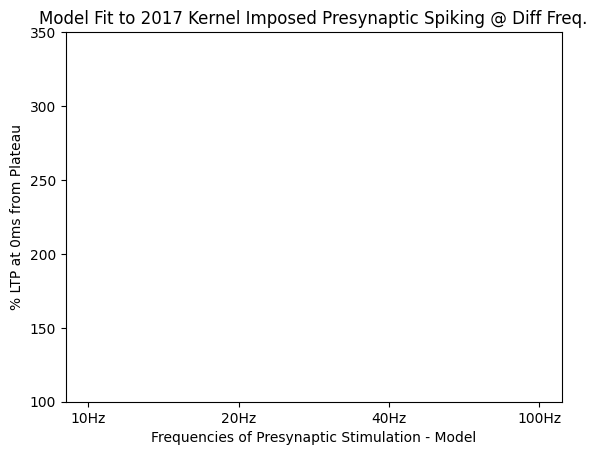

y_mod [0.18725319 0.80136488 1.1748664  1.6093891  1.56086333 1.38696569
 0.79351242 0.09476197]
xx [0.         0.00426065 0.0085213  0.01278195 0.01704261 0.02130326
 0.02556391 0.02982456 0.03408521 0.03834586 0.04260652 0.04686717
 0.05112782 0.05538847 0.05964912 0.06390977 0.06817043 0.07243108
 0.07669173 0.08095238 0.08521303 0.08947368 0.09373434 0.09799499
 0.10225564 0.10651629 0.11077694 0.11503759 0.11929825 0.1235589
 0.12781955 0.1320802  0.13634085 0.1406015  0.14486216 0.14912281
 0.15338346 0.15764411 0.16190476 0.16616541 0.17042607 0.17468672
 0.17894737 0.18320802 0.18746867 0.19172932 0.19598997 0.20025063
 0.20451128 0.20877193 0.21303258 0.21729323 0.22155388 0.22581454
 0.23007519 0.23433584 0.23859649 0.24285714 0.24711779 0.25137845
 0.2556391  0.25989975 0.2641604  0.26842105 0.2726817  0.27694236
 0.28120301 0.28546366 0.28972431 0.29398496 0.29824561 0.30250627
 0.30676692 0.31102757 0.31528822 0.31954887 0.32380952 0.32807018
 0.33233083 0.33659148 0.34085

<Figure size 640x480 with 0 Axes>

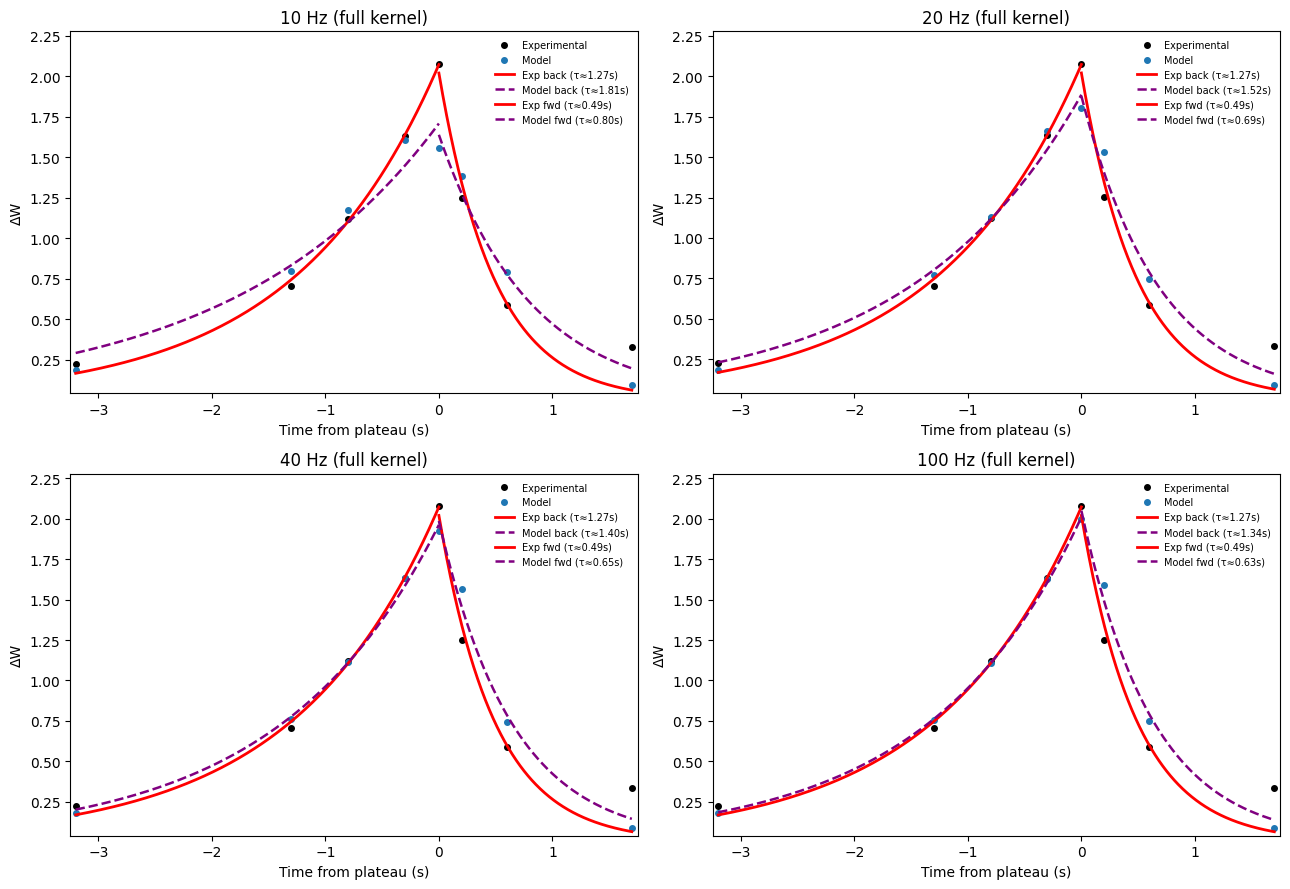

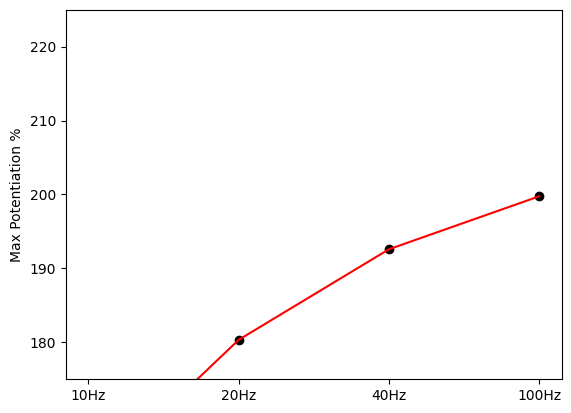

In [2]:

plot_full_intermediates=True
params_jeff = {
"tau_et": 1307.3706852728226,
"tau_is": 517.0085321387273,
"lam_et": 119.87951416286887,
"lam_is": 49.984596145977214,
"eta_ms": 0.003982527270809444}

# params={"tau_et": 1410.393447456833,
#   "tau_is": 176.34929097902682,
#   "lam_et": 152.5684059500006,
#   "lam_is": 25.744490638121604,
#   "eta_ms": 0.004998600162125412}


save_path = "/Users/michaelfinch/CA1-interneuron-GLM/ching_lung/jeffs_data_csv.pkl"
with open(save_path, 'rb') as f:
    jeffs_data_dict = pickle.load(f)


backwards_experiment_per_hz_dict, backwards_model_per_hz_dict = plot_jeff2(params_jeff, jeffs_data_dict, plot_full_intermediates)

In [2]:
backwards_model_per_hz_dict[10].keys()

NameError: name 'backwards_model_per_hz_dict' is not defined

model_dict['x_s'] -0.0
model_dict['x_s'] -0.0
model_dict['x_s'] -0.0
model_dict['x_s'] -0.0


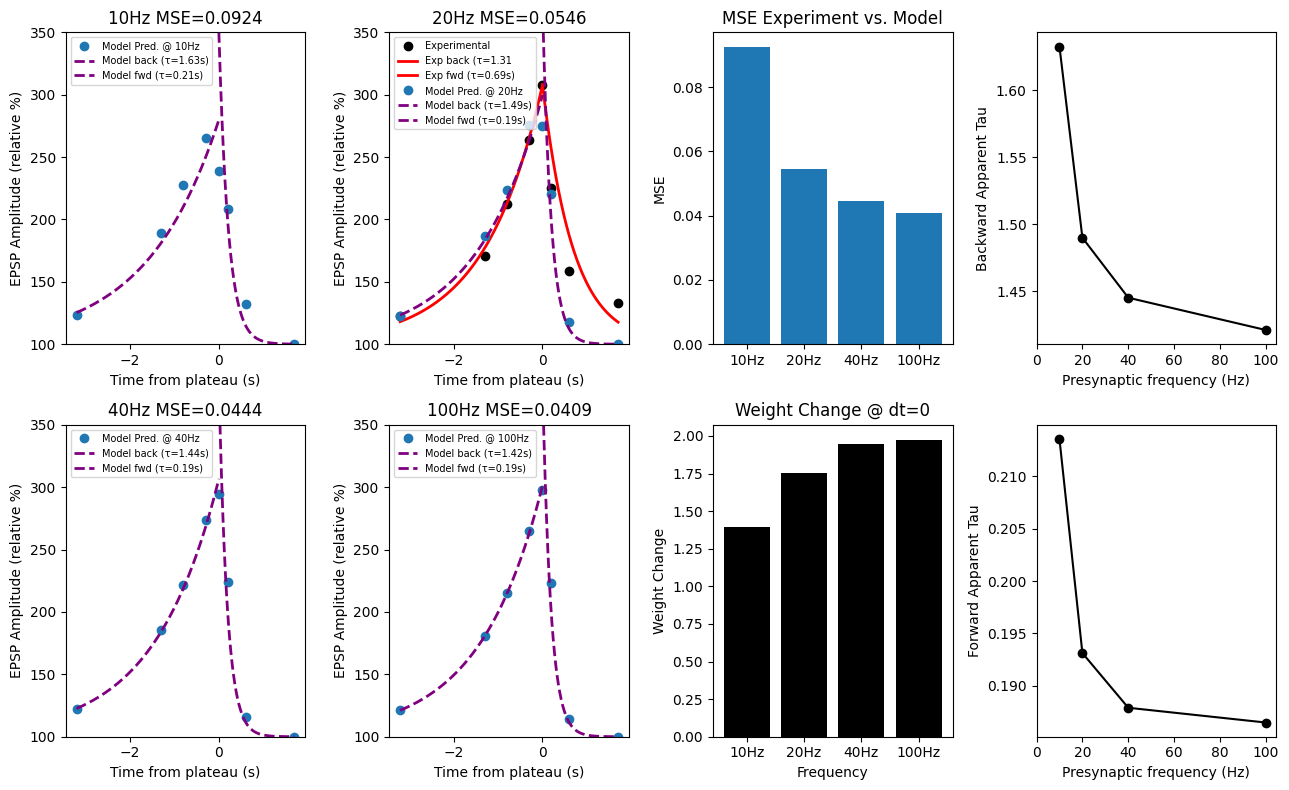

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def plot_summary(backwards_experiment_per_hz_dict, backwards_model_per_hz_dict):
    fig, axs  = plt.subplots(2,4, figsize=(13,8))

    axs_list = [axs[0,0], axs[0,1], axs[1,0], axs[1,1]]

    model_t0_list = []


    apparent_tau_model_list_backwards = []
    apparent_tau_model_list_forwards = []

    mse_list = []

    for i, hz in enumerate(backwards_experiment_per_hz_dict):
        back_dict = backwards_experiment_per_hz_dict[hz]

        model_dict = backwards_model_per_hz_dict[hz]


        model_at_t0 = model_dict['y_mod'][4]
        model_t0_list.append(model_at_t0)

        print(f"model_dict['x_s'] {model_dict['x_s'][4]}")

        ax = axs_list[i]

        
        label_exp = "Experimental"
        if hz==20:
            ax.plot(back_dict["x_exp_s_backward"], back_dict["y_exp_s_backward"], 'o', color='k', label=label_exp if hz ==20 else None)
            label_tau = f'Exp back (τ={back_dict["TAU_BACK_PAPER"]:.2f}'
            ax.plot(back_dict["xx_b"], back_dict["yy_b"], '-', lw=2.0, color='red', label=label_tau if hz ==20 else None)
            ax.plot(back_dict["xx_f"], back_dict["yy_f"], '-', lw=2.0, color='red', label=f'Exp fwd (τ={back_dict["TAU_FWD_PAPER"]:.2f}s)')

        ax.plot(model_dict["x_s"], model_dict["y_mod"], 'o', label=f"Model Pred. @ {hz}Hz", color='tab:blue')
        ax.plot(model_dict["xx_b"], model_dict["model_backwards_line"], '--', lw=2.0, color='purple', label=f"Model back (τ={model_dict['taumb']:.2f}s)")
        ax.plot(model_dict["xx_f"], model_dict["model_forwards_line"], '--', lw=2.0, color='purple', label=f"Model fwd (τ={model_dict['taumf']:.2f}s)")

        apparent_tau_model_list_backwards.append(model_dict['taumb'])
        apparent_tau_model_list_forwards.append(model_dict['taumf'])

        mse = np.mean(np.square(back_dict['y_exp_s_backward']-model_dict['y_mod']))

        mse_list.append(mse)

        ax.set_title(f"{hz}Hz MSE={mse:.4f}")
        ax.set_xlabel("Time from plateau (s)")
        ax.set_ylabel("EPSP Amplitude (relative %)") #("ΔW")
        ax.set_ylim(0, 2.50)
        custom_tick_locations = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5]
        custom_labels = ['100', '150', '200', '250', '300', '350']
        ax.set_yticks(custom_tick_locations)
        ax.set_yticklabels(custom_labels)
        ax.legend(fontsize=7, loc="upper left")

    axs[0,2].bar(range(len(mse_list)), mse_list)
    axs[0,2].set_title("MSE Experiment vs. Model")
    axs[0,2].set_ylabel("MSE")
    axs[0,2].set_xticks(range(4), ["10Hz", "20Hz", "40Hz", "100Hz"])

    axs[1,2].bar(range(len(model_t0_list)),model_t0_list, color='k')
    axs[1,2].set_xticks(range(4), ["10Hz", "20Hz", "40Hz", "100Hz"])
    axs[1,2].set_ylabel("Weight Change")
    axs[1,2].set_title("Weight Change @ dt=0")
    axs[1,2].set_xlabel("Frequency")



    # long_range = np.arange(101)
    # hzs=[10, 20, 40, 100]
    # for i, hz in enumerate(hzs):
    #     axs[0,3].plot(long_range[hz], apparent_tau_model_list_backwards[i], marker='o', color='k')
    #     axs[0,3].set_ylabel("Backward Apparent Tau")


    #     axs[1,3].plot(long_range[hz], apparent_tau_model_list_forwards[i], marker='o', color='k')
    #     axs[1,3].set_ylabel("Forward Apparent Tau")

    hzs = np.array([10, 20, 40, 100])

    axs[0,3].plot(hzs, apparent_tau_model_list_backwards, '-o', color='k')
    axs[0,3].set_ylabel("Backward Apparent Tau")

    axs[1,3].plot(hzs, apparent_tau_model_list_forwards, '-o', color='k')
    axs[1,3].set_ylabel("Forward Apparent Tau")

    axs[0,3].set_xlim(left=0)
    axs[1,3].set_xlim(left=0)

    axs[0,3].set_xticks([0, 20, 40, 60, 80, 100])
    axs[1,3].set_xticks([0, 20, 40, 60, 80, 100])
    axs[0,3].set_xlabel("Presynaptic frequency (Hz)")
    axs[1,3].set_xlabel("Presynaptic frequency (Hz)")


    plt.tight_layout()
    plt.show()

plot_summary(backwards_experiment_per_hz_dict, backwards_model_per_hz_dict)


model_dict['x_s'] -0.5
model_dict['x_s'] -0.5
model_dict['x_s'] -0.5
model_dict['x_s'] -0.5


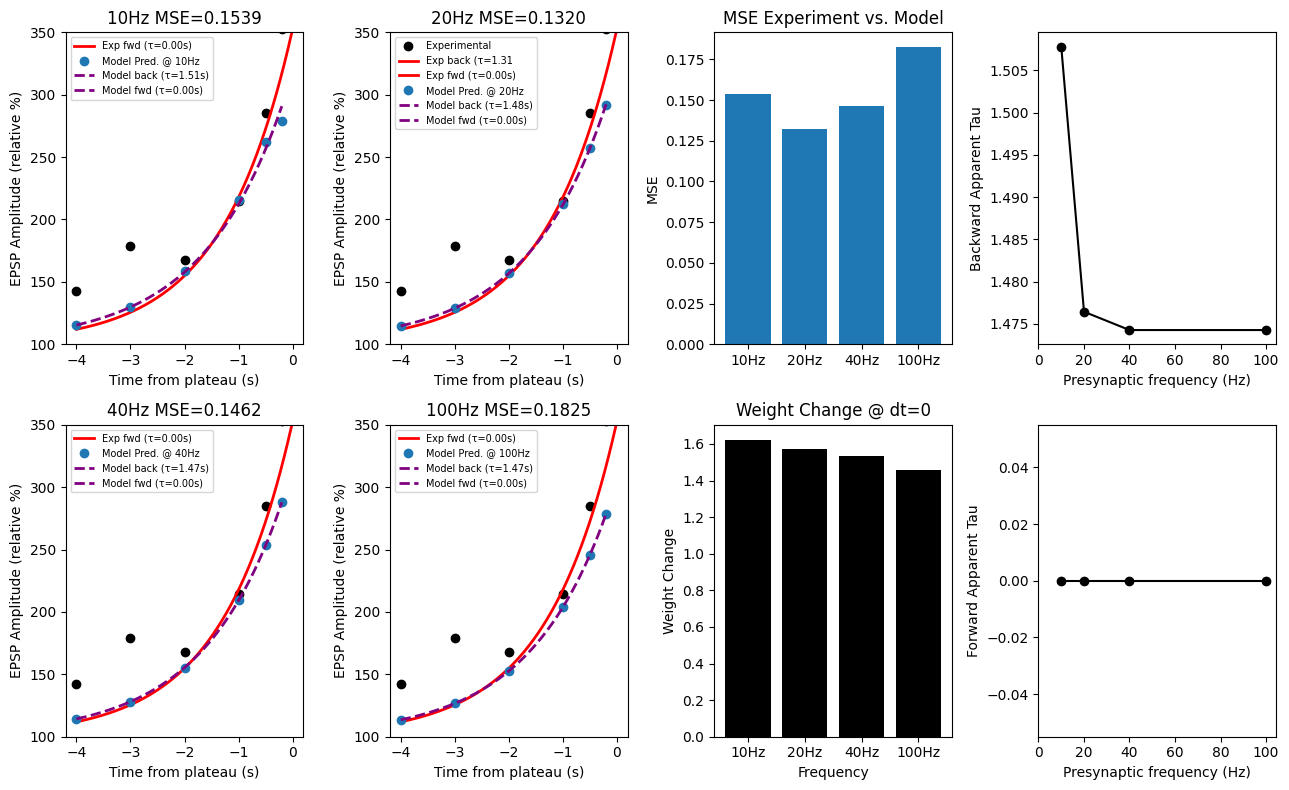

In [ ]:

def plot_summary_ching_lung(cleaned_data_dict, backwards_model_per_hz_dict):
    fig, axs  = plt.subplots(2,4, figsize=(13,8))

    axs_list = [axs[0,0], axs[0,1], axs[1,0], axs[1,1]]

    model_t0_list = []


    apparent_tau_model_list_backwards = []
    apparent_tau_model_list_forwards = []

    mse_list = []

    for i, hz in enumerate(backwards_experiment_per_hz_dict):
        back_dict = backwards_experiment_per_hz_dict[hz]

        model_dict = backwards_model_per_hz_dict[hz]


        model_at_t0 = model_dict['y_mod'][4]
        model_t0_list.append(model_at_t0)

        print(f"model_dict['x_s'] {model_dict['x_s'][4]}")

        ax = axs_list[i]

        
        label_exp = "Experimental"
        # if hz==20:
        ax.plot(back_dict["x_exp_s_backward"], back_dict["y_exp_s_backward"], 'o', color='k', label=label_exp if hz ==20 else None)
        label_tau = f'Exp back (τ={back_dict["TAU_BACK_PAPER"]:.2f}'
        ax.plot(back_dict["xx_b"], back_dict["yy_b"], '-', lw=2.0, color='red', label=label_tau if hz ==20 else None)
        ax.plot(back_dict["xx_f"], back_dict["yy_f"], '-', lw=2.0, color='red', label=f'Exp fwd (τ={back_dict["TAU_FWD_PAPER"]:.2f}s)')

        ax.plot(model_dict["x_s"], model_dict["y_mod"], 'o', label=f"Model Pred. @ {hz}Hz", color='tab:blue')
        ax.plot(model_dict["xx_b"], model_dict["model_backwards_line"], '--', lw=2.0, color='purple', label=f"Model back (τ={model_dict['taumb']:.2f}s)")
        ax.plot(model_dict["xx_f"], model_dict["model_forwards_line"], '--', lw=2.0, color='purple', label=f"Model fwd (τ={model_dict['taumf']:.2f}s)")

        apparent_tau_model_list_backwards.append(model_dict['taumb'])
        apparent_tau_model_list_forwards.append(model_dict['taumf'])

        mse = np.mean(np.square(back_dict['y_exp_s_backward']-model_dict['y_mod']))

        mse_list.append(mse)

        ax.set_title(f"{hz}Hz MSE={mse:.4f}")
        ax.set_xlabel("Time from plateau (s)")
        ax.set_ylabel("EPSP Amplitude (relative %)") #("ΔW")
        ax.set_ylim(0, 2.50)
        custom_tick_locations = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5]
        custom_labels = ['100', '150', '200', '250', '300', '350']
        ax.set_yticks(custom_tick_locations)
        ax.set_yticklabels(custom_labels)
        ax.legend(fontsize=7, loc="upper left")

    axs[0,2].bar(range(len(mse_list)), mse_list)
    axs[0,2].set_title("MSE Experiment vs. Model")
    axs[0,2].set_ylabel("MSE")
    axs[0,2].set_xticks(range(4), ["10Hz", "20Hz", "40Hz", "100Hz"])

    axs[1,2].bar(range(len(model_t0_list)),model_t0_list, color='k')
    axs[1,2].set_xticks(range(4), ["10Hz", "20Hz", "40Hz", "100Hz"])
    axs[1,2].set_ylabel("Weight Change")
    axs[1,2].set_title("Weight Change @ dt=0")
    axs[1,2].set_xlabel("Frequency")



    # long_range = np.arange(101)
    # hzs=[10, 20, 40, 100]
    # for i, hz in enumerate(hzs):
    #     axs[0,3].plot(long_range[hz], apparent_tau_model_list_backwards[i], marker='o', color='k')
    #     axs[0,3].set_ylabel("Backward Apparent Tau")


    #     axs[1,3].plot(long_range[hz], apparent_tau_model_list_forwards[i], marker='o', color='k')
    #     axs[1,3].set_ylabel("Forward Apparent Tau")

    hzs = np.array([10, 20, 40, 100])

    axs[0,3].plot(hzs, apparent_tau_model_list_backwards, '-o', color='k')
    axs[0,3].set_ylabel("Backward Apparent Tau")

    axs[1,3].plot(hzs, apparent_tau_model_list_forwards, '-o', color='k')
    axs[1,3].set_ylabel("Forward Apparent Tau")

    axs[0,3].set_xlim(left=0)
    axs[1,3].set_xlim(left=0)

    axs[0,3].set_xticks([0, 20, 40, 60, 80, 100])
    axs[1,3].set_xticks([0, 20, 40, 60, 80, 100])
    axs[0,3].set_xlabel("Presynaptic frequency (Hz)")
    axs[1,3].set_xlabel("Presynaptic frequency (Hz)")


    plt.tight_layout()
    plt.show()

plot_summary_ching_lung(backwards_experiment_per_hz_dict, backwards_model_per_hz_dict)

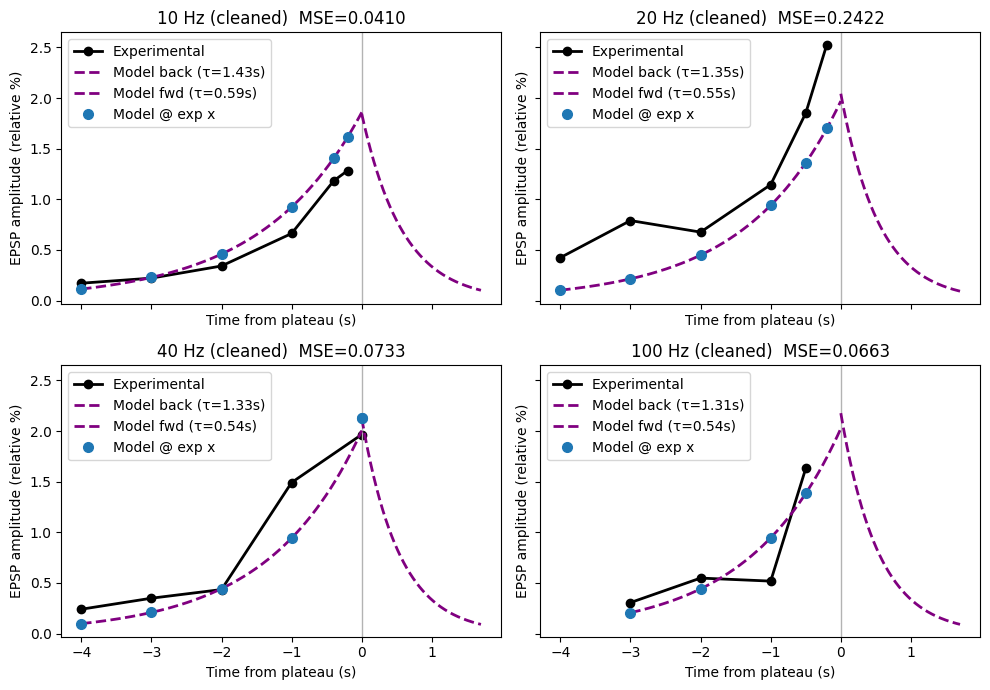

In [7]:
import numpy as np
import matplotlib.pyplot as plt


def exp_with_fixed_c(x, A, tau, c_fixed):
    return float(c_fixed) + A*np.exp(x/float(tau))


def plot_cleaned_data_2x2(backwards_model_per_hz_dict, cleaned_data_dict, hzs=(10, 20, 40, 100), x_units="s"):
    fig, axs = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
    axs = axs.ravel()

    def mse_vs_tau_curve_and_points(x_exp, y_exp, xx_b, yy_b, xx_f, yy_f):
        """
        Compare exp points (x_exp, y_exp) to tau-fit curves (xx_b,yy_b) & (xx_f,yy_f),
        by sampling the curves at the exp x locations.
        Returns:
          mse,
          yhat_on_exp (same length as x_exp, NaN where out-of-domain),
          sampled back points (x_b_pts, y_b_pts),
          sampled fwd points (x_f_pts, y_f_pts)
        """
        x_exp = np.asarray(x_exp, float)
        y_exp = np.asarray(y_exp, float)

        yhat = np.full_like(y_exp, np.nan, dtype=float)

        # --- back arm ---
        xb = np.asarray(xx_b, float); yb = np.asarray(yy_b, float)
        mb = np.isfinite(xb) & np.isfinite(yb)
        xb, yb = xb[mb], yb[mb]
        if xb.size >= 2:
            ob = np.argsort(xb); xb, yb = xb[ob], yb[ob]
            m_exp_b = (x_exp <= 0) & (x_exp >= xb.min()) & (x_exp <= xb.max())
            yhat[m_exp_b] = np.interp(x_exp[m_exp_b], xb, yb)

        # --- fwd arm ---
        xf = np.asarray(xx_f, float); yf = np.asarray(yy_f, float)
        mf = np.isfinite(xf) & np.isfinite(yf)
        xf, yf = xf[mf], yf[mf]
        if xf.size >= 2:
            of = np.argsort(xf); xf, yf = xf[of], yf[of]
            m_exp_f = (x_exp >= 0) & (x_exp >= xf.min()) & (x_exp <= xf.max())
            yhat[m_exp_f] = np.interp(x_exp[m_exp_f], xf, yf)

        m = np.isfinite(y_exp) & np.isfinite(yhat)
        mse = np.nan if m.sum() < 2 else float(np.mean((y_exp[m] - yhat[m]) ** 2))

        xb_pts = x_exp[m & (x_exp <= 0)]
        yb_pts = yhat[m & (x_exp <= 0)]
        xf_pts = x_exp[m & (x_exp >= 0)]
        yf_pts = yhat[m & (x_exp >= 0)]

        return mse, yhat, (xb_pts, yb_pts), (xf_pts, yf_pts)

    for i, hz in enumerate(hzs):
        ax = axs[i]
        model_dict = backwards_model_per_hz_dict[hz]

        x = np.asarray(cleaned_data_dict[hz]["x"], float)
        y = np.asarray(cleaned_data_dict[hz]["y"], float)

        # convert ms -> seconds from plateau
        if x_units == "s":
            x_plot = -x / 1000.0
            ax.set_xlabel("Time from plateau (s)")
        else:
            x_plot = -x
            ax.set_xlabel("Time from plateau (ms)")

        # sort exp for plotting lines cleanly
        o = np.argsort(x_plot)
        x_plot = x_plot[o]
        y = y[o]

        # ---------------------------------------------------------------------
        # DROP-IN: extend Jeff tau curves so they span ALL experimental x values
        # ---------------------------------------------------------------------
        x_min = float(np.nanmin(x_plot))
        x_max = float(np.nanmax(x_plot))

        # make sure keys exist; you need Amb + Amf stored in model_dict upstream
        # (add "Amf": Amf when building backwards_model_per_hz_dict)
        if np.isfinite(x_min) and x_min < 0:
            model_dict["xx_b"] = np.linspace(x_min, 0.0, 800)
            model_dict["model_backwards_line"] = exp_with_fixed_c(
                model_dict["xx_b"], model_dict["Amb"], model_dict["taumb"], c_fixed=0.0
            )

        if np.isfinite(x_max) and x_max > 0:
            model_dict["xx_f"] = np.linspace(0.0, x_max, 800)
            model_dict["model_forwards_line"] = exp_with_fixed_c(
                -model_dict["xx_f"], model_dict["Amf"], model_dict["taumf"], c_fixed=0.0
            )
        # ---------------------------------------------------------------------

        # --- experimental (Ching-Lung) ---
        ax.plot(x_plot, y, "-o", color="k", lw=2, ms=6, label="Experimental")
        ax.axvline(0, color="0.7", lw=1)

        # --- Jeff tau-fit curves (continuous) ---
        ax.plot(model_dict["xx_b"], model_dict["model_backwards_line"],
                "--", lw=2.0, color="purple", label=f"Model back (τ={model_dict['taumb']:.2f}s)")
        ax.plot(model_dict["xx_f"], model_dict["model_forwards_line"],
                "--", lw=2.0, color="purple", label=f"Model fwd (τ={model_dict['taumf']:.2f}s)")

        # --- MSE vs tau curves, using sampled points at exp x's ---
        mse, yhat, (xb_pts, yb_pts), (xf_pts, yf_pts) = mse_vs_tau_curve_and_points(
            x_exp=x_plot, y_exp=y,
            xx_b=model_dict["xx_b"], yy_b=model_dict["model_backwards_line"],
            xx_f=model_dict["xx_f"], yy_f=model_dict["model_forwards_line"],
        )

        # points actually used for MSE (now includes the most-negative ones)
        ax.plot(xb_pts, yb_pts, "o", ms=7, color="tab:blue", label="Model @ exp x")
        ax.plot(xf_pts, yf_pts, "o", ms=7, color="tab:blue")

        ax.set_title(f"{hz} Hz (cleaned)  MSE={mse:.4f}")
        ax.set_ylabel("EPSP amplitude (relative %)")

        ax.legend(loc="upper left")

    plt.tight_layout()
    plt.show()

plot_cleaned_data_2x2(backwards_model_per_hz_dict, cleaned_data_dict, hzs=(10, 20, 40, 100), x_units="s")

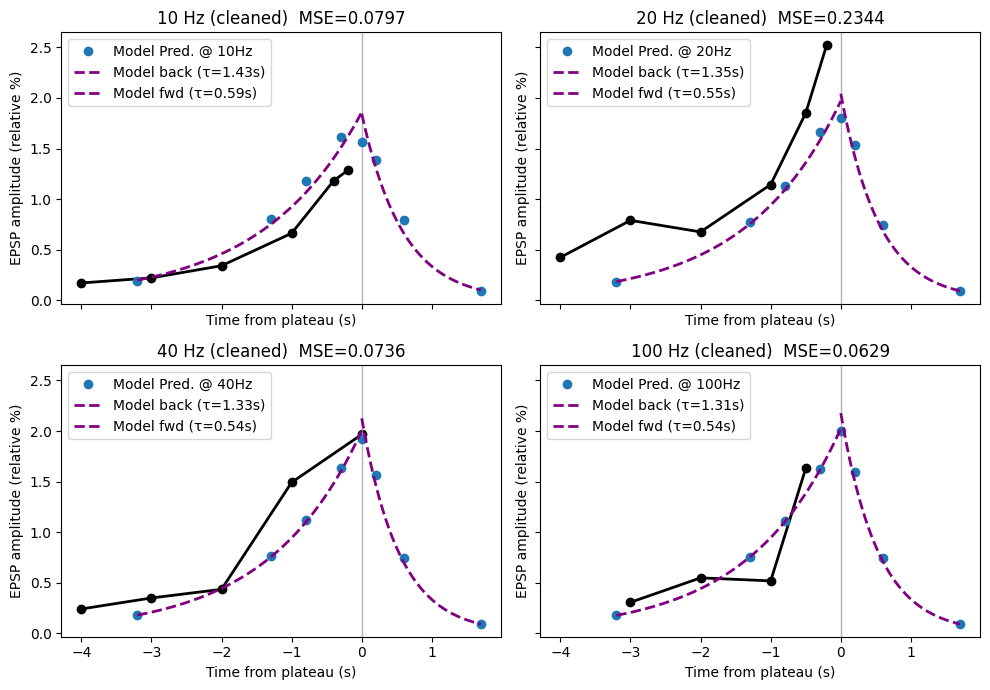

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def plot_cleaned_data_2x2(backwards_model_per_hz_dict, cleaned_data_dict, hzs=(10, 20, 40, 100), x_units="s"):
    fig, axs = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
    axs = axs.ravel()

    def mse_on_common_x(x_exp, y_exp, x_model, y_model):
        """
        Compute MSE comparing y_model to y_exp on x_exp grid.
        Assumes x_model iimport numpy as np
import matplotlib.pyplot as plt

def plot_cleaned_data_2x2(backwards_model_per_hz_dict, cleaned_data_dict, hzs=(10, 20, 40, 100), x_units="s"):
    fig, axs = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
    axs = axs.ravel()

    def mse_vs_tau_curve_and_points(x_exp, y_exp, xx_b, yy_b, xx_f, yy_f):
        x_exp = np.asarray(x_exp, float)
        y_exp = np.asarray(y_exp, float)

        yhat = np.full_like(y_exp, np.nan, dtype=float)

        # back arm
        xb = np.asarray(xx_b, float); yb = np.asarray(yy_b, float)
        mb = np.isfinite(xb) & np.isfinite(yb)
        xb, yb = xb[mb], yb[mb]
        if xb.size >= 2:
            ob = np.argsort(xb); xb, yb = xb[ob], yb[ob]
            m_exp_b = (x_exp <= 0) & (x_exp >= xb.min()) & (x_exp <= xb.max())
            yhat[m_exp_b] = np.interp(x_exp[m_exp_b], xb, yb)

        # fwd arm
        xf = np.asarray(xx_f, float); yf = np.asarray(yy_f, float)
        mf = np.isfinite(xf) & np.isfinite(yf)
        xf, yf = xf[mf], yf[mf]
        if xf.size >= 2:
            of = np.argsort(xf); xf, yf = xf[of], yf[of]
            m_exp_f = (x_exp >= 0) & (x_exp >= xf.min()) & (x_exp <= xf.max())
            yhat[m_exp_f] = np.interp(x_exp[m_exp_f], xf, yf)

        m = np.isfinite(y_exp) & np.isfinite(yhat)
        mse = np.nan if m.sum() < 2 else float(np.mean((y_exp[m] - yhat[m]) ** 2))

        xb_pts = x_exp[m & (x_exp <= 0)]
        yb_pts = yhat[m & (x_exp <= 0)]
        xf_pts = x_exp[m & (x_exp >= 0)]
        yf_pts = yhat[m & (x_exp >= 0)]

        return mse, yhat, (xb_pts, yb_pts), (xf_pts, yf_pts)

    def fit_tau_arm_through_apex(x_arm, y_arm, y0):
        """
        Fit y(x) = y0 * exp(x/tau)  for x<=0  OR  y(x)= y0*exp(-x/tau) for x>=0,
        using only points on that arm. Returns tau (seconds). Robust, no scipy.
        """
        x_arm = np.asarray(x_arm, float)
        y_arm = np.asarray(y_arm, float)
        m = np.isfinite(x_arm) & np.isfinite(y_arm) & (y_arm > 0) & np.isfinite(y0) & (y0 > 0)
        x_arm, y_arm = x_arm[m], y_arm[m]
        if x_arm.size < 2:
            return np.nan

        # regress ln(y/y0) vs x
        z = np.log(y_arm / y0)

        # avoid singular fits
        if np.allclose(np.var(x_arm), 0.0):
            return np.nan

        slope, intercept = np.polyfit(x_arm, z, 1)

        # For back arm: slope ~ 1/tau (positive)
        # For fwd arm if we fit ln(y/y0) vs x, slope should be ~ -1/tau (negative)
        if slope == 0:
            return np.nan
        return float(1.0 / abs(slope))

    def apex_at_zero(x_plot, y):
        """Return y at x=0 (exact if present, else interpolated)."""
        x_plot = np.asarray(x_plot, float)
        y = np.asarray(y, float)
        m = np.isfinite(x_plot) & np.isfinite(y)
        x_plot, y = x_plot[m], y[m]
        o = np.argsort(x_plot); x_plot, y = x_plot[o], y[o]
        if x_plot.size < 2:
            return np.nan
        if np.any(x_plot == 0.0):
            return float(y[x_plot == 0.0][0])
        # interpolate at 0 within domain; if 0 outside, use nearest endpoint
        if 0.0 < x_plot.min() or 0.0 > x_plot.max():
            # nearest
            return float(y[np.argmin(np.abs(x_plot - 0.0))])
        return float(np.interp(0.0, x_plot, y))

    for i, hz in enumerate(hzs):
        ax = axs[i]
        model_dict = backwards_model_per_hz_dict[hz]

        x = np.asarray(cleaned_data_dict[hz]["x"], float)
        y = np.asarray(cleaned_data_dict[hz]["y"], float)

        # ms -> seconds from plateau
        if x_units == "s":
            x_plot = -x / 1000.0
            ax.set_xlabel("Time from plateau (s)")
        else:
            x_plot = -x
            ax.set_xlabel("Time from plateau (ms)")

        o = np.argsort(x_plot)
        x_plot = x_plot[o]
        y = y[o]

        # span of experimental x (for trimming both model + exp tau lines)
        x_min = float(np.nanmin(x_plot))
        x_max = float(np.nanmax(x_plot))

        # ---------------------------------------------------------------------
        # Extend Jeff tau curves so they span ALL experimental x values
        # ---------------------------------------------------------------------
        if np.isfinite(x_min) and x_min < 0:
            model_dict["xx_b"] = np.linspace(x_min, 0.0, 800)
            model_dict["model_backwards_line"] = exp_with_fixed_c(
                model_dict["xx_b"], model_dict["Amb"], model_dict["taumb"], c_fixed=0.0
            )
        if np.isfinite(x_max) and x_max > 0:
            model_dict["xx_f"] = np.linspace(0.0, x_max, 800)
            model_dict["model_forwards_line"] = exp_with_fixed_c(
                -model_dict["xx_f"], model_dict["Amf"], model_dict["taumf"], c_fixed=0.0
            )
        # ---------------------------------------------------------------------

        # --- Experimental points ---
        ax.plot(x_plot, y, "-o", color="k", lw=2, ms=6, label="Experimental")
        ax.axvline(0, color="0.7", lw=1)

        # --- Jeff tau-fit curves ---
        ax.plot(model_dict["xx_b"], model_dict["model_backwards_line"],
                "--", lw=2.0, color="purple", label=f"Model back (τ={model_dict['taumb']:.2f}s)")
        ax.plot(model_dict["xx_f"], model_dict["model_forwards_line"],
                "--", lw=2.0, color="purple", label=f"Model fwd (τ={model_dict['taumf']:.2f}s)")

        # --- MSE vs Jeff tau curves ---
        mse, yhat, (xb_pts, yb_pts), (xf_pts, yf_pts) = mse_vs_tau_curve_and_points(
            x_exp=x_plot, y_exp=y,
            xx_b=model_dict["xx_b"], yy_b=model_dict["model_backwards_line"],
            xx_f=model_dict["xx_f"], yy_f=model_dict["model_forwards_line"],
        )
        ax.plot(xb_pts, yb_pts, "o", ms=7, color="tab:blue", label="Model @ exp x")
        ax.plot(xf_pts, yf_pts, "o", ms=7, color="tab:blue")

        # ---------------------------------------------------------------------
        # NEW: Fit exponential τ to EXPERIMENTAL data (trimmed to exp x-range)
        # and plot ONLY over [x_min, 0] and [0, x_max]
        # ---------------------------------------------------------------------
        y0 = apex_at_zero(x_plot, y)

        # split experimental arms
        m_back = (x_plot <= 0) & np.isfinite(y)
        m_fwd  = (x_plot >= 0) & np.isfinite(y)

        x_back, y_back = x_plot[m_back], y[m_back]
        x_fwd,  y_fwd  = x_plot[m_fwd],  y[m_fwd]

        tau_exp_back = fit_tau_arm_through_apex(x_back, y_back, y0)
        tau_exp_fwd  = fit_tau_arm_through_apex(x_fwd,  y_fwd,  y0)

        # plot exp tau lines only over the experimental x extent
        if np.isfinite(tau_exp_back) and x_min < 0:
            xx = np.linspace(x_min, 0.0, 400)
            yy = y0 * np.exp(xx / tau_exp_back)
            ax.plot(xx, yy, "-", lw=2.0, color="red", alpha=0.9,
                    label=f"Exp back fit (τ={tau_exp_back:.2f}s)")

        if np.isfinite(tau_exp_fwd) and x_max > 0:
            xx = np.linspace(0.0, x_max, 400)
            yy = y0 * np.exp(-xx / tau_exp_fwd)
            ax.plot(xx, yy, "-", lw=2.0, color="red", alpha=0.9,
                    label=f"Exp fwd fit (τ={tau_exp_fwd:.2f}s)")
        # ---------------------------------------------------------------------

        ax.set_title(f"{hz} Hz (cleaned)  MSE={mse:.4f}")
        ax.set_ylabel("EPSP amplitude (relative %)")
        ax.legend(loc="upper left")

        # also print taus to console for easy copy/paste
        print(f"[{hz} Hz] exp tau back={tau_exp_back:.3f}s, exp tau fwd={tau_exp_fwd:.3f}s")

    plt.tight_layout()
    plt.show()s monotonic-ish; we sort before interp.
        """
        x_exp = np.asarray(x_exp, float)
        y_exp = np.asarray(y_exp, float)
        x_model = np.asarray(x_model, float)
        y_model = np.asarray(y_model, float)

        m = np.isfinite(x_exp) & np.isfinite(y_exp)
        x_exp, y_exp = x_exp[m], y_exp[m]

        m = np.isfinite(x_model) & np.isfinite(y_model)
        x_model, y_model = x_model[m], y_model[m]

        # sort model for interpolation
        o = np.argsort(x_model)
        x_model, y_model = x_model[o], y_model[o]

        # restrict to overlap domain
        lo = max(x_exp.min(), x_model.min())
        hi = min(x_exp.max(), x_model.max())
        keep = (x_exp >= lo) & (x_exp <= hi)

        if keep.sum() < 2:
            return np.nan

        y_model_on_exp = np.interp(x_exp[keep], x_model, y_model)
        return float(np.mean((y_exp[keep] - y_model_on_exp) ** 2))
    

    for i, hz in enumerate(hzs):
        ax = axs[i]

        model_dict = backwards_model_per_hz_dict[hz]

        x = np.asarray(cleaned_data_dict[hz]["x"], float)
        y = np.asarray(cleaned_data_dict[hz]["y"], float)

        # convert ms -> seconds from plateau (like your other plots)
        if x_units == "s":
            x_plot = -x / 1000.0
            ax.set_xlabel("Time from plateau (s)")
        else:
            x_plot = -x
            ax.set_xlabel("Time from plateau (ms)")

        # sort so the line draws correctly
        order = np.argsort(x_plot)
        x_plot = x_plot[order]
        y = y[order]

        ax.plot(x_plot, y, "-o", color="k", lw=2, ms=6)
        ax.set_title(f"{hz} Hz (cleaned)")
        ax.set_ylabel("EPSP amplitude (relative %)")

        ax.axvline(0, color="0.7", lw=1)  # plateau time marker

        ax.plot(model_dict["x_s"], model_dict["y_mod"], 'o', label=f"Model Pred. @ {hz}Hz", color='tab:blue')
        ax.plot(model_dict["xx_b"], model_dict["model_backwards_line"], '--', lw=2.0, color='purple', label=f"Model back (τ={model_dict['taumb']:.2f}s)")
        ax.plot(model_dict["xx_f"], model_dict["model_forwards_line"], '--', lw=2.0, color='purple', label=f"Model fwd (τ={model_dict['taumf']:.2f}s)")

        ax.legend()


        mse = mse_on_common_x(
            x_exp=x_plot, y_exp=y,
            x_model=model_dict["x_s"], y_model=model_dict["y_mod"]
        )
        ax.set_title(f"{hz} Hz (cleaned)  MSE={mse:.4f}")

    plt.tight_layout()
    plt.show()

plot_cleaned_data_2x2(backwards_model_per_hz_dict, cleaned_data_dict, hzs=(10, 20, 40, 100), x_units="s")

In [25]:
cleaned_data_dict

{10: {'x': array([4000, 3000, 2000, 1000,  400,  200]),
  'y': array([0.17128708, 0.22154534, 0.34139198, 0.66227169, 1.18245913,
         1.28393418])},
 20: {'x': array([4000, 3000, 2000, 1000,  500,  200]),
  'y': array([0.4238707 , 0.79000414, 0.67582263, 1.14431828, 1.85102362,
         2.52699544])},
 40: {'x': array([4000, 3000, 2000, 1000,    0]),
  'y': array([0.24093264, 0.34974093, 0.43523316, 1.49222798, 1.96632124])},
 100: {'x': array([3000, 2000, 1000,  500]),
  'y': array([0.30659873, 0.54861996, 0.5186242 , 1.63160934])},
 '20Hz_full_kernel': {'x': array([ 3500,  2500,  1500,   500,     0,  -500, -1500, -2500, -3500]),
  'y': array([0.13846154, 0.38076923, 0.92307692, 1.58076923, 2.27307692,
         1.15384615, 0.36923077, 0.11538462, 0.08076923])}}

[10 Hz] exp tau back=1.805s, exp tau fwd=nans
[20 Hz] exp tau back=2.417s, exp tau fwd=nans
[40 Hz] exp tau back=1.770s, exp tau fwd=nans
[100 Hz] exp tau back=1.852s, exp tau fwd=nans


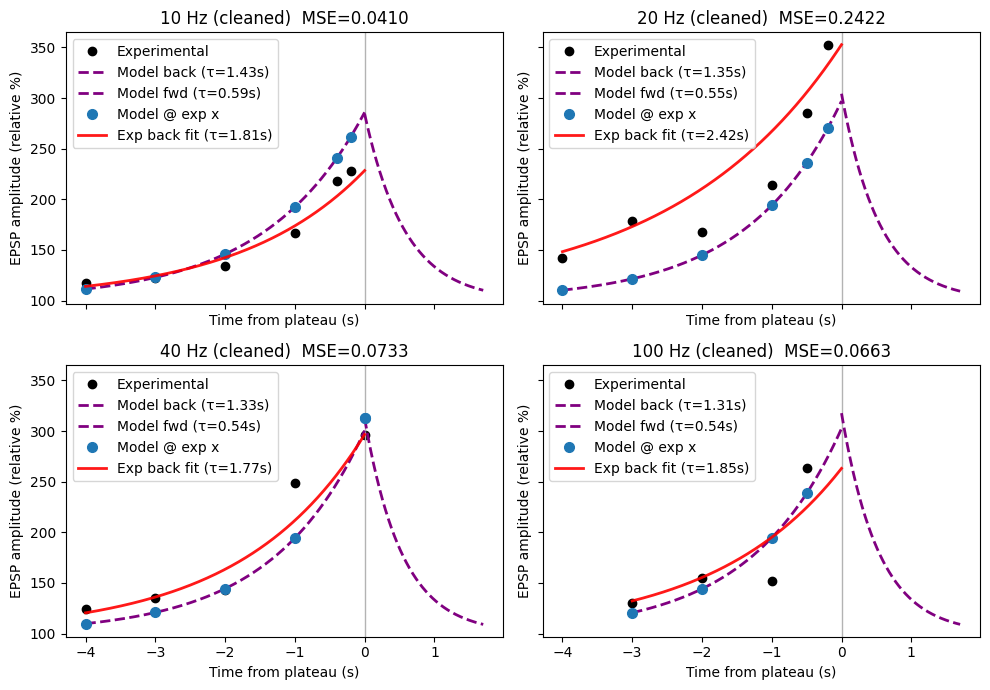

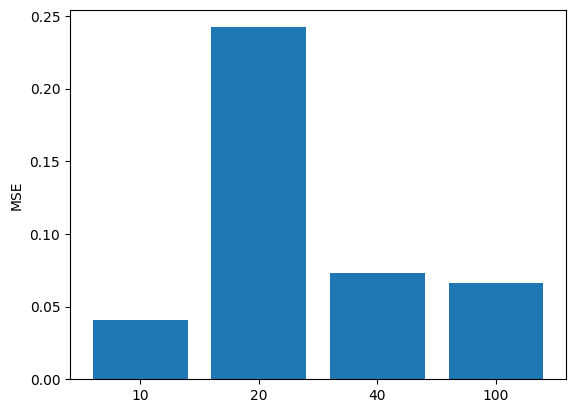

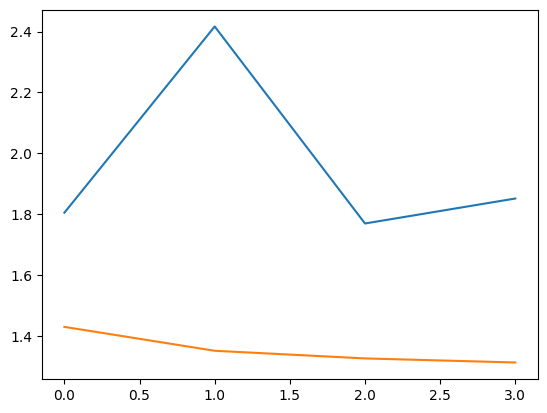

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_cleaned_data_2x2(backwards_model_per_hz_dict, cleaned_data_dict, hzs=(10, 20, 40, 100), x_units="s"):
    fig, axs = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
    axs = axs.ravel()

    def mse_vs_tau_curve_and_points(x_exp, y_exp, xx_b, yy_b, xx_f, yy_f):
        x_exp = np.asarray(x_exp, float)
        y_exp = np.asarray(y_exp, float)

        yhat = np.full_like(y_exp, np.nan, dtype=float)

        # back arm
        xb = np.asarray(xx_b, float); yb = np.asarray(yy_b, float)
        mb = np.isfinite(xb) & np.isfinite(yb)
        xb, yb = xb[mb], yb[mb]
        if xb.size >= 2:
            ob = np.argsort(xb); xb, yb = xb[ob], yb[ob]
            m_exp_b = (x_exp <= 0) & (x_exp >= xb.min()) & (x_exp <= xb.max())
            yhat[m_exp_b] = np.interp(x_exp[m_exp_b], xb, yb)

        # fwd arm
        xf = np.asarray(xx_f, float); yf = np.asarray(yy_f, float)
        mf = np.isfinite(xf) & np.isfinite(yf)
        xf, yf = xf[mf], yf[mf]
        if xf.size >= 2:
            of = np.argsort(xf); xf, yf = xf[of], yf[of]
            m_exp_f = (x_exp >= 0) & (x_exp >= xf.min()) & (x_exp <= xf.max())
            yhat[m_exp_f] = np.interp(x_exp[m_exp_f], xf, yf)

        m = np.isfinite(y_exp) & np.isfinite(yhat)
        mse = np.nan if m.sum() < 2 else float(np.mean((y_exp[m] - yhat[m]) ** 2))

        xb_pts = x_exp[m & (x_exp <= 0)]
        yb_pts = yhat[m & (x_exp <= 0)]
        xf_pts = x_exp[m & (x_exp >= 0)]
        yf_pts = yhat[m & (x_exp >= 0)]

        return mse, yhat, (xb_pts, yb_pts), (xf_pts, yf_pts)

    def fit_tau_arm_through_apex(x_arm, y_arm, y0):
        """
        Fit y(x) = y0 * exp(x/tau)  for x<=0  OR  y(x)= y0*exp(-x/tau) for x>=0,
        using only points on that arm. Returns tau (seconds). Robust, no scipy.
        """
        x_arm = np.asarray(x_arm, float)
        y_arm = np.asarray(y_arm, float)
        m = np.isfinite(x_arm) & np.isfinite(y_arm) & (y_arm > 0) & np.isfinite(y0) & (y0 > 0)
        x_arm, y_arm = x_arm[m], y_arm[m]
        if x_arm.size < 2:
            return np.nan

        # regress ln(y/y0) vs x
        z = np.log(y_arm / y0)

        # avoid singular fits
        if np.allclose(np.var(x_arm), 0.0):
            return np.nan

        slope, intercept = np.polyfit(x_arm, z, 1)

        # For back arm: slope ~ 1/tau (positive)
        # For fwd arm if we fit ln(y/y0) vs x, slope should be ~ -1/tau (negative)
        if slope == 0:
            return np.nan
        return float(1.0 / abs(slope))

    def apex_at_zero(x_plot, y):
        """Return y at x=0 (exact if present, else interpolated)."""
        x_plot = np.asarray(x_plot, float)
        y = np.asarray(y, float)
        m = np.isfinite(x_plot) & np.isfinite(y)
        x_plot, y = x_plot[m], y[m]
        o = np.argsort(x_plot); x_plot, y = x_plot[o], y[o]
        if x_plot.size < 2:
            return np.nan
        if np.any(x_plot == 0.0):
            return float(y[x_plot == 0.0][0])
        # interpolate at 0 within domain; if 0 outside, use nearest endpoint
        if 0.0 < x_plot.min() or 0.0 > x_plot.max():
            # nearest
            return float(y[np.argmin(np.abs(x_plot - 0.0))])
        return float(np.interp(0.0, x_plot, y))
    

    mse_list = []

    tau_exp_back_list = []

    tau_model_back_list = []

    for i, hz in enumerate(hzs):
        ax = axs[i]
        model_dict = backwards_model_per_hz_dict[hz]

        x = np.asarray(cleaned_data_dict[hz]["x"], float)
        y = np.asarray(cleaned_data_dict[hz]["y"], float)

        # ms -> seconds from plateau
        if x_units == "s":
            x_plot = -x / 1000.0
            ax.set_xlabel("Time from plateau (s)")
        else:
            x_plot = -x
            ax.set_xlabel("Time from plateau (ms)")

        o = np.argsort(x_plot)
        x_plot = x_plot[o]
        y = y[o]

        # span of experimental x (for trimming both model + exp tau lines)
        x_min = float(np.nanmin(x_plot))
        x_max = float(np.nanmax(x_plot))

        # ---------------------------------------------------------------------
        # Extend Jeff tau curves so they span ALL experimental x values
        # ---------------------------------------------------------------------
        if np.isfinite(x_min) and x_min < 0:
            model_dict["xx_b"] = np.linspace(x_min, 0.0, 800)
            model_dict["model_backwards_line"] = exp_with_fixed_c(
                model_dict["xx_b"], model_dict["Amb"], model_dict["taumb"], c_fixed=0.0
            )
        if np.isfinite(x_max) and x_max > 0:
            model_dict["xx_f"] = np.linspace(0.0, x_max, 800)
            model_dict["model_forwards_line"] = exp_with_fixed_c(
                -model_dict["xx_f"], model_dict["Amf"], model_dict["taumf"], c_fixed=0.0
            )
        # ---------------------------------------------------------------------

        tau_model_back_list.append(model_dict["taumb"])

        # --- Experimental points ---
        ax.plot(x_plot, y, "o", color="k", ms=6, label="Experimental")
        ax.axvline(0, color="0.7", lw=1)

        # --- Jeff tau-fit curves ---
        ax.plot(model_dict["xx_b"], model_dict["model_backwards_line"],
                "--", lw=2.0, color="purple", label=f"Model back (τ={model_dict['taumb']:.2f}s)")
        ax.plot(model_dict["xx_f"], model_dict["model_forwards_line"],
                "--", lw=2.0, color="purple", label=f"Model fwd (τ={model_dict['taumf']:.2f}s)")

        # --- MSE vs Jeff tau curves ---
        mse, yhat, (xb_pts, yb_pts), (xf_pts, yf_pts) = mse_vs_tau_curve_and_points(
            x_exp=x_plot, y_exp=y,
            xx_b=model_dict["xx_b"], yy_b=model_dict["model_backwards_line"],
            xx_f=model_dict["xx_f"], yy_f=model_dict["model_forwards_line"],
        )
        ax.plot(xb_pts, yb_pts, "o", ms=7, color="tab:blue", label="Model @ exp x")
        ax.plot(xf_pts, yf_pts, "o", ms=7, color="tab:blue")

        # ---------------------------------------------------------------------
        # NEW: Fit exponential τ to EXPERIMENTAL data (trimmed to exp x-range)
        # and plot ONLY over [x_min, 0] and [0, x_max]
        # ---------------------------------------------------------------------
        y0 = apex_at_zero(x_plot, y)

        # split experimental arms
        m_back = (x_plot <= 0) & np.isfinite(y)
        m_fwd  = (x_plot >= 0) & np.isfinite(y)

        x_back, y_back = x_plot[m_back], y[m_back]
        x_fwd,  y_fwd  = x_plot[m_fwd],  y[m_fwd]

        tau_exp_back = fit_tau_arm_through_apex(x_back, y_back, y0)
        tau_exp_fwd  = fit_tau_arm_through_apex(x_fwd,  y_fwd,  y0)

        # plot exp tau lines only over the experimental x extent
        if np.isfinite(tau_exp_back) and x_min < 0:
            xx = np.linspace(x_min, 0.0, 400)
            yy = y0 * np.exp(xx / tau_exp_back)
            ax.plot(xx, yy, "-", lw=2.0, color="red", alpha=0.9,
                    label=f"Exp back fit (τ={tau_exp_back:.2f}s)")

        if np.isfinite(tau_exp_fwd) and x_max > 0:
            xx = np.linspace(0.0, x_max, 400)
            yy = y0 * np.exp(-xx / tau_exp_fwd)
            ax.plot(xx, yy, "-", lw=2.0, color="red", alpha=0.9,
                    label=f"Exp fwd fit (τ={tau_exp_fwd:.2f}s)")
        # ---------------------------------------------------------------------

        tau_exp_back_list.append(tau_exp_back)

        ax.set_title(f"{hz} Hz (cleaned)  MSE={mse:.4f}")
        mse_list.append(mse)
        ax.set_ylabel("EPSP amplitude (relative %)")
        ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f"{100 + 100*v:.0f}"))
        # ax.set_ylim(bottom=100)
        ax.legend(loc="upper left")

        # also print taus to console for easy copy/paste
        print(f"[{hz} Hz] exp tau back={tau_exp_back:.3f}s, exp tau fwd={tau_exp_fwd:.3f}s")

    # axs[4].plot(mse_list)

    plt.tight_layout()
    plt.show()


    plt.figure()
    plt.bar(np.arange(len(mse_list)), mse_list)
    plt.xticks(range(4), ["10 Hz", "20 Hz", "40 Hz", "100 Hz"])
    plt.ylabel("MSE")
    plt.ylabel("MSE")
    plt.show()

    plt.plot(tau_exp_back_list, label='Experiment')
    plt.plot(tau_model_back_list, label='Experiment')
    plt.show()

plot_cleaned_data_2x2(backwards_model_per_hz_dict, cleaned_data_dict, hzs=(10, 20, 40, 100), x_units="s")

[10 Hz] exp tau back=1.805s, exp tau fwd=nans
[20 Hz] exp tau back=2.417s, exp tau fwd=nans
[40 Hz] exp tau back=1.770s, exp tau fwd=nans
[100 Hz] exp tau back=1.852s, exp tau fwd=nans
[20Hz_full_kernel] exp tau back=1.274s, exp tau fwd=1.013s


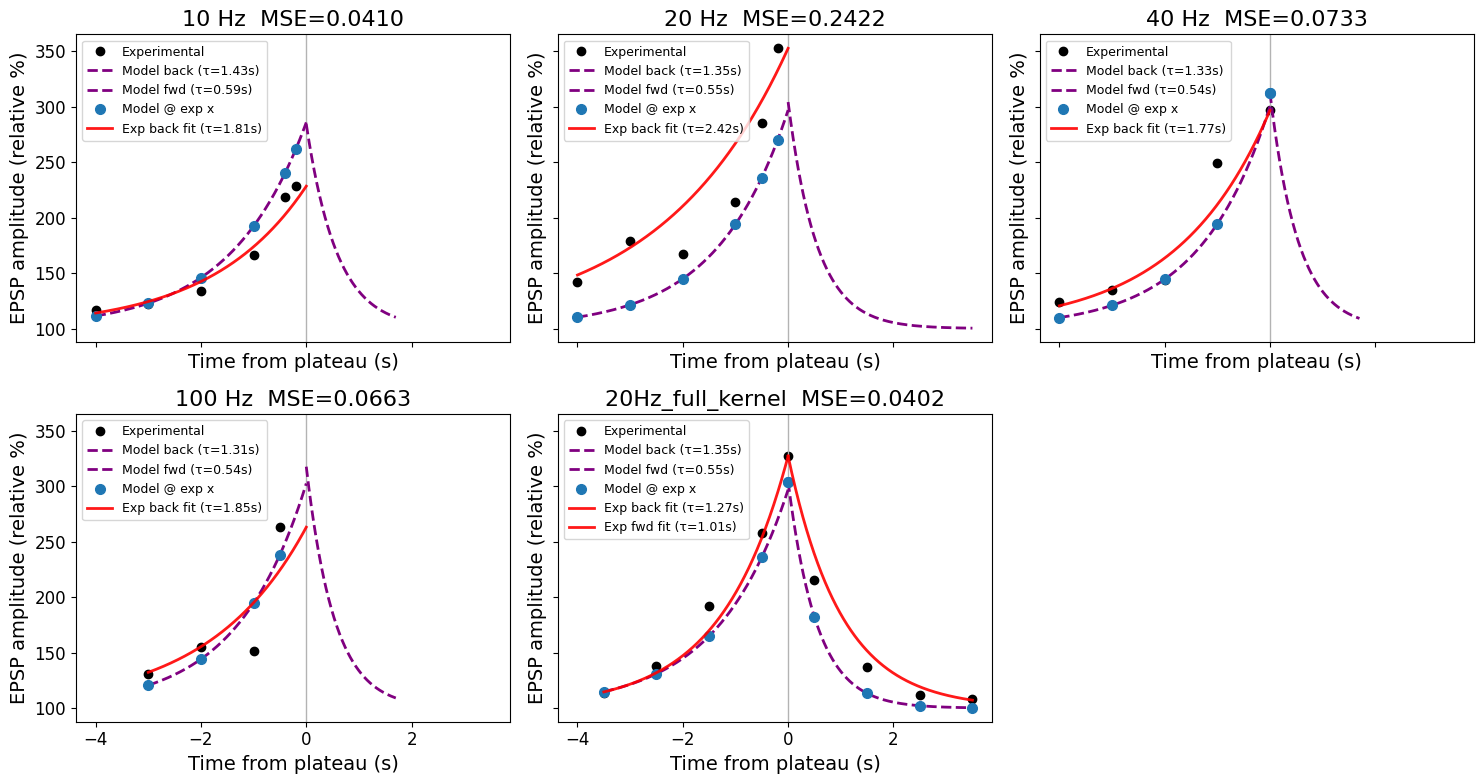

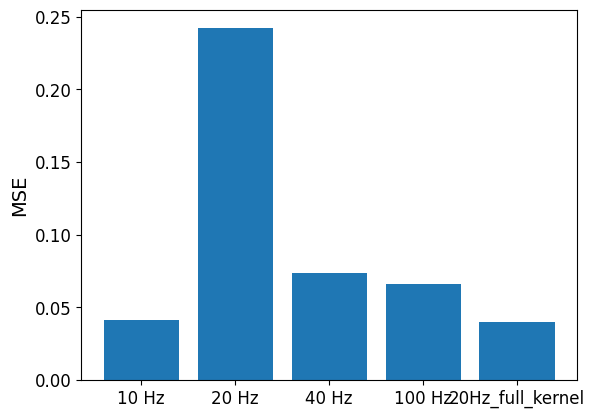

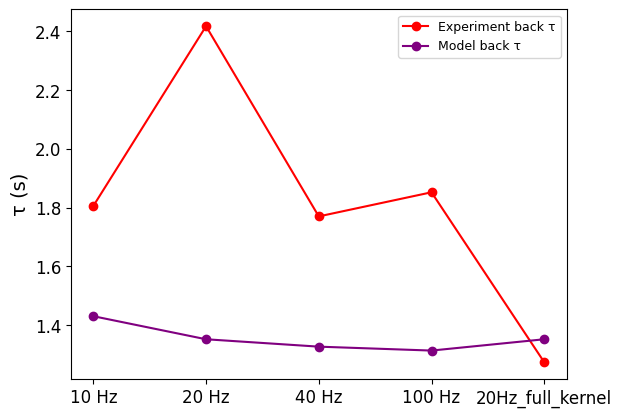

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.rcParams.update({
    # overall defaults
    "font.size": 12,

    # axes titles/labels
    "axes.titlesize": 16,
    "axes.labelsize": 14,

    # tick labels
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,

    # legend
    "legend.fontsize": 14,
    "legend.title_fontsize": 14,

    # figure suptitle (plt.suptitle)
    "figure.titlesize": 18,
})

plt.rcParams.update({
    "legend.fontsize": 9,        # <-- increase this
    "legend.title_fontsize": 9,  # <-- only matters if you set legend title
})


def plot_cleaned_data_2x2(backwards_model_per_hz_dict, cleaned_data_dict,
                         hzs=(10, 20, 40, 100), x_units="s"):

    # --- choose grid size based on how many panels you want ---
    n = len(hzs)
    if n <= 4:
        fig, axs = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
    elif n <= 6:
        fig, axs = plt.subplots(2, 3, figsize=(15,8), sharex=True, sharey=True)
    else:
        nrows = int(np.ceil(n / 3))
        fig, axs = plt.subplots(nrows, 3, figsize=(13, 3.5 * nrows), sharex=True, sharey=True)

    axs = np.array(axs).ravel()

    def mse_vs_tau_curve_and_points(x_exp, y_exp, xx_b, yy_b, xx_f, yy_f):
        x_exp = np.asarray(x_exp, float)
        y_exp = np.asarray(y_exp, float)

        yhat = np.full_like(y_exp, np.nan, dtype=float)

        # back arm
        xb = np.asarray(xx_b, float); yb = np.asarray(yy_b, float)
        mb = np.isfinite(xb) & np.isfinite(yb)
        xb, yb = xb[mb], yb[mb]
        if xb.size >= 2:
            ob = np.argsort(xb); xb, yb = xb[ob], yb[ob]
            m_exp_b = (x_exp <= 0) & (x_exp >= xb.min()) & (x_exp <= xb.max())
            yhat[m_exp_b] = np.interp(x_exp[m_exp_b], xb, yb)

        # fwd arm
        xf = np.asarray(xx_f, float); yf = np.asarray(yy_f, float)
        mf = np.isfinite(xf) & np.isfinite(yf)
        xf, yf = xf[mf], yf[mf]
        if xf.size >= 2:
            of = np.argsort(xf); xf, yf = xf[of], yf[of]
            m_exp_f = (x_exp >= 0) & (x_exp >= xf.min()) & (x_exp <= xf.max())
            yhat[m_exp_f] = np.interp(x_exp[m_exp_f], xf, yf)

        m = np.isfinite(y_exp) & np.isfinite(yhat)
        mse = np.nan if m.sum() < 2 else float(np.mean((y_exp[m] - yhat[m]) ** 2))

        xb_pts = x_exp[m & (x_exp <= 0)]
        yb_pts = yhat[m & (x_exp <= 0)]
        xf_pts = x_exp[m & (x_exp >= 0)]
        yf_pts = yhat[m & (x_exp >= 0)]

        return mse, yhat, (xb_pts, yb_pts), (xf_pts, yf_pts)

    def fit_tau_arm_through_apex(x_arm, y_arm, y0):
        x_arm = np.asarray(x_arm, float)
        y_arm = np.asarray(y_arm, float)
        m = np.isfinite(x_arm) & np.isfinite(y_arm) & (y_arm > 0) & np.isfinite(y0) & (y0 > 0)
        x_arm, y_arm = x_arm[m], y_arm[m]
        if x_arm.size < 2:
            return np.nan
        z = np.log(y_arm / y0)
        if np.allclose(np.var(x_arm), 0.0):
            return np.nan
        slope, _ = np.polyfit(x_arm, z, 1)
        if slope == 0:
            return np.nan
        return float(1.0 / abs(slope))

    def apex_at_zero(x_plot, y):
        x_plot = np.asarray(x_plot, float)
        y = np.asarray(y, float)
        m = np.isfinite(x_plot) & np.isfinite(y)
        x_plot, y = x_plot[m], y[m]
        o = np.argsort(x_plot); x_plot, y = x_plot[o], y[o]
        if x_plot.size < 2:
            return np.nan
        if np.any(x_plot == 0.0):
            return float(y[x_plot == 0.0][0])
        if 0.0 < x_plot.min() or 0.0 > x_plot.max():
            return float(y[np.argmin(np.abs(x_plot - 0.0))])
        return float(np.interp(0.0, x_plot, y))

    mse_list = []
    tau_exp_back_list = []
    tau_model_back_list = []

    # formatter: 0 -> 100, 2.5 -> 350 (labels only; data unchanged)
    percent_formatter = FuncFormatter(lambda v, _: f"{100 + 100*v:.0f}")

    for i, hz in enumerate(hzs):
        ax = axs[i]
        if hz == "20Hz_full_kernel":
            model_dict = backwards_model_per_hz_dict[20]
        else:
            model_dict = backwards_model_per_hz_dict[hz]

        x = np.asarray(cleaned_data_dict[hz]["x"], float)
        y = np.asarray(cleaned_data_dict[hz]["y"], float)

        # ms -> seconds from plateau
        if x_units == "s":
            x_plot = -x / 1000.0
            ax.set_xlabel("Time from plateau (s)")
        else:
            x_plot = -x
            ax.set_xlabel("Time from plateau (ms)")

        o = np.argsort(x_plot)
        x_plot = x_plot[o]
        y = y[o]

        x_min = float(np.nanmin(x_plot))
        x_max = float(np.nanmax(x_plot))

        # Extend Jeff tau curves so they span ALL experimental x values
        if np.isfinite(x_min) and x_min < 0:
            model_dict["xx_b"] = np.linspace(x_min, 0.0, 800)
            model_dict["model_backwards_line"] = exp_with_fixed_c(
                model_dict["xx_b"], model_dict["Amb"], model_dict["taumb"], c_fixed=0.0
            )
        if np.isfinite(x_max) and x_max > 0:
            model_dict["xx_f"] = np.linspace(0.0, x_max, 800)
            model_dict["model_forwards_line"] = exp_with_fixed_c(
                -model_dict["xx_f"], model_dict["Amf"], model_dict["taumf"], c_fixed=0.0
            )

        # store taus
        tau_model_back_list.append(model_dict["taumb"])

        # Experimental points (no connecting line)
        ax.plot(x_plot, y, "o", color="k", ms=6, label="Experimental")
        ax.axvline(0, color="0.7", lw=1)

        # Jeff tau-fit curves
        ax.plot(model_dict["xx_b"], model_dict["model_backwards_line"],
                "--", lw=2.0, color="purple", label=f"Model back (τ={model_dict['taumb']:.2f}s)")
        ax.plot(model_dict["xx_f"], model_dict["model_forwards_line"],
                "--", lw=2.0, color="purple", label=f"Model fwd (τ={model_dict['taumf']:.2f}s)")

        # MSE vs Jeff tau curves + points used for MSE
        mse, yhat, (xb_pts, yb_pts), (xf_pts, yf_pts) = mse_vs_tau_curve_and_points(
            x_exp=x_plot, y_exp=y,
            xx_b=model_dict["xx_b"], yy_b=model_dict["model_backwards_line"],
            xx_f=model_dict["xx_f"], yy_f=model_dict["model_forwards_line"],
        )
        ax.plot(xb_pts, yb_pts, "o", ms=7, color="tab:blue", label="Model @ exp x")
        ax.plot(xf_pts, yf_pts, "o", ms=7, color="tab:blue")

        # Fit exponential τ to EXPERIMENTAL data (back & fwd)
        y0 = apex_at_zero(x_plot, y)

        m_back = (x_plot <= 0) & np.isfinite(y)
        m_fwd  = (x_plot >= 0) & np.isfinite(y)

        x_back, y_back = x_plot[m_back], y[m_back]
        x_fwd,  y_fwd  = x_plot[m_fwd],  y[m_fwd]

        tau_exp_back = fit_tau_arm_through_apex(x_back, y_back, y0)
        tau_exp_fwd  = fit_tau_arm_through_apex(x_fwd,  y_fwd,  y0)

        if np.isfinite(tau_exp_back) and x_min < 0:
            xx = np.linspace(x_min, 0.0, 400)
            yy = y0 * np.exp(xx / tau_exp_back)
            ax.plot(xx, yy, "-", lw=2.0, color="red", alpha=0.9,
                    label=f"Exp back fit (τ={tau_exp_back:.2f}s)")
        if np.isfinite(tau_exp_fwd) and x_max > 0:
            xx = np.linspace(0.0, x_max, 400)
            yy = y0 * np.exp(-xx / tau_exp_fwd)
            ax.plot(xx, yy, "-", lw=2.0, color="red", alpha=0.9,
                    label=f"Exp fwd fit (τ={tau_exp_fwd:.2f}s)")

        tau_exp_back_list.append(tau_exp_back)

        # labels + y tick relabeling (no rescaling)
        name = f"{hz} Hz" if isinstance(hz, (int, float)) else str(hz)
        ax.set_title(f"{name}  MSE={mse:.4f}")
        mse_list.append(mse)

        ax.set_ylabel("EPSP amplitude (relative %)")
        ax.yaxis.set_major_formatter(percent_formatter)

        ax.legend(loc="upper left")

        print(f"[{name}] exp tau back={tau_exp_back:.3f}s, exp tau fwd={tau_exp_fwd:.3f}s")

    # hide any unused panels
    for j in range(len(hzs), len(axs)):
        axs[j].axis("off")

    plt.tight_layout()
    plt.show()

    # --- MSE bar plot (matches number of hzs) ---
    plt.figure()
    plt.bar(np.arange(len(mse_list)), mse_list)
    plt.xticks(range(len(hzs)), [f"{h} Hz" if isinstance(h, (int, float)) else str(h) for h in hzs])
    plt.ylabel("MSE")
    plt.show()

    # --- Tau plot: make sure labels are correct (you had both labeled 'Experiment') ---
    plt.figure()
    plt.plot(tau_exp_back_list, "-o", label="Experiment back τ", color='r')
    plt.plot(tau_model_back_list, "-o", label="Model back τ", color='purple')
    plt.xticks(range(len(hzs)), [f"{h} Hz" if isinstance(h, (int, float)) else str(h) for h in hzs])
    plt.ylabel("τ (s)")
    plt.legend()
    plt.show()


# Example:
plot_cleaned_data_2x2(backwards_model_per_hz_dict, cleaned_data_dict,
                      hzs=(10, 20, 40, 100, "20Hz_full_kernel"), x_units="s")

[10 Hz] y0(data)=1.2839, y0(model)=1.8588 | exp tau back=1.805s, exp tau fwd=nans
[20 Hz] y0(data)=2.5270, y0(model)=1.9701 | exp tau back=2.417s, exp tau fwd=nans
[40 Hz] y0(data)=1.9663, y0(model)=2.0050 | exp tau back=1.770s, exp tau fwd=nans
[100 Hz] y0(data)=1.6316, y0(model)=2.0257 | exp tau back=1.852s, exp tau fwd=nans
[20Hz_full
kernel] y0(data)=2.2731, y0(model)=1.9701 | exp tau back=1.274s, exp tau fwd=1.013s


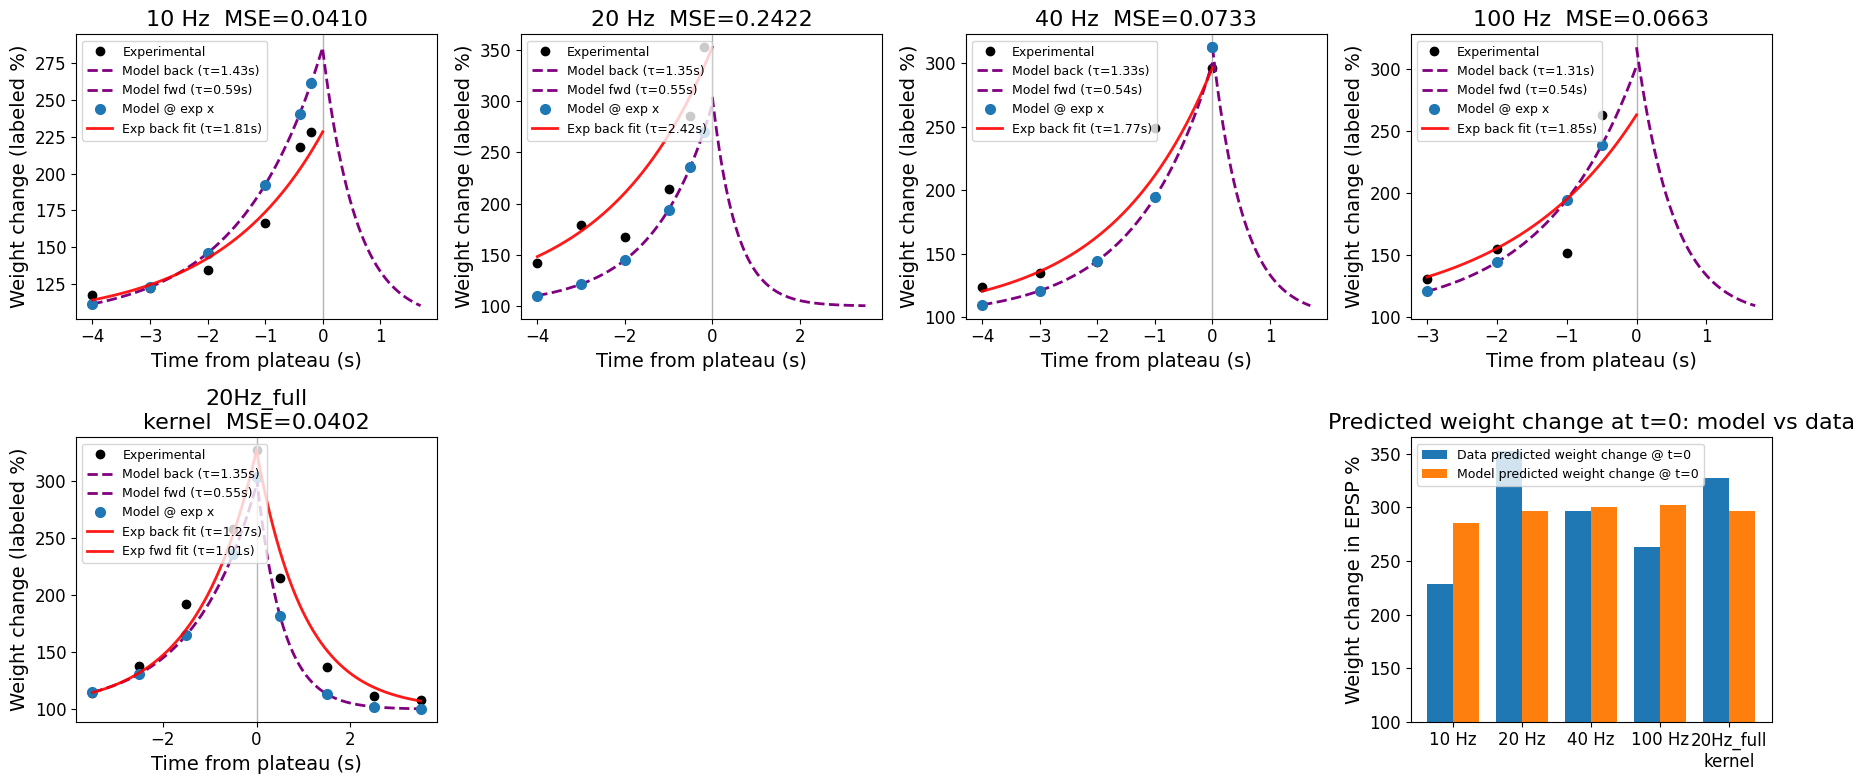

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def plot_cleaned_data_2x4_with_y0(backwards_model_per_hz_dict, cleaned_data_dict,
                                  hzs=(10, 20, 40, 100, "20Hz_full_kernel"),
                                  x_units="s"):

    # ---------------- helpers ----------------
    def mse_vs_tau_curve_and_points(x_exp, y_exp, xx_b, yy_b, xx_f, yy_f):
        x_exp = np.asarray(x_exp, float)
        y_exp = np.asarray(y_exp, float)
        yhat = np.full_like(y_exp, np.nan, dtype=float)

        # back arm
        xb = np.asarray(xx_b, float); yb = np.asarray(yy_b, float)
        mb = np.isfinite(xb) & np.isfinite(yb)
        xb, yb = xb[mb], yb[mb]
        if xb.size >= 2:
            ob = np.argsort(xb); xb, yb = xb[ob], yb[ob]
            m_exp_b = (x_exp <= 0) & (x_exp >= xb.min()) & (x_exp <= xb.max())
            yhat[m_exp_b] = np.interp(x_exp[m_exp_b], xb, yb)

        # fwd arm
        xf = np.asarray(xx_f, float); yf = np.asarray(yy_f, float)
        mf = np.isfinite(xf) & np.isfinite(yf)
        xf, yf = xf[mf], yf[mf]
        if xf.size >= 2:
            of = np.argsort(xf); xf, yf = xf[of], yf[of]
            m_exp_f = (x_exp >= 0) & (x_exp >= xf.min()) & (x_exp <= xf.max())
            yhat[m_exp_f] = np.interp(x_exp[m_exp_f], xf, yf)

        m = np.isfinite(y_exp) & np.isfinite(yhat)
        mse = np.nan if m.sum() < 2 else float(np.mean((y_exp[m] - yhat[m]) ** 2))
        xb_pts = x_exp[m & (x_exp <= 0)]
        yb_pts = yhat[m & (x_exp <= 0)]
        xf_pts = x_exp[m & (x_exp >= 0)]
        yf_pts = yhat[m & (x_exp >= 0)]
        return mse, yhat, (xb_pts, yb_pts), (xf_pts, yf_pts)

    def fit_tau_arm_through_apex(x_arm, y_arm, y0):
        x_arm = np.asarray(x_arm, float)
        y_arm = np.asarray(y_arm, float)
        m = np.isfinite(x_arm) & np.isfinite(y_arm) & (y_arm > 0) & np.isfinite(y0) & (y0 > 0)
        x_arm, y_arm = x_arm[m], y_arm[m]
        if x_arm.size < 2:
            return np.nan
        z = np.log(y_arm / y0)
        if np.allclose(np.var(x_arm), 0.0):
            return np.nan
        slope, _ = np.polyfit(x_arm, z, 1)
        if slope == 0:
            return np.nan
        return float(1.0 / abs(slope))

    def apex_at_zero(x_plot, y):
        x_plot = np.asarray(x_plot, float)
        y = np.asarray(y, float)
        m = np.isfinite(x_plot) & np.isfinite(y)
        x_plot, y = x_plot[m], y[m]
        o = np.argsort(x_plot); x_plot, y = x_plot[o], y[o]
        if x_plot.size < 1:
            return np.nan
        if np.any(x_plot == 0.0):
            return float(y[x_plot == 0.0][0])
        # if 0 in-domain, interpolate; else nearest
        if (x_plot.min() <= 0.0) and (0.0 <= x_plot.max()) and (x_plot.size >= 2):
            return float(np.interp(0.0, x_plot, y))
        return float(y[np.argmin(np.abs(x_plot - 0.0))])

    def y_on_curve_at_zero(xx_b, yy_b, xx_f, yy_f):
        # prefer explicit 0 if present; else interpolate on whichever arm has 0 in domain.
        xx_b = np.asarray(xx_b, float); yy_b = np.asarray(yy_b, float)
        xx_f = np.asarray(xx_f, float); yy_f = np.asarray(yy_f, float)

        mb = np.isfinite(xx_b) & np.isfinite(yy_b)
        mf = np.isfinite(xx_f) & np.isfinite(yy_f)
        xx_b, yy_b = xx_b[mb], yy_b[mb]
        xx_f, yy_f = xx_f[mf], yy_f[mf]

        if xx_b.size >= 2:
            o = np.argsort(xx_b); xx_b, yy_b = xx_b[o], yy_b[o]
            if xx_b.min() <= 0.0 <= xx_b.max():
                return float(np.interp(0.0, xx_b, yy_b))
        if xx_f.size >= 2:
            o = np.argsort(xx_f); xx_f, yy_f = xx_f[o], yy_f[o]
            if xx_f.min() <= 0.0 <= xx_f.max():
                return float(np.interp(0.0, xx_f, yy_f))
        # fallback: nearest point among both arrays
        if xx_b.size == 0 and xx_f.size == 0:
            return np.nan
        cand = []
        if xx_b.size:
            cand.append((abs(xx_b[np.argmin(abs(xx_b))]), float(yy_b[np.argmin(abs(xx_b))])))
        if xx_f.size:
            cand.append((abs(xx_f[np.argmin(abs(xx_f))]), float(yy_f[np.argmin(abs(xx_f))])))
        cand.sort(key=lambda t: t[0])
        return cand[0][1]

    # tick relabeling: 0 -> 100, 2.5 -> 350 (labels only; data unchanged)
    percent_formatter = FuncFormatter(lambda v, _: f"{100 + 100*v:.0f}")

    # ---------------- figure layout: 2x4 ----------------
    # first row: up to 4 condition plots
    # second row: remaining plots + 1 summary panel (y@0 comparison)
    fig, axs = plt.subplots(2, 4, figsize=(18, 8), sharex=False, sharey=False)
    axs = axs.ravel()

    # we will fill first 7 axes with condition plots (if you have 5 conditions, that's fine)
    # and the last axis (index 7) is the y@0 summary
    max_condition_axes = 7
    y0_summary_ax = axs[7]

    # storage for summary plot
    labels = []
    y0_data = []
    y0_model = []

    # optional: also store taus if you want later
    tau_exp_back_list = []
    tau_model_back_list = []

    for i, hz in enumerate(hzs):
        if i >= max_condition_axes:
            break  # keep last axis for summary

        ax = axs[i]

        # pull model dict (special case for full-kernel)
        if hz == "20Hz_full_kernel":
            model_dict = backwards_model_per_hz_dict[20]
        else:
            model_dict = backwards_model_per_hz_dict[hz]

        x = np.asarray(cleaned_data_dict[hz]["x"], float)
        y = np.asarray(cleaned_data_dict[hz]["y"], float)

        # ms -> seconds from plateau
        if x_units == "s":
            x_plot = -x / 1000.0
            ax.set_xlabel("Time from plateau (s)")
        else:
            x_plot = -x
            ax.set_xlabel("Time from plateau (ms)")

        o = np.argsort(x_plot)
        x_plot = x_plot[o]
        y = y[o]

        x_min = float(np.nanmin(x_plot))
        x_max = float(np.nanmax(x_plot))

        # Extend Jeff tau curves to span experimental x-range
        if np.isfinite(x_min) and x_min < 0:
            model_dict["xx_b"] = np.linspace(x_min, 0.0, 800)
            model_dict["model_backwards_line"] = exp_with_fixed_c(
                model_dict["xx_b"], model_dict["Amb"], model_dict["taumb"], c_fixed=0.0
            )
        if np.isfinite(x_max) and x_max > 0:
            model_dict["xx_f"] = np.linspace(0.0, x_max, 800)
            model_dict["model_forwards_line"] = exp_with_fixed_c(
                -model_dict["xx_f"], model_dict["Amf"], model_dict["taumf"], c_fixed=0.0
            )

        # ---- plot data + model ----
        ax.plot(x_plot, y, "o", color="k", ms=6, label="Experimental")
        ax.axvline(0, color="0.7", lw=1)

        ax.plot(model_dict["xx_b"], model_dict["model_backwards_line"],
                "--", lw=2.0, color="purple", label=f"Model back (τ={model_dict['taumb']:.2f}s)")
        ax.plot(model_dict["xx_f"], model_dict["model_forwards_line"],
                "--", lw=2.0, color="purple", label=f"Model fwd (τ={model_dict['taumf']:.2f}s)")

        mse, yhat, (xb_pts, yb_pts), (xf_pts, yf_pts) = mse_vs_tau_curve_and_points(
            x_exp=x_plot, y_exp=y,
            xx_b=model_dict["xx_b"], yy_b=model_dict["model_backwards_line"],
            xx_f=model_dict["xx_f"], yy_f=model_dict["model_forwards_line"],
        )
        ax.plot(xb_pts, yb_pts, "o", ms=7, color="tab:blue", label="Model @ exp x")
        ax.plot(xf_pts, yf_pts, "o", ms=7, color="tab:blue")

        # ---- experimental tau fits ----
        y0_exp = apex_at_zero(x_plot, y)

        m_back = (x_plot <= 0) & np.isfinite(y)
        m_fwd  = (x_plot >= 0) & np.isfinite(y)
        x_back, y_back = x_plot[m_back], y[m_back]
        x_fwd,  y_fwd  = x_plot[m_fwd],  y[m_fwd]

        tau_exp_back = fit_tau_arm_through_apex(x_back, y_back, y0_exp)
        tau_exp_fwd  = fit_tau_arm_through_apex(x_fwd,  y_fwd,  y0_exp)

        if np.isfinite(tau_exp_back) and x_min < 0:
            xx = np.linspace(x_min, 0.0, 400)
            yy = y0_exp * np.exp(xx / tau_exp_back)
            ax.plot(xx, yy, "-", lw=2.0, color="red", alpha=0.9,
                    label=f"Exp back fit (τ={tau_exp_back:.2f}s)")
        if np.isfinite(tau_exp_fwd) and x_max > 0:
            xx = np.linspace(0.0, x_max, 400)
            yy = y0_exp * np.exp(-xx / tau_exp_fwd)
            ax.plot(xx, yy, "-", lw=2.0, color="red", alpha=0.9,
                    label=f"Exp fwd fit (τ={tau_exp_fwd:.2f}s)")

        # ---- y(t=0) comparison: choose from the tau lines ----
        # model y0 from Jeff tau curves:
        y0_mod = y_on_curve_at_zero(model_dict["xx_b"], model_dict["model_backwards_line"],
                                    model_dict["xx_f"], model_dict["model_forwards_line"])

        # data y0 from EXP tau lines (apex):
        # (this is the y0 anchoring the exp tau fits)
        y0_dat = float(y0_exp)

        labels.append("20Hz_full\nkernel" if hz == "20Hz_full_kernel" else f"{hz} Hz")
        y0_data.append(y0_dat)
        y0_model.append(y0_mod)

        tau_exp_back_list.append(tau_exp_back)
        tau_model_back_list.append(model_dict["taumb"])

        # cosmetics
        ax.set_title(f"{labels[-1]}  MSE={mse:.4f}")
        ax.set_ylabel("Weight change (labeled %)")
        ax.yaxis.set_major_formatter(percent_formatter)
        ax.legend(loc="upper left")

        print(f"[{labels[-1]}] y0(data)={y0_dat:.4f}, y0(model)={y0_mod:.4f} | "
              f"exp tau back={tau_exp_back:.3f}s, exp tau fwd={tau_exp_fwd:.3f}s")

    # # hide any unused condition panels (except summary)
    # for j in range(len(hzs), max_condition_axes):
    #     if j < 7:
    #         axs[j].axis("off")

    # --- MSE bar plot (matches number of hzs) ---
    plt.figure()
    plt.bar(np.arange(len(mse_list)), mse_list)
    plt.xticks(range(len(hzs)), [f"{h} Hz" if isinstance(h, (int, float)) else str(h) for h in hzs])
    plt.ylabel("MSE")
    plt.show()

    # --- Tau plot: make sure labels are correct (you had both labeled 'Experiment') ---
    plt.figure()
    plt.plot(tau_exp_back_list, "-o", label="Experiment back τ")
    plt.plot(tau_model_back_list, "-o", label="Model back τ")
    plt.xticks(range(len(hzs)), [f"{h} Hz" if isinstance(h, (int, float)) else str(h) for h in hzs])
    plt.ylabel("τ (s)")
    plt.legend()
    plt.show()

    # ---------------- summary panel: y(t=0) comparison ----------------
    xidx = np.arange(len(labels))
    width = 0.38

    y0_summary_ax.bar(xidx - width/2, y0_data, width, label="Data predicted weight change @ t=0")
    y0_summary_ax.bar(xidx + width/2, y0_model, width, label="Model predicted weight change @ t=0")

    y0_summary_ax.set_xticks(xidx)
    y0_summary_ax.set_xticklabels(labels, rotation=0)
    y0_summary_ax.set_title("Predicted weight change at t=0: model vs data")
    y0_summary_ax.set_ylabel("Weight change in EPSP %")
    y0_summary_ax.yaxis.set_major_formatter(percent_formatter)
    y0_summary_ax.legend(loc="upper left")

    plt.tight_layout()
    plt.show()


# CALL (2x4 figure, includes y@0 comparison panel)
plot_cleaned_data_2x4_with_y0(
    backwards_model_per_hz_dict, cleaned_data_dict,
    hzs=(10, 20, 40, 100, "20Hz_full_kernel"),
    x_units="s"
)

k 10
k 20
k 40
k 100


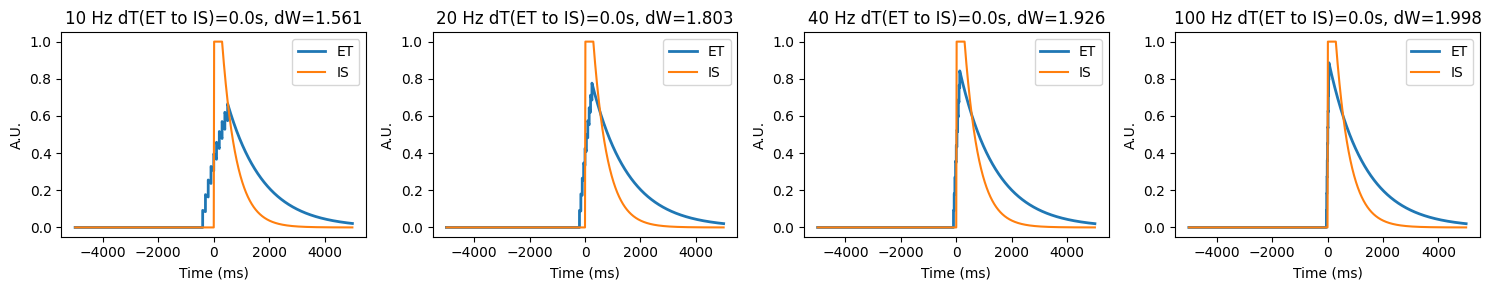

In [ ]:

hz_used=20
hz=20
plot=True
special_case=False

x_arr_int = jeffs_data_dict[hz]['x']

def plot_et_is(x_arr_int, params):
    et_time_1000_dict = {}

    hz_list = [10, 20, 40, 100]

    for hz_used in hz_list:

        delta_w_list, et_time_1000, IS = get_W(x_arr_int, post_ms=10000, pre_ms=10000, hz_used=hz_used, plateau_length=300,tau_et =params["tau_et"],tau_is = params["tau_is"],lam_et=params["lam_et"],lam_is=params["lam_is"],dt_ms=1.0, eta_ms = params["eta_ms"], plot_intermediates=False, special_case=True)

        et_time_1000_dict[hz_used] = et_time_1000

    # order = [10, 20, 40, 100, "20Hz_full_kernel"]

    fig, axs = plt.subplots(1, 4, figsize=(15,3))

    # pick keys that actually exist, in the desired order, cap at 5
    # keys = [k for k in order if k in et_time_1000_dict][:5]
    keys = hz_list

    pre_ms = 10000
    post_ms = 10000

    T_ms = int(pre_ms + post_ms)
    t_ms = np.arange(-pre_ms, post_ms, dtype=int)

    dw_per_hz_special_0 = []

    for i, k in enumerate(keys):
        if k!="20Hz_full_kernel":
            y = np.asarray(et_time_1000_dict[k], float)   # y-only series is fine
            W = np.trapz(y*IS, dx=1.0)
            dW = params["eta_ms"] * W
            dW_scaled = (dW+1) *100
            dw_per_hz_special_0.append(dW_scaled)
            # ax = axs[i]
            axs[i].plot(t_ms[5000:15000], y[5000:15000], lw=2, label="ET")
            axs[i].plot(t_ms[5000:15000], IS[5000:15000], label="IS")
            axs[i].set_title(f"{k} Hz dT(ET to IS)=0.0s, dW={dW:.3f}")
            axs[i].set_xlabel("Time (ms)")
            axs[i].set_ylabel("A.U.")
            axs[i].legend()

    # # hide the 6th (unused) panel to match the 5-panel layout
    # axs[5].axis('off')

    plt.tight_layout()
    plt.show()

x_arr_int = jeffs_data_dict[hz]['x']
plot_et_is(x_arr_int, params)

In [20]:
save_path = "/Users/michaelfinch/CA1-interneuron-GLM/ching_lung/pickle_of_all_experimental_data.pkl"
with open(save_path, 'rb') as f:
    cleaned_data_dict = pickle.load(f)

print(cleaned_data_dict.keys())

save_path = "/Users/michaelfinch/CA1-interneuron-GLM/ching_lung/jeffs_data_csv.pkl"
with open(save_path, 'rb') as f:
    jeffs_data_dict = pickle.load(f)

print(jeffs_data_dict.keys())

dict_keys([10, 20, 40, 100, '20Hz_full_kernel'])
dict_keys([20])
